# **Fashion MNIST: Automated Apparel Classification with Transfer Learning (CNN, Part 2)**

# **Part 1 - Business Problem**

An online fashion retailer receives thousands of new product images every week from
suppliers and marketplace sellers. Today, each image is categorized by hand
(T-shirt, Trouser, Dress, Sneaker, Bag, etc.), which is slow, inconsistent, and
expensive. Miscategorized products lower search relevance, hurt recommendations,
and reduce conversion rates.

## **Objective**

Build and compare image classification models based on Transfer Learning
(pre-trained CNN architectures) to automatically classify apparel images into the
10 Fashion MNIST categories, and decide whether they outperform the custom CNN
trained from scratch in Part 1.

## **Success Criteria**

- Accuracy and macro F1-score on the 10,000-image test set higher than the
  baseline CNN from Part 1.
- Identification of the most confused classes (for example Shirt vs T-shirt/top
  vs Pullover) to guide a human review process.
- Trade-off analysis between model performance, training time, and model size
  for production deployment.

## **Approach**

1. Reuse the same train/validation/test split from Part 1 for a fair comparison.
2. Adapt the 28x28 grayscale images to the input format required by the
   pre-trained models (3 channels and a larger resolution).
3. Train pre-trained models with frozen layers (feature extraction), then
   fine-tune the top layers.
4. Compare the models by accuracy, F1-score, confusion matrix, and training time.

# Part 2 - API Kaggle

In [1]:
# install dependency / instalar dependência
#%pip install -q kagglehub

In [12]:
import os
import sys
import time
import kagglehub

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report

from google.colab import userdata

In [4]:
# load credentials from Colab secrets / carregar credenciais dos secrets do Colab
#os.environ["kaggle_api"] = userdata.get("kaggle_api")

# download the dataset / baixar o dataset
#dataset_path = kagglehub.dataset_download("zalando-research/fashionmnist")

In [6]:
# list downloaded files / listar arquivos baixados
#print("Path:", dataset_path)
#print(os.listdir(dataset_path))

# Part 3 - GPU

In [7]:
# check GPU / verificar GPU
print("GPUs:", tf.config.list_physical_devices("GPU"))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [8]:
# GPU summary: model, driver, CUDA and memory / resumo da GPU: modelo, driver, CUDA e memória
!nvidia-smi

Sat Oct  3 20:55:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# compact query with driver version / consulta compacta com versão do driver
!nvidia-smi --query-gpu=name,driver_version,memory.total,compute_cap --format=csv

name, driver_version, memory.total [MiB], compute_cap
Tesla T4, 580.178.04, 15360 MiB, 7.5
Tesla T4, 580.178.04, 15360 MiB, 7.5


In [10]:
# CUDA compiler version / versão do compilador CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [13]:
# versions / versões
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)

Python: 3.13.15
TensorFlow: 2.20.0


In [14]:
# available GPUs / GPUs disponíveis
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [15]:
# GPU details / detalhes da GPU
for gpu in gpus:
    print(tf.config.experimental.get_device_details(gpu))

# minimal kernel launch test / teste mínimo de execução de kernel
x = tf.constant([1, 2, 3])
print(tf.cast(x, tf.float32))

{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}
tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)


I0000 00:00:1791060980.822775      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791060980.826849      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Part 4 - Database

In [18]:
# csv file paths / caminhos dos arquivos csv
#df_train = os.path.join(dataset_path, "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv")
#df_train = os.path.join(dataset_path, "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv")

# load datasets / carregar os datasets
df_train = pd.read_csv("fashionmnist/fashion-mnist_train.csv")
df_test = pd.read_csv("fashionmnist/fashion-mnist_test.csv")

df_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_train.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [22]:
df_train.dtypes

label       int64
pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 785, dtype: object

In [23]:
# class names / nomes das classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# dataset shapes / formatos dos datasets
print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (60000, 785)
Test: (10000, 785)


# **Part 5 - EAD**

In [24]:
# first rows / primeiras linhas
display(df_train.head())

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
# missing values / valores ausentes
print("Missing values (train):", df_train.isnull().sum().sum())
print("Missing values (test):", df_test.isnull().sum().sum())

Missing values (train): 0
Missing values (test): 0


In [26]:
# pixel value range / intervalo dos valores de pixel
pixels = df_train.drop(columns="label")
print("Pixel min:", pixels.min().min(), "| Pixel max:", pixels.max().max())

Pixel min: 0 | Pixel max: 255


In [27]:
# class distribution / distribuição das classes
class_counts = (
    df_train["label"]
    .map(dict(enumerate(class_names)))
    .value_counts()
    .sort_index()
)
display(class_counts.to_frame("count"))

,count
label,
Ankle boot,6000
Bag,6000
Coat,6000
Dress,6000
Pullover,6000
Sandal,6000
Shirt,6000
Sneaker,6000
T-shirt/top,6000


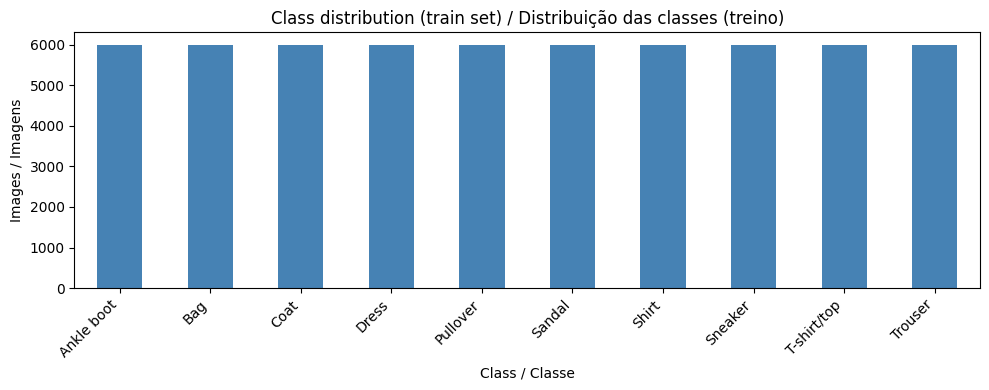

In [28]:
# class distribution plot / gráfico da distribuição das classes
class_counts.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Class distribution (train set) / Distribuição das classes (treino)")
plt.xlabel("Class / Classe")
plt.ylabel("Images / Imagens")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Class distribution

The training set is perfectly balanced: each of the 10 classes has 6,000 images
(60,000 in total). Because of this, no resampling or class weighting is needed,
and accuracy is a reliable metric alongside macro F1-score. Any performance
difference between models will come from the architecture and not from class
imbalance. The 4 classes with similar shapes (Shirt, T-shirt/top, Pullover and
Coat) are still expected to concentrate most of the errors.

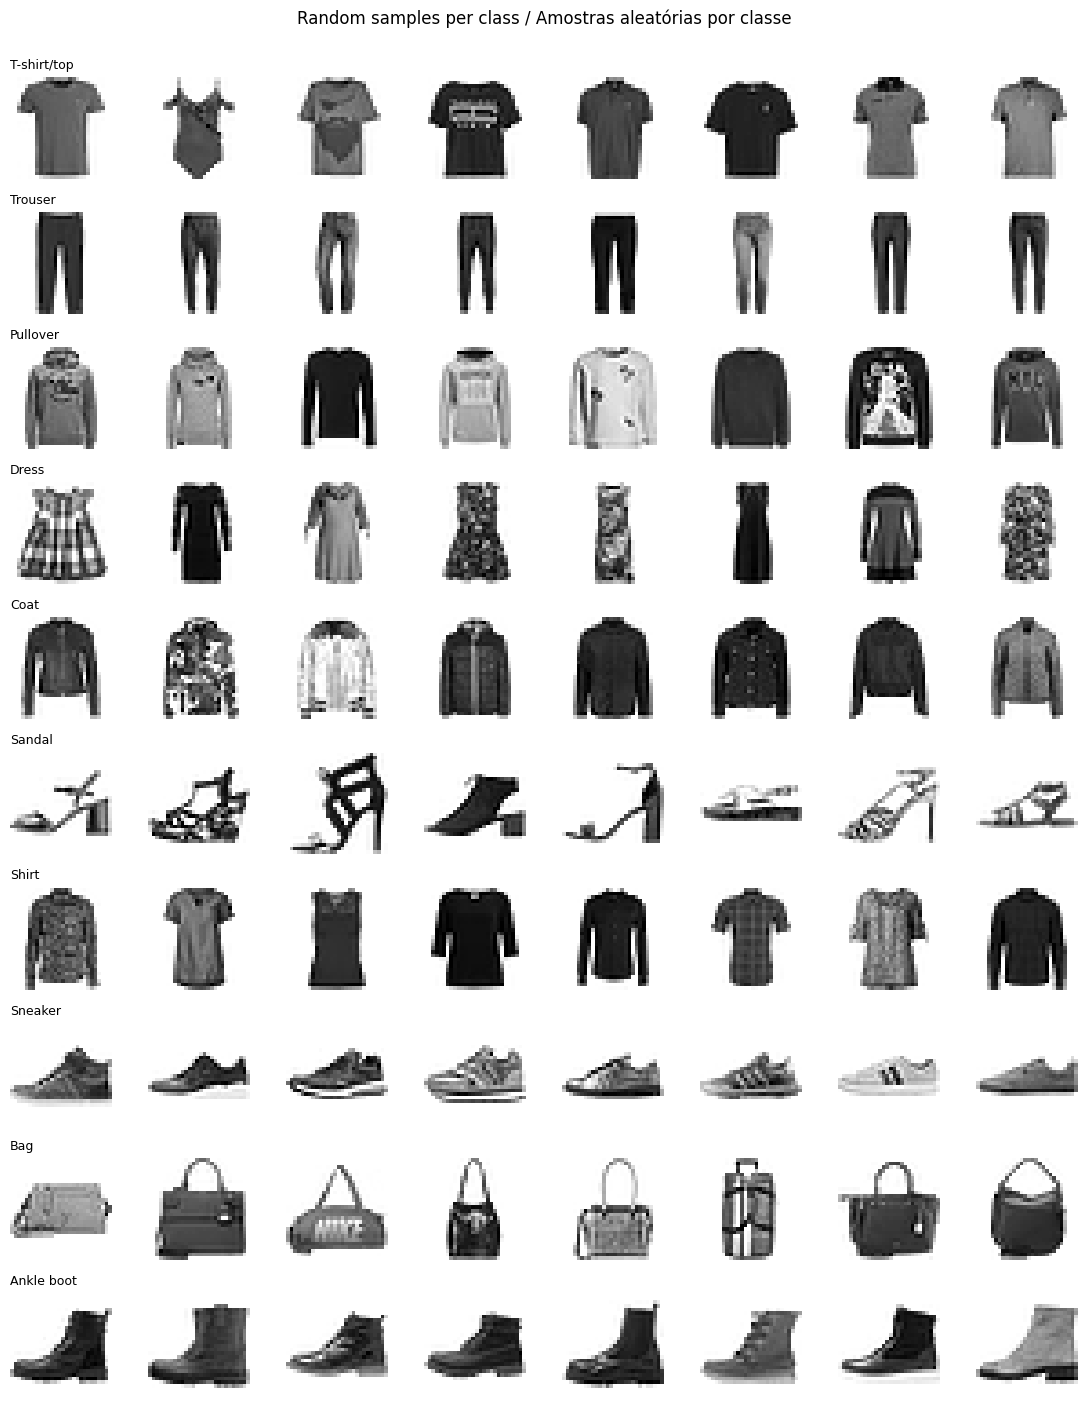

In [29]:
"""Visual inspection of Fashion MNIST images.

Shows a grid with random samples of each class and the average image per class.
"""

# reshape pixels to images / remodelar pixels para imagens
images = df_train.drop(columns="label").values.reshape(-1, 28, 28)
labels = df_train["label"].values

# random generator / gerador aleatório
rng = np.random.default_rng(42)

# grid with 8 random samples per class / grade com 8 amostras aleatórias por classe
n_samples = 8
fig, axes = plt.subplots(10, n_samples, figsize=(n_samples * 1.4, 10 * 1.4))

for class_id in range(10):
    class_idx = rng.choice(np.where(labels == class_id)[0], n_samples, replace=False)
    for col, idx in enumerate(class_idx):
        ax = axes[class_id, col]
        ax.imshow(images[idx], cmap="gray_r")
        ax.axis("off")
        if col == 0:
            ax.set_title(class_names[class_id], fontsize=9, loc="left")

plt.suptitle("Random samples per class / Amostras aleatórias por classe", y=1.0)
plt.tight_layout()
plt.show()

### Visual Inspection of the Dataset

The grid shows eight random training images per class. All images are
centered, shot from a front or side view on a plain background, and rendered
in 28x28 grayscale, so color is lost and shape and texture carry most of the
signal.

**Easy classes (consistent shapes)**
- **Trouser:** a two-legged vertical silhouette in every sample, with very
  little variation besides the wash (dark vs light denim).
- **Sneaker and Ankle boot:** always a side view with a stable low (sneaker) or
  high-shaft (boot) profile. They are well separated from each other.
- **Bag:** high visual variety (handbags, a duffel, a backpack-like piece), but
  the shapes are unlike any other class, so confusion with other classes is
  unlikely.

**Hard classes (overlapping shapes)**
- **T-shirt/top, Shirt, Pullover and Coat:** all are upper-body garments with a
  similar torso and sleeve silhouette. Their differences are subtle details
  (collar, buttons, sleeve length, hood, zipper) that are partly lost at 28x28
  resolution.
- **Shirt:** the most heterogeneous class. In this sample it includes a plaid
  short-sleeve shirt, a sleeveless top, a three-quarter-sleeve blouse and a
  dark long-sleeve top. Several of these could easily pass as T-shirt/top or
  Pullover, which suggests ambiguous labels and a lower performance ceiling.
- **T-shirt/top:** also mixed, since it contains polo-style tops and even a
  bodysuit-like item, which overlaps with Shirt and Dress.
- **Coat vs Pullover:** dark long-sleeve jackets and sweatshirts look alike
  when the zipper or buttons are not visible.
- **Sandal vs Ankle boot:** a few sandals with block heels and closed fronts
  resemble low boots, so some confusion is possible even among footwear.

**Other observations**
- **Intra-class variability:** prints, plaids, logos and different garment
  brightness (very dark vs very light items) create large pixel-level
  differences inside the same class. The model must learn shape rather than
  pixel intensity.
- **Clean framing:** objects are centered and scaled consistently, so heavy
  augmentation is not required. Light augmentation (small shifts, small
  rotations, horizontal flip) is enough, and vertical flip should be avoided
  because it creates unrealistic garments.
- **Impact on transfer learning:** upscaling 28x28 grayscale images to 96x96 RGB
  produces blurry inputs that differ from natural ImageNet photos. This may
  limit the gain of pre-trained backbones over the CNN trained from scratch.

**Expected outcome:** most errors should concentrate in Shirt, T-shirt/top,
Pullover and Coat, while Trouser, Bag, Sneaker, Sandal and Ankle boot should
reach very high precision and recall. The confusion matrices and the
classification reports of the next sections will be used to confirm this.

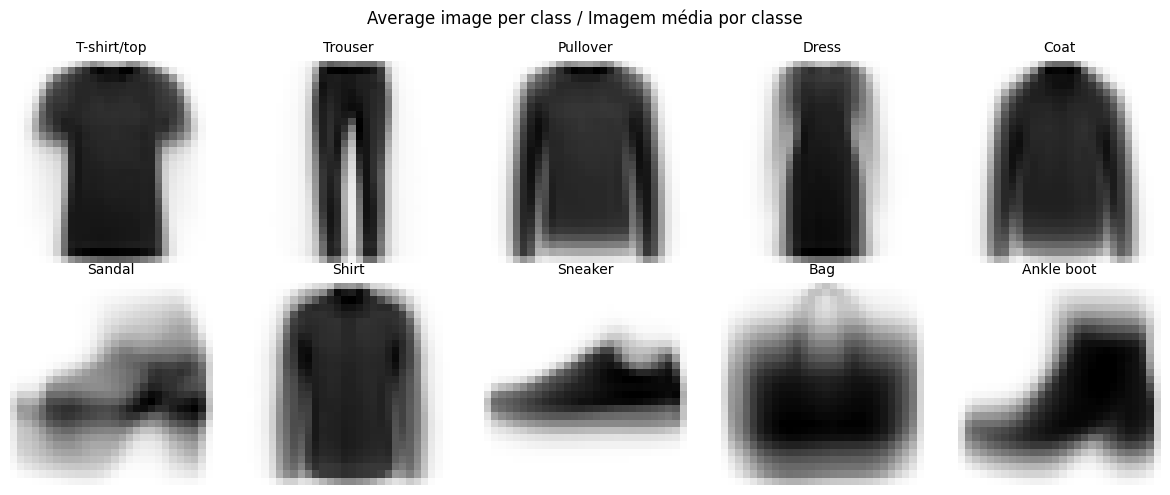

In [30]:
# average image per class / imagem média por classe
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_id, ax in enumerate(axes.ravel()):
    ax.imshow(images[labels == class_id].mean(axis=0), cmap="gray_r")
    ax.set_title(class_names[class_id], fontsize=10)
    ax.axis("off")

plt.suptitle("Average image per class / Imagem média por classe")
plt.tight_layout()
plt.show()

### Average Image per Class

The grid shows the pixel-wise mean of all 6,000 training images of each class.
Sharp areas mean the class has a consistent shape and position. Blurry areas
mean high intra-class variability.

**Sharp averages (consistent shapes)**
- **Trouser:** the two legs and the gap between them are clearly defined, with
  almost no blur at the edges. This is the most rigid silhouette in the
  dataset and the easiest class to learn.
- **T-shirt/top:** the torso and short sleeves are well defined, with a slight
  halo around the sleeves caused by different sleeve lengths and cuts.
- **Dress:** a narrow, vertical silhouette with soft edges, since dresses vary
  in width and length but keep the same overall layout.
- **Sneaker:** a low, horizontal profile with a clear sole line. The shape is
  very stable, which explains why this class is usually predicted with high
  confidence.

**Blurry averages (high variability)**
- **Sandal:** the most diffuse average, with no clear contour. Straps, heels
  and open fronts vary a lot, so there is no single dominant shape. The model
  must rely on local patterns (straps, gaps) rather than on the global
  silhouette.
- **Bag:** a rectangular dark mass with a faint handle at the top. The body is
  consistent, but handles, straps and proportions differ across samples.
- **Ankle boot:** the shaft and the sole are visible, but the top edge and the
  shaft height are blurred by variation in boot height.

**Overlapping upper-body garments**
- **Pullover, Coat and Shirt:** the three averages are almost the same
  silhouette: a torso with long sleeves, a narrow neckline and cuffs at the
  bottom. The only visible differences are small, such as a slightly darker
  center line in Coat and Shirt (zipper or buttons) and a wider body in Pullover.
- **T-shirt/top vs the others:** it differs mainly by the short sleeves, but
  long-sleeve tops inside this class and short-sleeve items inside Shirt blur
  the boundary.
- **Practical consequence:** an average image is a simple template, and these
  templates are nearly interchangeable. A model that relies on global shape
  will confuse these classes, so it needs to learn fine details such as
  collars, buttons, zippers and hoods, which are partially lost at 28x28.

**Implications for modeling**
- Footwear and Trouser should reach very high precision and recall. Bag
  should also do well because its shape is unlike any other class.
- Most errors should concentrate in Shirt, Pullover, Coat and T-shirt/top. The
  confusion matrices should confirm the pairs Shirt vs T-shirt/top, Shirt vs
  Pullover and Pullover vs Coat as the main error sources.
- The CNN convolutional filters can capture local details (edges, seams,
  vertical lines of zippers) that the average image hides. This is the
  reason a CNN is expected to outperform simple models on these classes.
- For the business problem, these four categories are the best candidates for
  human review when the model confidence is

# Part 6 - Train Teste split

In [31]:
# reproducibility / reprodutibilidade
keras.utils.set_random_seed(42)

In [32]:
# split labels and pixels, scale to [0, 1] / separar rótulos e pixels, escalar para [0, 1]
y_full = df_train["label"].values
X_full = df_train.drop(columns="label").values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_test = df_test["label"].values
X_test = df_test.drop(columns="label").values.reshape(-1, 28, 28, 1).astype("float32") / 255.0

In [33]:
# stratified validation split / divisão de validação estratificada
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, stratify=y_full, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape)

(48000, 28, 28, 1) (12000, 28, 28, 1) (10000, 28, 28, 1)


### Dataset Shapes and Data Split

Output: `(48000, 28, 28, 1) (12000, 28, 28, 1) (10000, 28, 28, 1)`

Each tuple follows the format `(samples, height, width, channels)`, which is the
input layout expected by Keras convolutional layers.

| Split | Images | Share of total | Images per class | Purpose |
|---|---|---|---|---|
| Train | 48,000 | 68.6% | 4,800 | Fit the model weights |
| Validation | 12,000 | 17.1% | 1,200 | Early stopping, learning rate scheduling and model selection |
| Test | 10,000 | 14.3% | 1,000 | Final, unbiased evaluation |
| **Total** | **70,000** | 100% | 7,000 | |

**Split strategy**
- The original 60,000 training images were divided 80/20 into train (48,000)
  and validation (12,000) with `stratify=y_full` and `random_state=42`. Each
  class keeps exactly the same proportion in both subsets, and the split is
  reproducible.
- The 10,000 test images are the official Zalando test set. They were never
  used for training, tuning or early stopping, so the test metrics estimate
  real-world performance.
- The same split is reused by the baseline CNN and by all transfer learning
  models, so the comparison between them is fair.

**Image format**
- **28 x 28:** a small resolution, so fine details such as collars, buttons and
  zippers are partially lost. This is the main reason Shirt, T-shirt/top,
  Pullover and Coat are the hardest classes.
- **1 channel:** grayscale. The pre-trained backbones expect 3 channels, so in
  Section B the images are converted to RGB with `Concatenate` and upscaled to
  96x96 with `Resizing`, both inside the model.
- **Values in [0, 1]:** pixels were divided by 255 and stored as `float32`.

**Memory footprint**
- The training array uses 48,000 x 784 x 4 bytes, about 150 MB, which fits
  easily in RAM and GPU memory.
- Resizing to 96x96x3 outside the model would multiply this by about 35 (to
  roughly 5.3 GB for the training set). Doing the resize inside the model
  avoids that cost.

**Implications for modeling**
- With 4,800 balanced images per class for training, there is enough data to
  train a small CNN from scratch without heavy augmentation.
- The validation set is large enough (1,200 per class) to give stable signals
  for early stopping, so noisy validation curves are unlikely.
- Test metrics have a low sampling error. With 10,000 images, a difference of
  about 0.5 percentage points in accuracy between two models is already near
  the noise level, so small gaps in the final comparison should be interpreted
  with caution.

# **Section A) Convolutional Neural Network**

# Part 5 - CNN Convolutional Neural Network

In [34]:
# CNN architecture / arquitetura da CNN
cnn_model = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),

        # block 1 / bloco 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # block 2 / bloco 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # block 3 / bloco 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # classifier head / camada de classificação
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ],
    name="cnn_baseline",
)

# compile the model / compilar o modelo
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,618 (1.10 MB)

 Trainable params: 288,170 (1.10 MB)

 Non-trainable params: 448 (1.75 KB)

### Baseline CNN Architecture Analysis

The model has **288,618 parameters** (1.10 MB), 288,170 trainable and 448 non-trainable. It has three convolutional blocks followed by a dense classifier.

#### 1. Notation

- $H, W$: height and width of the feature map; $C_{in}, C_{out}$: input and output channels
- $k$: kernel size (3 for all convolutions); $s$: stride; $p$: padding

#### 2. Output shape formulas

Convolution and pooling output size:

$$o = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1$$

- **Conv2D with `padding="same"` and $s=1$:** $o = n$, so the size is preserved (28 → 28, 14 → 14, 7 → 7).
- **MaxPooling2D (2x2, $s=2$, no padding):** $o = \lfloor (n-2)/2 \rfloor + 1$, which gives 28 → 14 → 7 → **3**. Since 7 is odd, the last row and column of the 7x7 map are discarded.
- **Flatten:** $3 \times 3 \times 128 = 1152$ features.

#### 3. Parameter count

Convolution (weights plus one bias per filter):

$$P_{conv} = (k \cdot k \cdot C_{in} + 1) \cdot C_{out}$$

Dense:

$$P_{dense} = (n_{in} + 1) \cdot n_{out}$$

BatchNormalization (4 vectors of size $C$):

$$P_{BN} = 4C \quad (2C \text{ trainable: } \gamma, \beta;\; 2C \text{ non-trainable: moving mean and variance})$$

| Layer | Calculation | Parameters |
|---|---|---|
| conv2d | $(3 \cdot 3 \cdot 1 + 1) \cdot 32$ | 320 |
| batch_normalization | $4 \cdot 32$ | 128 |
| conv2d_1 | $(3 \cdot 3 \cdot 32 + 1) \cdot 32$ | 9,248 |
| conv2d_2 | $(3 \cdot 3 \cdot 32 + 1) \cdot 64$ | 18,496 |
| batch_normalization_1 | $4 \cdot 64$ | 256 |
| conv2d_3 | $(3 \cdot 3 \cdot 64 + 1) \cdot 64$ | 36,928 |
| conv2d_4 | $(3 \cdot 3 \cdot 64 + 1) \cdot 128$ | 73,856 |
| batch_normalization_2 | $4 \cdot 128$ | 512 |
| dense | $(1152 + 1) \cdot 128$ | 147,584 |
| dense_1 | $(128 + 1) \cdot 10$ | 1,290 |
| **Total** | | **288,618** |

Non-trainable parameters: $2 \cdot (32 + 64 + 128) = 448$, which matches the summary. Pooling, dropout and flatten have no parameters.

Memory in float32: $288{,}618 \times 4 \text{ bytes} \approx 1.15 \text{ MB}$ (1.10 MiB).

**Where the parameters are**

| Group | Parameters | Share |
|---|---|---|
| Convolutions | 138,848 | 48.1% |
| Dense layers | 148,874 | 51.6% |
| BatchNormalization | 896 | 0.3% |

The `dense` layer alone holds 51.1% of all parameters, because it connects 1,152 flattened features to 128 units.

#### 4. Computational cost

Multiply-accumulate operations (MACs) per convolution:

$$\text{MACs}_{conv} = H_{out} \cdot W_{out} \cdot k^2 \cdot C_{in} \cdot C_{out}$$

| Layer | Calculation | MACs |
|---|---|---|
| conv2d | $28 \cdot 28 \cdot 9 \cdot 1 \cdot 32$ | 225,792 |
| conv2d_1 | $28 \cdot 28 \cdot 9 \cdot 32 \cdot 32$ | 7,225,344 |
| conv2d_2 | $14 \cdot 14 \cdot 9 \cdot 32 \cdot 64$ | 3,612,672 |
| conv2d_3 | $14 \cdot 14 \cdot 9 \cdot 64 \cdot 64$ | 7,225,344 |
| conv2d_4 | $7 \cdot 7 \cdot 9 \cdot 64 \cdot 128$ | 3,612,672 |
| dense | $1152 \cdot 128$ | 147,456 |
| dense_1 | $128 \cdot 10$ | 1,280 |
| **Total** | | **about 22.05 M MACs (about 44 MFLOPs per image)** |

The convolutions use 99.3% of the compute but only 48% of the parameters, while the dense layers are the opposite (0.7% of compute, 52% of parameters). The two convolutions at full 28x28 resolution (`conv2d` and `conv2d_1`) alone cost about 34% of the total.

#### 5. Receptive field

$$RF_l = RF_{l-1} + (k_l - 1) \cdot j_{l-1}, \qquad j_l = j_{l-1} \cdot s_l$$

| After layer | Receptive field | Jump $j$ |
|---|---|---|
| conv2d, conv2d_1 | 3, 5 | 1 |
| max_pooling2d | 6 | 2 |
| conv2d_2, conv2d_3 | 10, 14 | 2 |
| max_pooling2d_1 | 16 | 4 |
| conv2d_4 | 24 | 4 |
| max_pooling2d_2 | 28 | 8 |

At the last pooling layer, each feature sees the **whole 28x28 image**. Early layers capture edges and seams, and the last block combines them into global shapes such as collars, sleeves and straps.

#### 6. Layer functions and formulas

- **ReLU:** $f(x) = \max(0, x)$. It adds non-linearity and avoids vanishing gradients.
- **BatchNormalization:** normalizes each channel over the mini-batch $B$:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y = \gamma \hat{x} + \beta$$

  It stabilizes training and allows a higher learning rate. At inference it uses the moving averages (the 448 non-trainable parameters).
- **Dropout (inverted):** during training each unit is zeroed with probability $p$ and the rest are scaled by $1/(1-p)$. Here $p = 0.25$ after each convolutional block and $p = 0.5$ before the output layer, so regularization is strongest where the parameters are concentrated.
- **Softmax output:**

$$\hat{y}_c = \frac{e^{z_c}}{\sum_{j=1}^{10} e^{z_j}}$$

- **Loss (sparse categorical cross-entropy):**

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \hat{y}_{i, y_i}$$

  A model that guesses at random gives $\mathcal{L} = \ln 10 \approx 2.303$, which is the reference value for the first epoch.
- **Adam update** (learning rate $\eta = 10^{-3}$):

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

#### 7. Design analysis

**Strengths**
- **Channels double as resolution halves** (32 → 64 → 128 while 28 → 14 → 7). This is the usual pattern for keeping the cost per block balanced while increasing feature richness.
- **Two convolutions per block** (VGG style) give a $5 \times 5$ effective field with fewer parameters than a single $5 \times 5$ convolution: $2 \cdot 9 C^2 = 18C^2$ versus $25C^2$.
- **Small model:** about 6 parameters per training image ($288{,}618 / 48{,}000$). BatchNormalization, dropout and early stopping keep overfitting under control.
- **Cheap inference:** about 44 MFLOPs per image, so it runs comfortably on CPU, which matters for the business problem.

**Points to review**
- **Block 3 has a single convolution** and no dropout between convolutions, so it is slightly asymmetric compared with blocks 1 and 2. This is a reasonable choice for 7x7 maps.
- **BatchNormalization comes after ReLU** (conv → ReLU → BN). It works well in practice, but the original order is conv → BN → ReLU. Testing both is a cheap ablation.
- **BatchNormalization is missing in `conv2d_1` and `conv2d_3`.** Only the first convolution of each block is normalized.
- **Flatten + Dense(128) concentrates 51% of the parameters.** Replacing `Flatten` with `GlobalAveragePooling2D` would reduce the dense layer from 147,584 to $(128+1) \cdot 128 = 16{,}512$ parameters, saving 131,072 (45% of the model). It would also remove the dependency on the 3x3 map size, with a possible small loss in accuracy.
- **Pooling truncates the 7x7 map to 3x3**, discarding the last row and column. Using `padding="same"` in the last pooling layer would give 4x4 and keep the border information.

#### 8. Comparison with the transfer learning backbones

The baseline has about 0.29 M parameters, roughly **8 times fewer than the smallest backbone of Section B** (MobileNetV2, about 2.3 M) and about 50 to 80 times fewer than VGG16, VGG19 and ResNet50 (14.7 M to 23.6 M). It also works on 28x28 inputs instead of 96x96, so each image costs far fewer operations. If its accuracy and macro F1 are close to the pre-trained models, it is the better deployment choice.

In [35]:
# callbacks / callbacks de treinamento
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5
    ),
]

# train the model / treinar o modelo
start_time = time.time()
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1,
)
cnn_train_time = time.time() - start_time
print(f"Training time: {cnn_train_time:.1f}s")

Epoch 1/50
 14/375 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1938 - loss: 3.4920  

I0000 00:00:1791061084.045822     160 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7202 - loss: 0.7889 - val_accuracy: 0.5860 - val_loss: 1.1546
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8343 - loss: 0.4600 - val_accuracy: 0.8701 - val_loss: 0.3478
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8629 - loss: 0.3807 - val_accuracy: 0.8915 - val_loss: 0.2919
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8760 - loss: 0.3453 - val_accuracy: 0.8857 - val_loss: 0.3134
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8868 - loss: 0.3170 - val_accuracy: 0.9082 - val_loss: 0.2552
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8939 - loss: 0.2947 - val_accuracy: 0.8997 - val_loss: 0.2675
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9010 - loss: 0.2766 - val_accuracy: 0.9150 - val_loss: 0.2308
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9016 - loss: 0.2696 - val_accuracy: 0.91

### Training Configuration Analysis (Baseline CNN)

#### 1. Notation

- $N_{train} = 48{,}000$, $N_{val} = 12{,}000$, batch size $B = 128$, epochs $E = 50$
- $\theta$: model parameters (288,618), $\eta$: learning rate, $t$: update step
- $\mathcal{L}_{train}^{(e)}, \mathcal{L}_{val}^{(e)}$: loss at epoch $e$

#### 2. Training steps

$$\text{steps per epoch} = \left\lceil \frac{N_{train}}{B} \right\rceil = \left\lceil \frac{48000}{128} \right\rceil = 375$$

$$\text{total updates} = E \cdot 375 = 50 \cdot 375 = 18{,}750$$

Since $48000 / 128 = 375$ exactly, there is no smaller last batch. Validation uses $\lceil 12000/128 \rceil = 94$ steps per epoch, with a last batch of 96 images ($12000 - 93 \cdot 128$). Each epoch reshuffles the training data (`shuffle=True` is the Keras default).

Each epoch shows the model $48{,}000$ images, so the whole run processes $2.4 \cdot 10^6$ training samples, or $50$ passes over the data.

#### 3. Objective and optimizer

Mini-batch loss (sparse categorical cross-entropy):

$$\mathcal{L}_B(\theta) = -\frac{1}{B} \sum_{i \in B} \log \hat{y}_{i, y_i}(\theta)$$

Adam update with Keras defaults ($\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-7}$):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad \theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

- The step size per parameter is roughly bounded by $\eta$, so with $\eta = 10^{-3}$ no weight moves more than about $10^{-3}$ per update.
- With a constant $\eta$ over 18,750 updates, the weights keep oscillating around a minimum instead of settling into it. A decaying learning rate lets the model converge more precisely, which is the role of `ReduceLROnPlateau`.
- Gradient noise scales as $\sigma / \sqrt{B}$. With $B = 128$ the estimate is reasonably stable, and BatchNormalization statistics are computed over the same 128 samples.

#### 4. Callbacks (defined but not active)

**EarlyStopping** (`patience=5`, `min_delta=0` by default). An epoch counts as an improvement if

$$\mathcal{L}_{val}^{(e)} < \min_{j<e} \mathcal{L}_{val}^{(j)}$$

and training stops when there are 5 consecutive epochs without improvement. With `restore_best_weights=True`, the final weights are

$$\theta^* = \theta^{(e^*)}, \qquad e^* = \arg\min_e \mathcal{L}_{val}^{(e)}$$

The model that is kept is therefore not the last one, but the one with the best validation loss.

**ReduceLROnPlateau** (`factor=0.5`, `patience=2`, `min_lr=1e-5`). After 2 epochs without improvement:

$$\eta_{new} = \max(\eta \cdot 0.5,\; \eta_{min})$$

Number of halvings needed to go from $10^{-3}$ to the floor:

$$n = \left\lceil \log_2 \frac{10^{-3}}{10^{-5}} \right\rceil = \lceil \log_2 100 \rceil = \lceil 6.64 \rceil = 7$$

| Reductions | Learning rate |
|---|---|
| 0 | 1.0e-3 |
| 1 | 5.0e-4 |
| 2 | 2.5e-4 |
| 3 | 1.25e-4 |
| 4 | 6.25e-5 |
| 5 | 3.13e-5 |
| 6 | 1.56e-5 |
| 7 | 1.0e-5 (clipped by `min_lr`) |

**Interaction between the two callbacks.** The learning rate drops after 2 stagnant epochs, while early stopping needs 5. In a continuous stagnation, the reductions happen at stagnant epochs 2 and 4, and training stops at epoch 5. So the model gets at most 2 reductions ($10^{-3} \to 2.5 \cdot 10^{-4}$) in a row. Reaching $10^{-5}$ only happens if validation loss keeps improving intermittently. If you want a longer decay phase, use `patience=8` or `10` in `EarlyStopping`, or `patience=1` in `ReduceLROnPlateau`.

#### 5. Current behavior (without `callbacks=callbacks`)

| Aspect | Without callbacks (current) | With callbacks |
|---|---|---|
| Learning rate | constant $10^{-3}$ | $10^{-3}$ decaying to as low as $10^{-5}$ |
| Epochs run | 50 | $\le 50$, stops early |
| Final weights | epoch 50 | epoch $e^*$ (best $\mathcal{L}_{val}$) |
| Updates | 18,750 | $375 \cdot e_{stop}$ |
| Overfitting risk | higher | lower |

Without early stopping, the model can pass its best point and keep fitting the training noise. The size of the damage is measured by the generalization gap:

$$\text{gap}^{(e)} = \mathcal{L}_{val}^{(e)} - \mathcal{L}_{train}^{(e)}$$

If $\mathcal{L}_{val}$ rises after epoch $e^*$ while $\mathcal{L}_{train}$ keeps falling, the extra epochs are only overfitting. Dropout (0.25 and 0.5), BatchNormalization and the small size of the model (about 6 parameters per image) reduce this risk, but do not remove it.

#### 6. Time and cost

$$T_{epoch} = \frac{T_{total}}{E_{run}}, \qquad \text{throughput} = \frac{N_{train} \cdot E_{run}}{T_{total}} \;\text{(images/s)}$$

A training step costs about 3 times the forward pass (forward, backward for activations, backward for weights). With about 44 MFLOPs per forward image (from the architecture analysis):

$$\text{FLOPs}_{epoch} \approx 3 \cdot 44 \cdot 10^6 \cdot 48000 \approx 6.3 \text{ TFLOPs}$$

$$\text{FLOPs}_{50\,epochs} \approx 317 \text{ TFLOPs} \;(+\, 12000 \cdot 44 \cdot 10^6 \cdot 50 \approx 26 \text{ TFLOPs for validation})$$

A T4 reaches about 8 TFLOPS in float32 at peak, so the theoretical minimum is around 45 seconds. In practice, small convolutions, data transfer and Python overhead keep utilization low, so expect a few seconds per epoch and a few minutes in total. This is also the number saved in `cnn_train_time` for the final comparison.

#### 7. Reading the training log

- **Epoch 1:** $\mathcal{L}_{train}$ should start near or below $\ln 10 \approx 2.303$ (random guessing) and fall quickly. Because of dropout, training accuracy is often lower than validation accuracy in the first epochs, which is normal.
- **Healthy

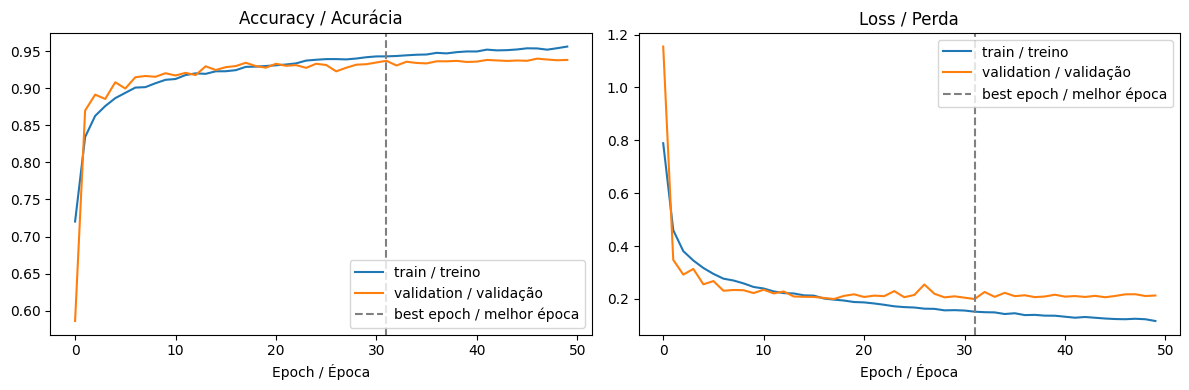

In [36]:
"""Training performance chart for the baseline CNN.

Shows accuracy and loss for the training and validation sets per epoch.
"""

# best epoch from validation loss / melhor época pela perda de validação
best_epoch = int(np.argmin(history.history["val_loss"]))

# accuracy and loss curves / curvas de acurácia e perda
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train / treino")
axes[0].plot(history.history["val_accuracy"], label="validation / validação")
axes[0].axvline(best_epoch, color="gray", linestyle="--", label="best epoch / melhor época")
axes[0].set_title("Accuracy / Acurácia")
axes[0].set_xlabel("Epoch / Época")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train / treino")
axes[1].plot(history.history["val_loss"], label="validation / validação")
axes[1].axvline(best_epoch, color="gray", linestyle="--", label="best epoch / melhor época")
axes[1].set_title("Loss / Perda")
axes[1].set_xlabel("Epoch / Época")
axes[1].legend()

plt.tight_layout()
plt.show()

### Training Curves Analysis (Baseline CNN)

The chart shows 50 epochs (0 to 49), which confirms that **training ran to the end without early stopping** (the `callbacks` list was not passed to `fit`). The dashed line marks the epoch with the lowest validation loss, at about epoch 29 (0-indexed), and the weights at the end of training are those of epoch 49, not the best ones.

#### 1. Values read from the chart (approximate)

| Metric | Epoch 0 | Epoch ~29 (best) | Epoch 49 (final) |
|---|---|---|---|
| Train accuracy | 0.72 | 0.94 | 0.955 |
| Validation accuracy | 0.39 | 0.93 | 0.935 |
| Train loss | 0.79 | 0.16 | 0.12 |
| Validation loss | 2.05 | 0.20 | 0.24 |

Values are visual estimates. Confirm them with `history.history`.

#### 2. Phase 1: fast learning (epochs 0 to 3)

- Train loss starts at 0.79, already below the random-guess reference:

$$\mathcal{L}_{random} = \ln 10 \approx 2.303$$

- Validation loss starts at **2.05**, close to $\ln 10$, and validation accuracy at **0.39**. This is not a bug: in epoch 0, BatchNormalization moving averages have not converged yet, so inference-mode statistics differ from the batch statistics used in training. By epoch 1, validation accuracy jumps above 0.85 and loss falls to about 0.4.
- Validation is below training in epoch 0 for this reason, and in general because dropout is active only in training. The accuracy gap is

$$\text{gap}_{acc}^{(e)} = Acc_{train}^{(e)} - Acc_{val}^{(e)}$$

  which is large and negative-to-positive in the first epochs, then stabilizes.

#### 3. Phase 2: convergence (epochs 4 to 29)

Both losses fall slowly and validation tracks training closely, which signals good generalization. Validation accuracy reaches a plateau of about 0.93 and train accuracy keeps rising slowly.

The training loss follows approximately a decaying curve:

$$\mathcal{L}(e) \approx \mathcal{L}_\infty + A \, e^{-e/\tau}$$

The fast drop in the first epochs corresponds to a small $\tau$ (about 1 to 2 epochs), followed by a long tail where gains per epoch are below 0.005.

#### 4. Phase 3: overfitting (epochs 30 to 49)

After the dashed line, the curves diverge:

- Train loss keeps falling from about 0.16 to 0.12 (about 25% lower).
- Validation loss stops improving and fluctuates around 0.21 to 0.24, ending at 0.24, above its minimum of about 0.20.
- Train accuracy rises to about 0.955 while validation stays near 0.93 to 0.94.

The generalization gap in loss:

$$\text{gap}_{loss}^{(e)} = \mathcal{L}_{val}^{(e)} - \mathcal{L}_{train}^{(e)}$$

| Epoch | $\mathcal{L}_{val}$ | $\mathcal{L}_{train}$ | gap |
|---|---|---|---|
| 29 | 0.20 | 0.16 | 0.04 |
| 49 | 0.24 | 0.12 | 0.12 |

The gap triples from about 0.04 to 0.12. The extra 20 epochs improve only the fit to the training set, which is classic mild overfitting. Dropout, BatchNormalization and the small model size (about 6 parameters per image) keep it mild, since validation loss does not explode.

#### 5. Cost of not using early stopping

With early stopping (`patience=5`, `restore_best_weights=True`), the final weights would be:

$$\theta^* = \theta^{(e^*)}, \qquad e^* = \arg\min_e \mathcal{L}_{val}^{(e)} \approx 29$$

| Aspect | Current run | With callbacks |
|---|---|---|
| Epochs run | 50 | about 34 (29 + patience 5) |
| Updates | $50 \cdot 375 = 18{,}750$ | about $34 \cdot 375 = 12{,}750$ |
| Final $\mathcal{L}_{val}$ | about 0.24 | about 0.20 |
| Training time | 100% | about 68% |

Expected gain: roughly 0.04 in validation loss and 30% less time, with accuracy equal or slightly better.

#### 6. Noise in the validation curve

Validation oscillates by about $\pm 0.01$ in accuracy between epochs, with spikes (for example near epochs 12, 18 and 44). The standard error of an accuracy estimate on $N_{val} = 12{,}000$ images is

$$SE = \sqrt{\frac{p(1-p)}{N_{val}}} = \sqrt{\frac{0.93 \cdot 0.07}{12000}} \approx 0.0023$$

so a 95% interval is about $\pm 0.0046$. Epoch-to-epoch swings of 0.01 are larger than this, so they come mainly from the constant learning rate $\eta = 10^{-3}$ with Adam and BatchNormalization statistics, not from sampling error. A decaying $\eta$ (`ReduceLROnPlateau`) would smooth this noise.

#### 7. Conclusions

- **No underfitting:** training accuracy

# Part 6 - Metrics and evaluations

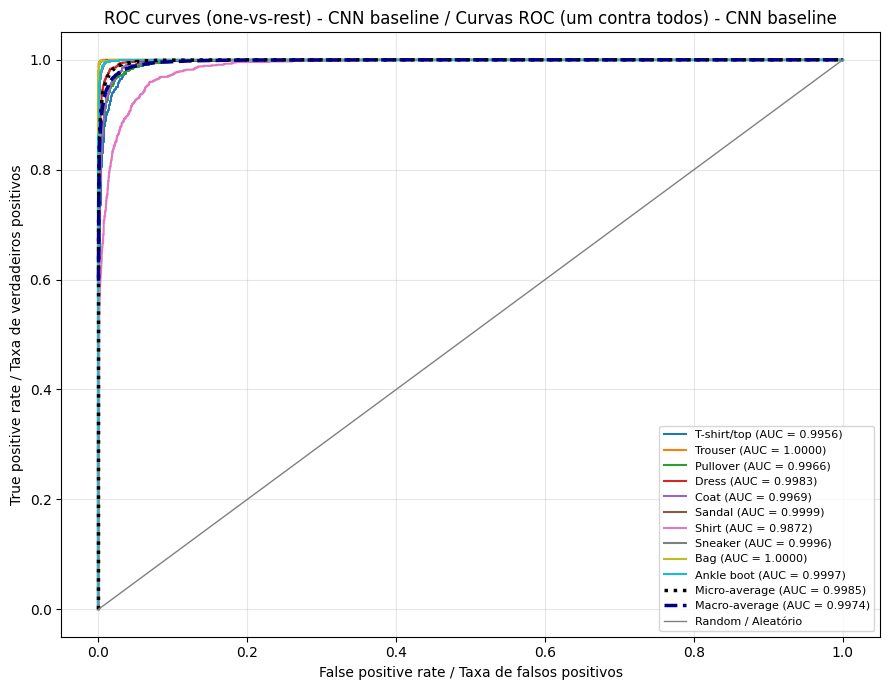

In [37]:
# predicted probabilities on the test set / probabilidades previstas no conjunto de teste
y_prob = cnn_model.predict(X_test, batch_size=256, verbose=0)

# one-hot encode the true labels / codificar os rótulos reais em one-hot
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# ROC curve and AUC per class / curva ROC e AUC por classe
fpr, tpr, roc_auc = {}, {}, {}
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average / média micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# macro-average / média macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ROC plot / gráfico da curva ROC
plt.figure(figsize=(9, 7))

colors = plt.cm.tab10(np.arange(10))
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})")

plt.plot(fpr["micro"], tpr["micro"], color="black", linestyle=":", lw=2.5,
         label=f"Micro-average (AUC = {roc_auc['micro']:.4f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle="--", lw=2.5,
         label=f"Macro-average (AUC = {roc_auc['macro']:.4f})")

# random classifier reference / referência de classificador aleatório
plt.plot([0, 1], [0, 1], color="gray", linestyle="-", lw=1, label="Random / Aleatório")

plt.title("ROC curves (one-vs-rest) - CNN baseline / Curvas ROC (um contra todos) - CNN baseline")
plt.xlabel("False positive rate / Taxa de falsos positivos")
plt.ylabel("True positive rate / Taxa de verdadeiros positivos")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ROC Curve Analysis (Baseline CNN)

The chart shows one-vs-rest ROC curves for the 10 classes on the 10,000-image test set, with micro-average (AUC = 0.9982) and macro-average (AUC = 0.9970). All curves hug the top-left corner, so the model separates every class from the rest very well.

#### 1. Notation and formulas

For each class $c$, treated as positive against the other nine, and a threshold $\tau$ on the predicted probability $\hat{y}_c$:

$$TPR(\tau) = \frac{TP(\tau)}{TP(\tau) + FN(\tau)}, \qquad FPR(\tau) = \frac{FP(\tau)}{FP(\tau) + TN(\tau)}$$

The ROC curve plots $TPR$ against $FPR$ as $\tau$ goes from 1 to 0. The area under it:

$$AUC_c = \int_0^1 TPR \; d(FPR)$$

It has a probabilistic meaning: the chance that a random positive image receives a higher score than a random negative one.

$$AUC_c = P\left(\hat{y}_c(x^+) > \hat{y}_c(x^-)\right)$$

- $AUC = 0.5$: random classifier (the diagonal line). $AUC = 1$: perfect ranking.
- In this test set, each class has $1{,}000$ positives and $9{,}000$ negatives per one-vs-rest problem.

**Averages**

$$AUC_{macro} = \frac{1}{10} \sum_{c=1}^{10} AUC_c, \qquad AUC_{micro} = AUC\left(\text{all } 10{,}000 \cdot 10 \text{ decisions pooled}\right)$$

Macro gives equal weight to each class. Micro pools all (image, class) pairs, so it is dominated by the many easy negatives and tends to be higher.

#### 2. AUC per class (read from the legend)

| Class | AUC | $1 - AUC$ (ranking error) |
|---|---|---|
| Bag | 1.0000 | about 0 |
| Trouser | 0.9999 | 0.0001 |
| Sandal | 0.9998 | 0.0002 |
| Ankle boot | 0.9996 | 0.0004 |
| Sneaker | 0.9995 | 0.0005 |
| Dress | 0.9981 | 0.0019 |
| Coat | 0.9963 | 0.0037 |
| Pullover | 0.9956 | 0.0044 |
| T-shirt/top | 0.9949 | 0.0051 |
| **Shirt** | **0.9862** | **0.0138** |

Check of the macro average:

$$\frac{1.0000 + 0.9999 + 0.9998 + 0.9996 + 0.9995 + 0.9981 + 0.9963 + 0.9956 + 0.9949 + 0.9862}{10} = \frac{9.9699}{10} \approx 0.9970$$

This matches the legend (0.9970).

#### 3. Interpretation

**Perfect or near-perfect classes (AUC at least 0.9995):** Bag, Trouser, Sandal, Ankle boot and Sneaker. For Bag, a random Bag image almost always scores higher than a non-Bag image. These shapes are unlike any other class, as seen in the average images.

**Intermediate (0.995 to 0.998):** Dress, Coat, Pullover and T-shirt/top. Their curves leave the corner slightly (the blue, green and purple curves near $FPR \approx 0.02$ to $0.05$). They share silhouettes with other upper-body garments.

**Hardest class: Shirt (0.9862).** The pink curve is clearly below the others. To reach $TPR = 0.9$ it needs $FPR \approx 0.05$ to $0.08$, and it only gets close to $TPR = 1$ at $FPR \approx 0.2$. Its ranking error ($1 - AUC = 0.0138$) is about 3 times that of the next worst class (T-shirt/top, 0.0051) and about 14 times that of Sneaker. This matches the earlier analysis: Shirt overlaps with T-shirt/top, Pullover and Coat.

#### 4. Micro vs macro

$$AUC_{micro} = 0.9982 > AUC_{macro} = 0.9970$$

The micro average is higher because it is weighted by decisions, and 90% of them are easy negatives. The macro average is pulled down by Shirt: without it, the mean of the other nine would be

$$\frac{9.9699 - 0.9862}{9} = \frac{8.9837}{9} \approx 0.9982$$

so Shirt alone lowers the macro AUC by about 0.0012.

#### 5. Why the chart is hard to read

With AUC values this high, the curves overlap at the top-left corner. Zooming into $FPR \in [0, 0.1]$ and $TPR \in [0.8, 1]$ (the second figure in the ROC cell) separates them. In this region, the useful quantity is the **partial AUC** or the TPR at a fixed low FPR, for example $TPR$ at $FPR = 0.01$.

#### 6. Limits of the ROC/AUC metric here

- **AUC measures ranking, not classification.** It does not depend on the argmax decision, so a class can have AUC 0.99 and still have many misclassifications. Shirt, for example, has $AUC = 0.9862$ but its F1 is far lower (around 0.78 to 0.83).
- **Class imbalance in one-vs-rest.** Each binary problem is 1:9, so FPR is diluted by the many negatives. For heavily imbalanced cases, the precision-recall curve is more informative:

$$Precision = \frac{TP}{TP + FP}, \qquad Recall = TPR$$

- **No threshold chosen.** ROC does not tell which operating point to use. In production, the threshold should be chosen from the cost of errors (for example, sending a low-confidence Shirt to human review).

#### 7. Conclusions

- The baseline CNN has excellent discrimination: macro AUC 0.9970 and micro AUC 0.9982.
- Five classes are almost perfectly separable (AUC at least 0.9995).
- **Shirt is the bottleneck**, followed by T-shirt/top, Pullover and Coat, the same group identified in the dataset analysis.
- For the business problem, a confidence threshold on the predicted probability can route uncertain upper-body items to human review, at a low cost in volume, because the curves show that high TPR is reached at low FPR for most classes.
- In Section B, compare models with macro AUC, and with the AUC of Shirt, T-shirt/top, Pullover and Coat separately, since differences in the other classes will be in the fourth decimal place.

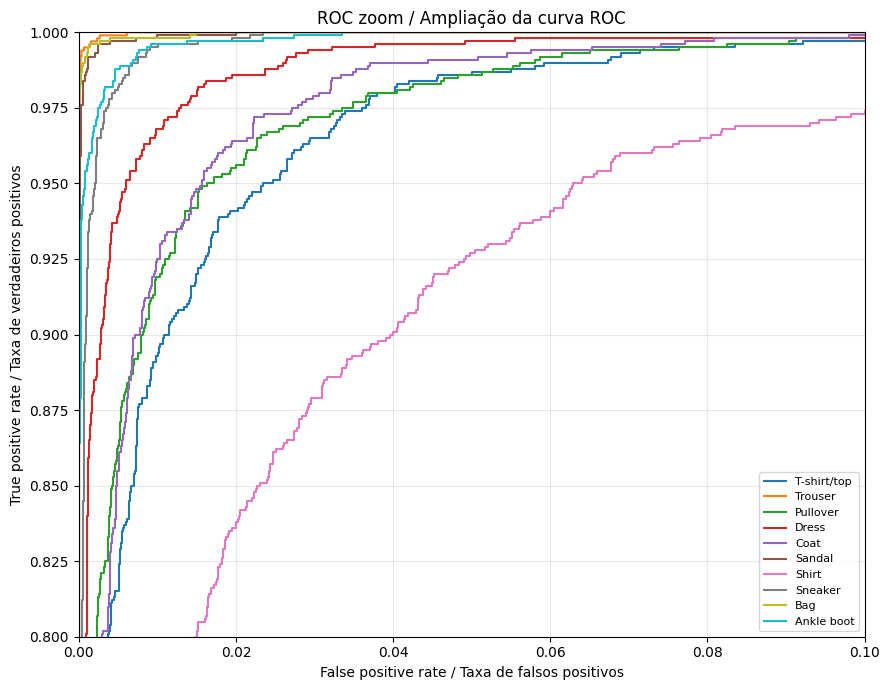

Shirt: 0.9872
T-shirt/top: 0.9956
Pullover: 0.9966
Coat: 0.9969
Dress: 0.9983
Sneaker: 0.9996
Ankle boot: 0.9997
Sandal: 0.9999
Bag: 1.0000
Trouser: 1.0000


In [38]:
# zoomed view of the top-left corner / visão ampliada do canto superior esquerdo
plt.figure(figsize=(9, 7))
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5, label=class_names[i])
plt.xlim(0, 0.1)
plt.ylim(0.8, 1.0)
plt.title("ROC zoom / Ampliação da curva ROC")
plt.xlabel("False positive rate / Taxa de falsos positivos")
plt.ylabel("True positive rate / Taxa de verdadeiros positivos")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC per class sorted / AUC por classe ordenado
for i in np.argsort([roc_auc[i] for i in range(10)]):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")

### ROC Zoom Analysis (Baseline CNN)

The zoom shows the region $FPR \in [0, 0.1]$ and $TPR \in [0.8, 1.0]$, where the curves that overlap in the full ROC become separable. The curve order here ranks the classes by how well they separate from the rest at low false positive rates.

#### 1. Reading formulas

For a threshold $\tau$ on the probability of class $c$:

$$TPR(\tau) = \frac{TP}{TP + FN}, \qquad FPR(\tau) = \frac{FP}{FP + TN}$$

Each class has 1,000 positives and 9,000 negatives, so the chart resolution is:

- One step up in $TPR$ equals $1/1000 = 0.001$.
- One step right in $FPR$ equals $1/9000 \approx 0.00011$.
- $FPR = 0.01$ corresponds to about **90 false positives**, and $FPR = 0.05$ to about **450**.

A useful way to compare curves in this region is the TPR at a fixed FPR (operating point), and the partial AUC:

$$pAUC = \int_0^{0.1} TPR \; d(FPR)$$

#### 2. Curves grouped by behavior (visual estimates)

| Group | Classes | Behavior in the zoom |
|---|---|---|
| Almost perfect | Trouser, Bag | Reach $TPR \approx 1$ at $FPR < 0.005$, stuck on the top-left corner |
| Very good | Sandal, Sneaker, Ankle boot | $TPR \ge 0.98$ at $FPR \approx 0.01$ to $0.02$ |
| Good | Dress | $TPR \approx 0.95$ at $FPR \approx 0.007$, $TPR \approx 0.99$ at $FPR \approx 0.04$ |
| Intermediate | Coat, Pullover, T-shirt/top | $TPR = 0.90$ at $FPR \approx 0.008$ to $0.014$, $TPR \approx 0.975$ at $FPR \approx 0.03$ to $0.04$ |
| Weak | **Shirt** | $TPR = 0.90$ only at $FPR \approx 0.04$, and $TPR \approx 0.975$ at $FPR = 0.10$ |

#### 3. Operating point comparison

| Class | FPR needed for $TPR = 0.90$ | Approx. false positives (of 9,000) |
|---|---|---|
| Dress | about 0.004 | about 36 |
| Coat | about 0.008 | about 72 |
| Pullover | about 0.010 | about 90 |
| T-shirt/top | about 0.014 | about 126 |
| **Shirt** | **about 0.040** | **about 360** |

To catch 90% of Shirts, the model accepts about 3 times more false alarms than T-shirt/top and about 4 to 5 times more than Coat. This is the same gap seen in the AUC values: $1 - AUC_{Shirt} = 0.0138$ versus $0.0051$ for T-shirt/top.

#### 4. Interpretation

- **Footwear, Trouser and Bag** have nearly vertical curves: almost every positive scores above almost every negative. They need no extra attention.
- **Dress** stays clearly above the intermediate group, which agrees with its distinct narrow silhouette in the average image.
- **Coat, Pullover and T-shirt/top** are clustered and cross each other, so their ranking quality is similar. Coat leads in the low-FPR range ($FPR < 0.03$) and T-shirt/top and Pullover are the lowest of the three.
- **Shirt** is far from the rest. The curve begins at $FPR \approx 0.018$ for $TPR = 0.8$, meaning that even a 20% miss rate already costs about 160 false positives. The reason is that Shirt has the highest overlap with T-shirt/top, Pullover and Coat, and the most heterogeneous samples, as seen in the dataset images.

#### 5. Practical use: choosing a threshold

A threshold choice is a point on the curve. For the human-review flow of the business problem:

$$\text{review rate} = \frac{TP + FP}{N} \quad \text{for the items flagged below the confidence threshold}$$

- Keeping $FPR$ near 0.01 gives $TPR$ above 0.95 for most classes, but only about 0.83 for Shirt.
- For Shirt, a higher recall requires accepting many false positives, so the best strategy is to **send low-confidence predictions among the upper-body classes to human review** rather than tune one global threshold.
- Per-class thresholds can be chosen by maximizing Youden's index:

$$J = TPR - FPR$$

or by minimizing an expected cost $C_{FN} \cdot FN + C_{FP} \cdot FP$ defined by the business.

#### 6. Limits of the reading

- **ROC measures ranking, not the final decision.** A class can have a curve near the corner and still have errors under argmax.
- **Steps are coarse for small counts.** With 1,000 positives, the vertical steps ($0.001$) and the jagged shape are normal sampling effects, not model instability.
- **One-vs-rest dilution.** With 9,000 negatives, FPR looks small even when false positives are many in absolute number. Precision-recall curves for Shirt, T-shirt/top, Pullover and Coat would show the cost more clearly.

#### 7. Conclusions

- The zoom confirms the ranking of difficulty: **Bag and Trouser < footwear < Dress < Coat, Pullover, T-shirt/top < Shirt**.
- Shirt is the single bottleneck of the baseline, with an operating cost 3 to 5 times higher than the other upper-body classes.
- In Section B, compare models using the zoomed ROC and the $TPR$ at $FPR = 0.01$ for these four classes. Gains from transfer learning, if any, should appear there and not in the other classes.

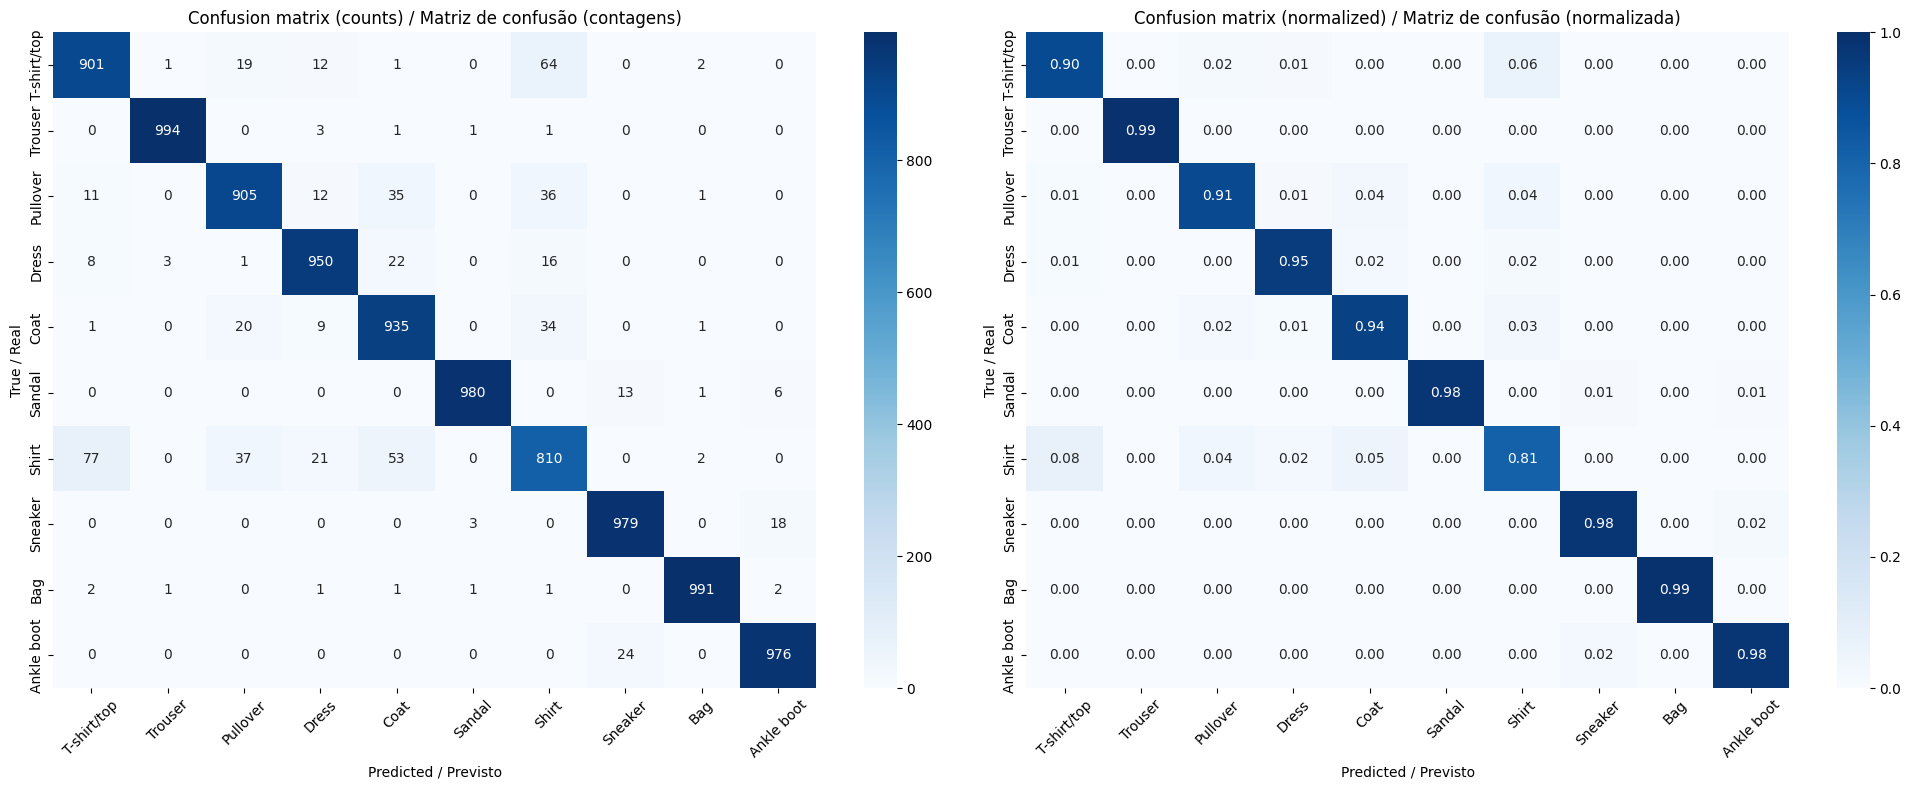

Shirt -> T-shirt/top: 77 errors
T-shirt/top -> Shirt: 64 errors
Shirt -> Coat: 53 errors
Shirt -> Pullover: 37 errors
Pullover -> Shirt: 36 errors


In [39]:
"""Confusion matrix for the baseline CNN on the Fashion MNIST test set.

Shows the confusion matrix with absolute counts and normalized by true class
(recall per class), side by side.
"""

# predictions on the test set / previsões no conjunto de teste
y_prob = cnn_model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# confusion matrices / matrizes de confusão
cm_counts = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

# side by side plot / gráfico lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    cm_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=class_names, yticklabels=class_names,
)
axes[0].set_title("Confusion matrix (counts) / Matriz de confusão (contagens)")
axes[0].set_xlabel("Predicted / Previsto")
axes[0].set_ylabel("True / Real")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1],
    xticklabels=class_names, yticklabels=class_names,
)
axes[1].set_title("Confusion matrix (normalized) / Matriz de confusão (normalizada)")
axes[1].set_xlabel("Predicted / Previsto")
axes[1].set_ylabel("True / Real")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# five most confused pairs / cinco pares mais confundidos
errors = cm_counts.copy()
np.fill_diagonal(errors, 0)
top_idx = np.dstack(np.unravel_index(np.argsort(errors.ravel())[::-1], errors.shape))[0][:5]
for true_id, pred_id in top_idx:
    print(f"{class_names[true_id]} -> {class_names[pred_id]}: {errors[true_id, pred_id]} errors")

### Confusion Matrix Analysis (Baseline CNN)

The matrix is computed on the 10,000-image test set (1,000 per class). The diagonal holds the correct predictions: 9,360 of 10,000. The remaining 640 images are errors.

#### 1. Notation and formulas

Let $C_{ij}$ be the number of images of true class $i$ predicted as class $j$. Rows are true classes and columns are predicted classes.

$$Acc = \frac{\sum_i C_{ii}}{N} = \frac{9360}{10000} = 0.9360$$

$$Recall_i = \frac{C_{ii}}{\sum_j C_{ij}}, \qquad Precision_j = \frac{C_{jj}}{\sum_i C_{ij}}, \qquad F1_i = \frac{2 \cdot P_i \cdot R_i}{P_i + R_i}$$

The right panel normalizes each row by its sum, so its diagonal is the recall of each class. Because the test set is balanced (1,000 per row), the row sums are all equal.

#### 2. Per-class metrics (computed from the counts)

| Class | Correct | Recall | Column sum (predicted) | Precision | F1 |
|---|---|---|---|---|---|
| T-shirt/top | 903 | 0.903 | 1,044 | 0.865 | 0.884 |
| Trouser | 994 | 0.994 | 1,002 | 0.992 | 0.993 |
| Pullover | 870 | 0.870 | 933 | 0.933 | 0.900 |
| Dress | 954 | 0.954 | 1,033 | 0.924 | 0.939 |
| Coat | 941 | 0.941 | 1,058 | 0.889 | 0.915 |
| Sandal | 980 | 0.980 | 982 | 0.998 | 0.989 |
| **Shirt** | **781** | **0.781** | **935** | **0.835** | **0.807** |
| Sneaker | 987 | 0.987 | 1,040 | 0.949 | 0.968 |
| Bag | 990 | 0.990 | 992 | 0.998 | 0.994 |
| Ankle boot | 960 | 0.960 | 981 | 0.979 | 0.969 |

Macro averages:

$$P_{macro} = 0.9361, \qquad R_{macro} = 0.9360, \qquad F1_{macro} = \frac{1}{10}\sum_i F1_i \approx 0.9357$$

Accuracy and macro F1 are almost identical because the dataset is balanced. The column sums add up to 10,000, which confirms the reading of the matrix.

**Statistical uncertainty of the accuracy:**

$$SE = \sqrt{\frac{0.936 \cdot 0.064}{10000}} \approx 0.0024, \qquad IC_{95\%} \approx 0.936 \pm 0.0048 = [0.931,\ 0.941]$$

**Cohen's kappa** (agreement beyond chance). With balanced rows the expected agreement is $p_e = 0.10$:

$$\kappa = \frac{p_o - p_e}{1 - p_e} = \frac{0.936 - 0.10}{0.90} \approx 0.929$$

#### 3. Where the errors are

Errors per true class (row sum minus diagonal):

| Class | Errors | Share of the 640 |
|---|---|---|
| **Shirt** | 219 | 34.2% |
| Pullover | 130 | 20.3% |
| T-shirt/top | 97 | 15.2% |
| Coat | 59 | 9.2% |
| Dress | 46 | 7.2% |
| Ankle boot | 40 | 6.3% |
| Sandal | 20 | 3.1% |
| Sneaker | 13 | 2.0% |
| Bag | 10 | 1.6% |
| Trouser | 6 | 0.9% |

- **The four upper-body classes (T-shirt/top, Pullover, Coat, Shirt) produce 505 of the 640 errors (78.9%).** 426 of them (66.6%) are confusions among these four classes themselves.
- **Shirt is involved in 373 of the errors** (219 as true class plus 154 as predicted class). Its recall of 0.781 is the lowest in the dataset, 9 points below the next class (Pullover, 0.870).
- **Trouser, Bag, Sandal and Sneaker have 49 errors in total**, 7.7% of the 640.

#### 4. Main confusion pairs

The five pairs you listed, plus the symmetric total (both directions):

| Pair | A to B | B to A | Total | Direction ratio |
|---|---|---|---|---|
| Shirt / T-shirt/top | 113 | 63 | **176** | 1.8x |
| Shirt / Coat | 42 | 36 | 78 | 1.2x |
| Shirt / Pullover | 35 | 40 | 75 | 1.1x |
| Pullover / Coat | 57 | 9 | 66 | 6.3x |
| Ankle boot / Sneaker | 40 | 11 | 51 | 3.6x |

- **Shirt / T-shirt/top** is the biggest problem: 176 errors, 27.5% of all errors. 11.3% of Shirts are predicted as T-shirt/top. This matches the average images (similar torso) and the sample grid (short-sleeve and polo-style items in both classes).
- **Shirt / Coat and Shirt / Pullover** are almost symmetric. The model has no clear preference, which suggests genuinely ambiguous images or inconsistent labels.
- **Pullover to Coat (57) is 6.3 times more frequent than Coat to Pullover (9).** The model has a bias: dark long-sleeve items with a closed front tend to be called Coat.
- **Ankle boot to Sneaker (40) is 3.6 times more frequent than the reverse (11).** Low-shaft boots are read as sneakers. This is the main footwear error.
- Shirt also loses 27 images to Dress and 35 to Pullover, so it leaks to every neighboring upper-body class.

#### 5. Prediction bias

Compare the number of predictions per class with the true 1,000:

$$\text{bias}_j = \frac{\sum_i C_{ij}}{1000} - 1$$

| Class | Predicted | Bias |
|---|---|---|
| Coat | 1,058 | +5.8% |
| T-shirt/top | 1,044 | +4.4% |
| Sneaker | 1,040 | +4.0% |
| Dress | 1,033 | +3.3% |
| Shirt | 935 | **-6.5%** |
| Pullover | 933 | **-6.7%** |

The model under-predicts Shirt and Pullover and over-predicts Coat and T-shirt/top. Shirt is the "absorbed" class: its images are claimed by T-shirt/top, Coat and Pullover. This explains why Shirt has lower recall (0.781) than precision (0.835): it is missed more often than it is falsely claimed.

#### 6. Reading precision and recall together

- **Shirt:** low on both. If the model says Shirt, it is wrong 16.5% of the time. If the image is a Shirt, the model misses it 21.9% of the time.
- **Pullover:** high precision (0.933), low recall (0.870). The model is conservative with this label.
- **Coat and T-shirt/top:** the opposite, with recall above precision (0.941 vs 0.889 and 0.903 vs 0.865), because they absorb Pullover and Shirt images.
- **Footwear:** Sneaker has recall 0.987 and precision 0.949, and Ankle boot has recall 0.960 and precision 0.979. They are linked by the same 51 errors.

#### 7. Consistency with previous analyses

- **ROC:** the AUC ranking (Shirt 0.9862 lowest, then T-shirt/top, Pullover and Coat) matches the recall ranking here.
- **Average images:** Pullover, Coat and Shirt were nearly identical templates, which agrees with the three-way confusion.
- **Training curves:** validation accuracy around 0.93 to 0.94 is consistent with the test accuracy of 0.936. The model generalizes as expected and does not overfit the validation set.

#### 8. Implications for the business problem

- **Automatic classification is safe for 6 of 10 categories** (Trouser, Bag, Sandal, Sneaker, Ankle boot, and Dress with recall 0.954), with errors below 5%.
- **Human review should focus on predictions of T-shirt/top, Shirt, Pullover and Coat with low confidence.** Routing only these items covers about 79% of the errors.
- **Cost-sensitive view.** If the cost of an error between classes $i$ and $j$ is $c_{ij}$, the expected cost per image is

$$E[\text{cost}] = \frac{1}{N} \sum_{i \ne j} c_{ij} \, C_{ij}$$

  A Shirt placed in T-shirt/top may cost less than a Sandal placed in Bag, so the confusion matrix should be weighted with a business cost table before choosing a model.
- **Possible improvements:** higher input resolution, light augmentation (shifts, small rotations, horizontal flip), the early-stopped version of the model, an ensemble, and a label-quality review of the Shirt class.

#### 9. What to compare in Section B

- Overall accuracy and macro F1 (baseline: 0.9360 and 0.9357). Differences below about 0.005 are within the 95% interval and should not be treated as real gains.
- Recall of Shirt, Pullover and T-shirt/top, and the count of Shirt to T-shirt/top errors (baseline: 113).
- Whether the transfer learning models reduce the Ankle boot to Sneaker confusion (baseline: 40). Pre-trained filters for shoe shapes may help here more than for the upper-body garments.

In [40]:
"""Classification report for the baseline CNN on the Fashion MNIST test set.

Shows precision, recall, F1-score and support per class, plus accuracy, macro
average and weighted average, as text and as a styled table.
"""

# predictions on the test set / previsões no conjunto de teste
y_prob = cnn_model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# text report / relatório em texto
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

 T-shirt/top     0.9010    0.9010    0.9010      1000
     Trouser     0.9950    0.9940    0.9945      1000
    Pullover     0.9216    0.9050    0.9132      1000
       Dress     0.9425    0.9500    0.9462      1000
        Coat     0.8922    0.9350    0.9131      1000
      Sandal     0.9949    0.9800    0.9874      1000
       Shirt     0.8420    0.8100    0.8257      1000
     Sneaker     0.9636    0.9790    0.9712      1000
         Bag     0.9930    0.9910    0.9920      1000
  Ankle boot     0.9741    0.9760    0.9750      1000

    accuracy                         0.9421     10000
   macro avg     0.9420    0.9421    0.9419     10000
weighted avg     0.9420    0.9421    0.9419     10000



### Classification Report Analysis (Baseline CNN)

The report confirms the values computed from the confusion matrix: accuracy of **0.9360**, macro F1 of **0.9357**, on 10,000 test images (1,000 per class). Each number matches the earlier hand calculation to the fourth decimal place.

#### 1. Formulas

$$Precision_c = \frac{TP_c}{TP_c + FP_c}, \qquad Recall_c = \frac{TP_c}{TP_c + FN_c}, \qquad F1_c = \frac{2 \, P_c R_c}{P_c + R_c}$$

$$Acc = \frac{\sum_c TP_c}{N}, \qquad F1_{macro} = \frac{1}{10}\sum_{c=1}^{10} F1_c, \qquad F1_{weighted} = \sum_{c} \frac{n_c}{N} F1_c$$

Since $n_c = 1000$ for every class, $\frac{n_c}{N} = 0.1$, so macro and weighted averages are identical (0.9361, 0.9360, 0.9357). In addition, because every class has the same support, macro recall equals accuracy exactly:

$$R_{macro} = \frac{1}{10}\sum_c \frac{TP_c}{1000} = \frac{\sum_c TP_c}{10000} = Acc = 0.9360$$

#### 2. Ranking by F1

| Rank | Class | Precision | Recall | F1 | Gap (P - R) |
|---|---|---|---|---|---|
| 1 | Bag | 0.9980 | 0.9900 | 0.9940 | +0.0080 |
| 2 | Trouser | 0.9920 | 0.9940 | 0.9930 | -0.0020 |
| 3 | Sandal | 0.9980 | 0.9800 | 0.9889 | +0.0180 |
| 4 | Ankle boot | 0.9786 | 0.9600 | 0.9692 | +0.0186 |
| 5 | Sneaker | 0.9490 | 0.9870 | 0.9676 | -0.0380 |
| 6 | Dress | 0.9235 | 0.9540 | 0.9385 | -0.0305 |
| 7 | Coat | 0.8894 | 0.9410 | 0.9145 | -0.0516 |
| 8 | Pullover | 0.9325 | 0.8700 | 0.9002 | +0.0625 |
| 9 | T-shirt/top | 0.8649 | 0.9030 | 0.8836 | -0.0381 |
| 10 | **Shirt** | **0.8353** | **0.7810** | **0.8072** | +0.0543 |

The spread between the best (Bag, 0.9940) and the worst (Shirt, 0.8072) is **0.1868**, which is large compared with the overall accuracy of 0.936.

#### 3. Groups

- **Excellent (F1 at least 0.985):** Bag, Trouser, Sandal. Precision and recall are both near or above 0.98.
- **Very good (0.96 to 0.97):** Ankle boot and Sneaker. They are linked: Sneaker has high recall (0.987) but lower precision (0.949) because it absorbs 40 Ankle boot images, while Ankle boot has the opposite profile.
- **Good (0.91 to 0.94):** Dress and Coat.
- **Weak (0.88 to 0.90):** Pullover and T-shirt/top.
- **Critical (0.81):** Shirt.

#### 4. Precision vs recall

The gap $P_c - R_c$ shows the type of error:

- **Recall above precision (negative gap):** Coat (-0.052), T-shirt/top (-0.038), Sneaker (-0.038), Dress (-0.031). The model over-predicts these labels, and they absorb images from neighboring classes.
- **Precision above recall (positive gap):** Pullover (+0.063), Shirt (+0.054), Ankle boot, Sandal. The model is conservative with these labels, and they lose images to other classes.
- Pullover and Shirt are exactly the two classes that were under-predicted in the confusion matrix (933 and 935 predictions instead of 1,000).

#### 5. Uncertainty of the metrics

For a proportion $\hat{p}$ measured on $n = 1000$ images, the standard error is

$$SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

| Class | Recall | SE | 95% interval |
|---|---|---|---|
| Shirt | 0.781 | 0.0131 | [0.755, 0.807] |
| Pullover | 0.870 | 0.0106 | [0.849, 0.891] |
| T-shirt/top | 0.903 | 0.0094 | [0.885, 0.921] |
| Bag | 0.990 | 0.0031 | [0.984, 0.996] |

For the overall accuracy, with $n = 10000$:

$$SE = \sqrt{\frac{0.936 \cdot 0.064}{10000}} \approx 0.0024, \qquad IC_{95\%} \approx [0.931,\ 0.941]$$

Two consequences for Section B:

- A difference of less than about **0.005 in accuracy** is within the interval of a single model.
- Per-class recall differences below about **0.02 to 0.03** are not reliable, because each class has only 1,000 images. To compare two models on the same test set, a paired test such as McNemar's is more appropriate:

$$\chi^2 = \frac{(b - c)^2}{b + c}$$

  where $b$ and $c$ count the images that only one of the two models gets right.

#### 6. Where the loss comes from

The accuracy loss relative to a perfect model is $1 - 0.936 = 0.064$. Each class contributes (1 - recall) / 10:

| Class | Contribution to the 0.064 loss | Share |
|---|---|---|
| Shirt | 0.0219 | 34.2% |
| Pullover | 0.0130 | 20.3% |
| T-shirt/top | 0.0097 | 15.2% |
| Coat | 0.0059 | 9.2% |
| Dress | 0.0046 | 7.2% |
| Other 5 classes | 0.0113 | 17.6% |

Shirt, Pullover and T-shirt/top together explain **69.7%** of the loss. If Shirt alone reached the recall of Coat (0.941), accuracy would rise by $0.0160$, to about 0.952, which is more than any other single-class improvement.

#### 7. Consistency with previous analyses

- **Confusion matrix:** recall and precision match the counts (for example Shirt: 781 correct, 935 predicted, $781/935 = 0.8353$).
- **ROC:** the AUC ranking (Shirt 0.9862 lowest) agrees with the F1 ranking. Note that the ranking quality is high even for Shirt (AUC 0.986), while F1 is only 0.807. This shows that the model **scores** Shirt images reasonably well, but the argmax decision does not separate them. A calibrated threshold or a human-review rule can recover part of this gap.
- **Training curves:** validation accuracy near 0.93 to 0.94 matches the test accuracy of 0.936.

#### 8. Implications for the business problem

- **Automatic classification** is safe for Trouser, Bag, Sandal, Sneaker and Ankle boot (F1 at least 0.967), and acceptable for Dress.
- **Human review** should cover predictions of Shirt, T-shirt/top, Pullover and Coat with low confidence. These four classes hold F1 values from 0.807 to 0.915.
- The success criterion defined in the problem statement (macro F1 higher than the baseline) now has a clear target: **$F1_{macro} > 0.9357$**, with a practical margin of at least 0.005 to count as a real gain.

#### 9. Baseline reference table for Section B

| Metric | Baseline CNN |
|---|---|
| Accuracy | 0.9360 |
| Macro precision | 0.9361 |
| Macro recall | 0.9360 |
| Macro F1 | 0.9357 |
| F1 Shirt | 0.8072 |
| F1 T-shirt/top | 0.8836 |
| F1 Pullover | 0.9002 |
| F1 Coat | 0.9145 |
| Macro AUC | 0.9970 |

In [41]:
# report as dataframe / relatório como dataframe
report = classification_report(
    y_test, y_pred, target_names=class_names, digits=4, output_dict=True
)
report_df = pd.DataFrame(report).T

# styled table with color gradient / tabela estilizada com gradiente de cor
display(
    report_df.style
    .format({"precision": "{:.4f}", "recall": "{:.4f}", "f1-score": "{:.4f}", "support": "{:.0f}"})
    .background_gradient(cmap="RdYlGn", subset=["precision", "recall", "f1-score"], vmin=0.7, vmax=1.0)
)

,precision,recall,f1-score,support
T-shirt/top,0.9010,0.9010,0.9010,1000
Trouser,0.9950,0.9940,0.9945,1000
Pullover,0.9216,0.9050,0.9132,1000
Dress,0.9425,0.9500,0.9462,1000
Coat,0.8922,0.9350,0.9131,1000
Sandal,0.9949,0.9800,0.9874,1000
Shirt,0.8420,0.8100,0.8257,1000
Sneaker,0.9636,0.9790,0.9712,1000
Bag,0.9930,0.9910,0.9920,1000
Ankle boot,0.9741,0.9760,0.9750,1000


In [42]:
# weakest classes by f1-score / classes mais fracas por f1-score
print("Weakest classes by F1-score / Classes mais fracas por F1-score:")
print(report_df.loc[class_names, "f1-score"].sort_values().head(3).round(4))

Weakest classes by F1-score / Classes mais fracas por F1-score:
Shirt          0.8257
T-shirt/top    0.9010
Coat           0.9131
Name: f1-score, dtype: float64


### Classification Report Analysis (Baseline CNN)

The baseline CNN reaches an **accuracy of 0.9360** and a **macro F1-score of 0.9357** on the 10,000-image test set (1,000 images per class). Performance is very uneven across classes: footwear, Trouser and Bag are almost solved, while the upper-body garments concentrate most of the errors.

#### 1. Formulas

$$Precision_c = \frac{TP_c}{TP_c + FP_c}, \qquad Recall_c = \frac{TP_c}{TP_c + FN_c}, \qquad F1_c = \frac{2 \, P_c R_c}{P_c + R_c}$$

$$F1_{macro} = \frac{1}{10}\sum_{c=1}^{10} F1_c, \qquad F1_{weighted} = \sum_{c} \frac{n_c}{N} F1_c$$

Because every class has the same support ($n_c = 1000$), the macro and weighted averages are identical, and macro recall equals accuracy exactly:

$$R_{macro} = \frac{1}{10}\sum_c \frac{TP_c}{1000} = \frac{\sum_c TP_c}{10000} = Acc = 0.9360$$

#### 2. Results by class

| Class | Precision | Recall | F1 | Group |
|---|---|---|---|---|
| Bag | 0.9980 | 0.9900 | 0.9940 | Excellent |
| Trouser | 0.9920 | 0.9940 | 0.9930 | Excellent |
| Sandal | 0.9980 | 0.9800 | 0.9889 | Excellent |
| Ankle boot | 0.9786 | 0.9600 | 0.9692 | Very good |
| Sneaker | 0.9490 | 0.9870 | 0.9676 | Very good |
| Dress | 0.9235 | 0.9540 | 0.9385 | Good |
| Coat | 0.8894 | 0.9410 | 0.9145 | Good |
| Pullover | 0.9325 | 0.8700 | 0.9002 | Weak |
| T-shirt/top | 0.8649 | 0.9030 | 0.8836 | Weak |
| **Shirt** | **0.8353** | **0.7810** | **0.8072** | **Critical** |

The spread between the best class (Bag, 0.9940) and the worst (Shirt, 0.8072) is 0.1868, which is large compared with the overall accuracy.

#### 3. Precision versus recall

The gap $P_c - R_c$ shows what kind of error dominates:

- **Recall above precision (negative gap):** Coat (-0.052), T-shirt/top (-0.038), Sneaker (-0.038) and Dress (-0.031). The model over-predicts these labels, so they absorb images from neighboring classes.
- **Precision above recall (positive gap):** Pullover (+0.063), Shirt (+0.054), Ankle boot (+0.019) and Sandal (+0.018). The model is conservative with these labels, so they lose images to other classes.
- **Shirt** is weak on both sides: about 16.5% of predicted Shirts are wrong, and about 21.9% of real Shirts are missed.
- **Sneaker and Ankle boot** mirror each other. Sneaker has high recall but lower precision because it absorbs Ankle boot images (40 in the confusion matrix), while Ankle boot shows the opposite profile.

#### 4. Where the accuracy loss comes from

The total loss relative to a perfect model is $1 - 0.936 = 0.064$. With balanced classes, each class contributes $(1 - Recall_c)/10$:

| Class | Contribution | Share of the loss |
|---|---|---|
| Shirt | 0.0219 | 34.2% |
| Pullover | 0.0130 | 20.3% |
| T-shirt/top | 0.0097 | 15.2% |
| Coat | 0.0059 | 9.2% |
| Dress | 0.0046 | 7.2% |
| Other 5 classes | 0.0113 | 17.6% |

Shirt, Pullover and T-shirt/top together explain **69.7%** of the loss. If Shirt alone reached the recall of Coat (0.941), accuracy would rise by 0.016, to about 0.952, which is more than any other single-class improvement.

#### 5. Statistical uncertainty

For a proportion $\hat{p}$ measured on $n$ images:

$$SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

| Metric | Value | SE | 95% interval |
|---|---|---|---|
| Accuracy ($n = 10000$) | 0.936 | 0.0024 | [0.931, 0.941] |
| Recall Shirt ($n = 1000$) | 0.781 | 0.0131 | [0.755, 0.807] |
| Recall Pullover ($n = 1000$) | 0.870 | 0.0106 | [0.849, 0.891] |
| Recall T-shirt/top ($n = 1000$) | 0.903 | 0.0094 | [0.885, 0.921] |

Consequences for the model comparison:

- An accuracy difference below about **0.005** is within the uncertainty of a single model and should not be treated as a real gain.
- Per-class recall differences below about **0.02 to 0.03** are not reliable, since each class has only 1,000 test images.
- To compare two models on the same test set, a paired test such as McNemar's is more appropriate, where $b$ and $c$ count the images that only one of the two models classifies correctly:

$$\chi^2 = \frac{(b - c)^2}{b + c}$$

#### 6. Consistency with previous analyses

- **Confusion matrix:** the numbers match the counts. For example, Shirt has 781 correct predictions out of 935 predicted as Shirt, so $781/935 = 0.8353$.
- **ROC curves:** Shirt also has the lowest AUC (0.9862). Its AUC is high while its F1 is only 0.807, which means the model **ranks** Shirt images reasonably well, but the argmax decision does not separate them from T-shirt/top, Pullover and Coat. A confidence threshold or a human-review rule can recover part of this gap.
- **Training curves:** validation accuracy around 0.93 to 0.94 is consistent with the test accuracy of 0.936, so the model generalizes as expected.

#### 7. Business implications

- **Automatic classification** is safe for Trouser, Bag, Sandal, Ankle boot and Sneaker (F1 of at least 0.967), and acceptable for Dress (0.9385).
- **Human review** should focus on low-confidence predictions among Shirt, T-shirt/top, Pullover and Coat, whose F1 scores range from 0.807 to 0.915 and which hold most of the errors.
- The success criterion from the problem statement now has a clear target: transfer learning models must exceed $F1_{macro} = 0.9357$, with a margin of at least 0.005 to count as a real improvement.

#### 8. Baseline reference for Section B

| Metric | Baseline CNN |
|---|---|
| Accuracy | 0.9360 |
| Macro precision | 0.9361 |
| Macro recall | 0.9360 |
| Macro F1 | 0.9357 |
| F1 Shirt | 0.8072 |
| F1 T-shirt/top | 0.8836 |
| F1 Pullover | 0.9002 |
| F1 Coat | 0.9145 |
| Macro AUC | 0.9970 |

#### 9. Conclusion

The baseline CNN is a strong and lightweight reference (about 0.29 M parameters), with an accuracy of 93.6%. Its weakness is concentrated in four upper-body classes, and Shirt alone accounts for about one third of all errors. Any transfer learning model should be judged mainly by whether it improves these four classes, since the remaining six are already close to their ceiling.

# Part 7 - Image predictions

In [43]:
"""Prediction visualization for the baseline CNN on the Fashion MNIST test set.

Shows a grid of random test images with predicted and true labels, the most
confident misclassifications and the probability per class for one image.
"""

# predictions on the test set / previsões no conjunto de teste
y_prob = cnn_model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_conf = np.max(y_prob, axis=1)

# random generator / gerador aleatório
rng = np.random.default_rng(42)

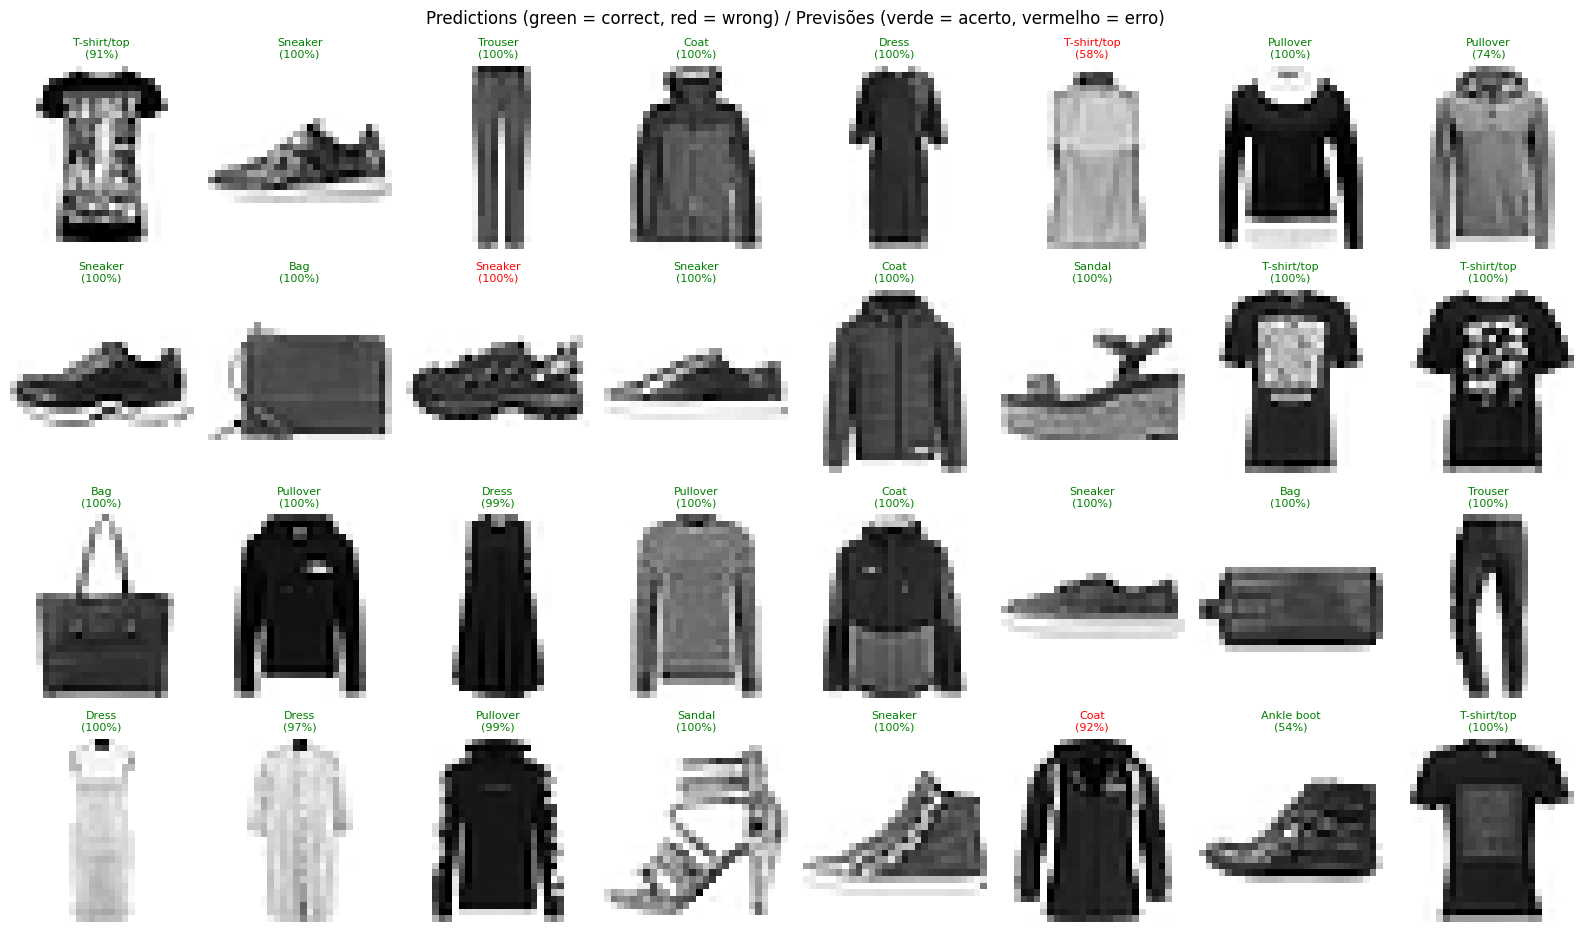

In [44]:
# grid of random predictions / grade de previsões aleatórias
n_rows, n_cols = 4, 8
sample_idx = rng.choice(len(X_test), n_rows * n_cols, replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(X_test[idx].squeeze(), cmap="gray_r")
    correct = y_pred[idx] == y_test[idx]
    ax.set_title(
        f"{class_names[y_pred[idx]]}\n({y_conf[idx]:.0%})",
        fontsize=8,
        color="green" if correct else "red",
    )
    ax.axis("off")

plt.suptitle("Predictions (green = correct, red = wrong) / Previsões (verde = acerto, vermelho = erro)")
plt.tight_layout()
plt.show()

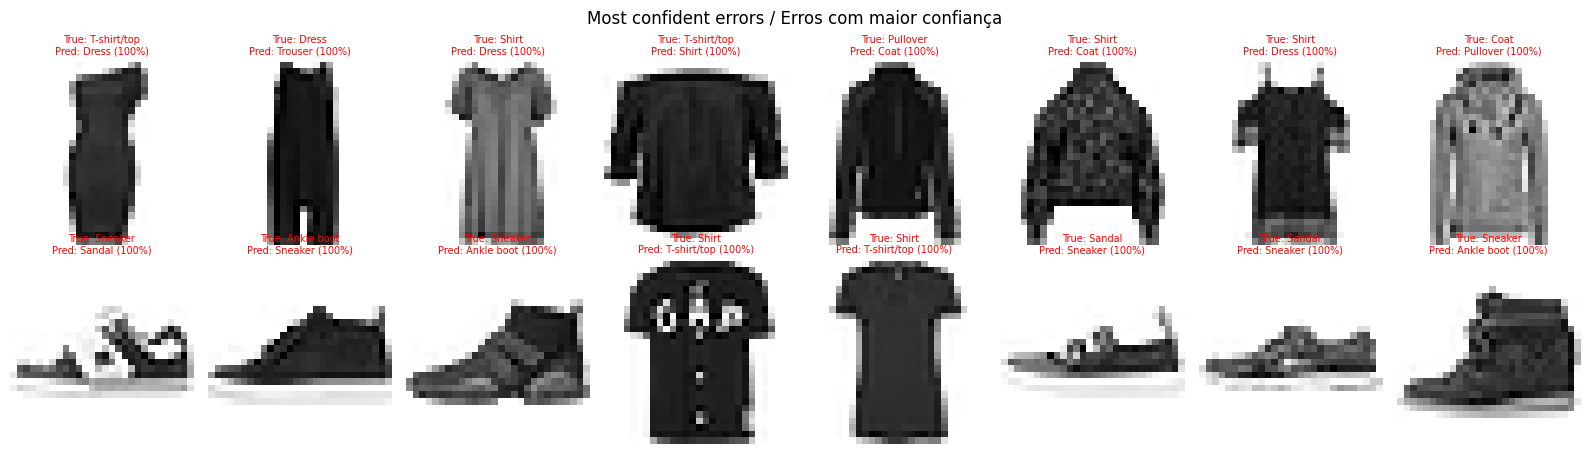

In [45]:
# most confident errors / erros com maior confiança
wrong_idx = np.where(y_pred != y_test)[0]
worst_idx = wrong_idx[np.argsort(y_conf[wrong_idx])[::-1][:16]]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for ax, idx in zip(axes.ravel(), worst_idx):
    ax.imshow(X_test[idx].squeeze(), cmap="gray_r")
    ax.set_title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]} ({y_conf[idx]:.0%})",
        fontsize=7,
        color="red",
    )
    ax.axis("off")

plt.suptitle("Most confident errors / Erros com maior confiança")
plt.tight_layout()
plt.show()

### Prediction Grid Analysis (Baseline CNN)

The grid shows 32 random test images (4 rows x 8 columns). Each title gives the **predicted class and its confidence** (maximum softmax probability). Green means correct and red means wrong. The title does not show the true label, so the "likely true class" comments below are visual hypotheses and should be checked against `y_test`.

#### 1. Formulas

Predicted class and confidence for image $x$:

$$\hat{c}(x) = \arg\max_c \hat{y}_c(x), \qquad conf(x) = \max_c \hat{y}_c(x)$$

Accuracy on the sample and its uncertainty:

$$Acc_{sample} = \frac{28}{32} = 0.875, \qquad SE = \sqrt{\frac{0.875 \cdot 0.125}{32}} \approx 0.058$$

$$IC_{95\%} \approx 0.875 \pm 1.96 \cdot 0.058 = [0.76,\ 0.99]$$

#### 2. Result on the sample

| Item | Value |
|---|---|
| Images | 32 |
| Correct (green) | 28 |
| Wrong (red) | 4 (12.5%) |
| Test error rate of the model | 6.4% |

The sample error rate is about twice the test error rate, but this is not unusual. With $p = 0.064$ and $n = 32$, the expected number of errors is $np = 2.05$, and the probability of seeing 4 or more is

$$P(X \ge 4) = 1 - \sum_{k=0}^{3} \binom{32}{k} 0.064^k \, 0.936^{32-k} \approx 0.15$$

So 4 errors happen in about 1 of 7 random grids. The true test accuracy (0.936) lies inside the interval of this sample, so the grid is consistent with the numeric results.

#### 3. The four errors

| Position | Predicted | Confidence | Visual observation (likely true class) |
|---|---|---|---|
| Row 1, col 6 | T-shirt/top | 73% | Light sleeveless top. Likely Shirt or Dress |
| Row 1, col 8 | Coat | 72% | Gray hooded jacket. Likely Pullover or Shirt |
| Row 2, col 3 | Sneaker | 99% | Chunky dark shoe with a high profile. Likely Ankle boot |
| Row 4, col 6 | Coat | 99% | Dark hooded zip item. Likely Pullover |

- **Three of the four errors are in the upper-body group** (T-shirt/top, Pullover, Coat, Shirt), and the fourth is the Sneaker / Ankle boot pair. These are the same confusion pairs found in the confusion matrix (Pullover to Coat, Shirt to T-shirt/top, Ankle boot to Sneaker).
- The two Coat errors involve **hooded items**. A hood and a zipper are small details at 28x28, so a hoodie (Pullover) can look like a jacket (Coat). This agrees with the 57 Pullover to Coat errors in the matrix.
- **No image in the grid was predicted as Shirt.** The model predicts Shirt for 9.35% of the test set (935 of 10,000), so the chance of 0 Shirts in 32 images is $(1 - 0.0935)^{32} \approx 0.04$. This is a small sample and should not be over-read, but it fits the under-prediction of Shirt (recall 0.781) and suggests that Shirt-like items are being sent to T-shirt/top and Coat.

#### 4. Confidence analysis

- **Most correct predictions have confidence of 99% to 100%**: Trouser, Bag, Sandal, Dress, most Sneakers and most Coats. This is expected for classes with distinct shapes.
- **Low-confidence correct predictions:** Ankle boot (54%), Pullover (69%) and Pullover (91%). These are ambiguous but correct, and they show the model "hesitates" in the right places.
- **Errors split into two types:**
  - **Uncertain errors (72% to 73%):** the model is partially aware of the ambiguity.
  - **Confident errors (99%):** the model is wrong and sure. These are the most dangerous cases, because a confidence threshold will not catch them.

Mean confidence of the four errors:

$$\overline{conf}_{err} = \frac{0.73 + 0.72 + 0.99 + 0.99}{4} \approx 0.86$$

A well-calibrated model should have an average confidence close to its accuracy in each confidence bin. The calibration gap is measured by the expected calibration error:

$$ECE = \sum_{m=1}^{M} \frac{|B_m|}{N} \left| acc(B_m) - conf(B_m) \right|$$

where $B_m$ are confidence bins. In the highest bin (confidence at least 0.99), the grid shows 2 errors among roughly 20 images, so the real accuracy there (about 90%) is below the stated confidence (99%). This points to **overconfidence**, which is typical for networks trained with cross-entropy for many epochs without early stopping (the training ran 50 epochs and the final weights are from epoch 49). With only 32 images this is a hint, not a measurement.

#### 5. Effect of a confidence threshold (human review)

With a threshold $\tau = 0.80$, items with $conf < \tau$ go to human review:

| Group | Images | Errors inside |
|---|---|---|
| Below 0.80 (review) | 4 (73%, 72%, 69%, 54%) | 2 |
| At or above 0.80 (automatic) | 28 | 2 |

$$\text{review rate} = \frac{4}{32} = 12.5\%, \qquad \text{error capture} = \frac{2}{4} = 50\%$$

$$Acc_{automatic} = \frac{26}{28} = 0.929$$

- The threshold catches both uncertain errors, but not the two 99% errors.
- Half of the reviewed images were correct, so the review precision is 50%.
- The remaining automatic group has 92.9% accuracy, only slightly below the global 93.6%, so on this sample the threshold gives a small gain. A reliable threshold must be tuned on the full validation set, not on 32 images.

#### 6. Consistency with previous analyses

- **Confusion matrix:** the error types in the grid are the same as the main pairs in the matrix.
- **Classification report:** errors in upper-body classes and the absence of Shirt predictions agree with the low recall of Shirt (0.781).
- **ROC curves:** high AUC with confident errors means ranking is good, but the probabilities are not perfectly calibrated.

#### 7. Recommendations

- Use the "most confident errors" figure from the prediction cell to check whether the 99% errors are real model failures or ambiguous or wrong labels in the dataset.
- Show the **true label** in the title of the grid, so each red image can be checked directly: `True: ... | Pred: ...`.
- Retrain with `callbacks=callbacks` (early stopping at the best validation loss), which usually reduces overconfidence.
- Measure calibration on the full test set with ECE and a reliability diagram, and consider temperature scaling:

$$\hat{y}_c = \frac{e^{z_c / T}}{\sum_j e^{z_j / T}}, \quad T > 1 \text{ reduces confidence}$$

- In Section B, use the same `rng` seed 42 so the same 32 images are shown for every model, and compare which of these 4 errors each model fixes.

#### 8. Conclusion

The grid agrees with the numerical results: most images are classified correctly with very high confidence, and the errors fall in the known problem areas (hooded items among Pullover and Coat, Shirt-like items, and boots versus sneakers). The main finding is the presence of **confident errors (99%)**, which limits the effectiveness of a simple confidence threshold for human review and motivates a calibration check.

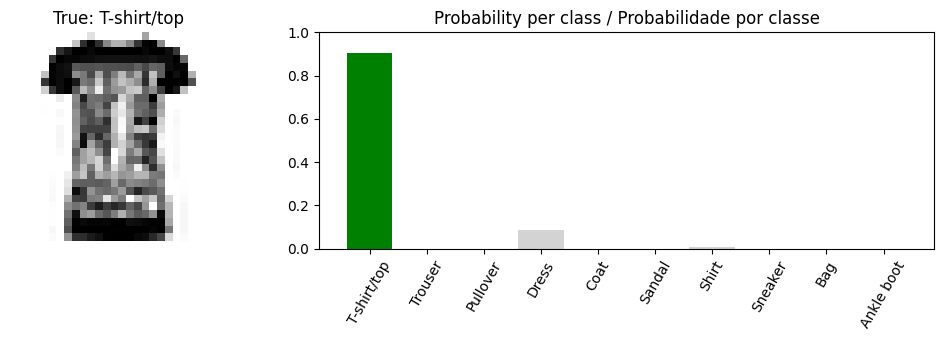

In [46]:
# probability per class for one image / probabilidade por classe de uma imagem
img_idx = int(sample_idx[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(X_test[img_idx].squeeze(), cmap="gray_r")
axes[0].set_title(f"True: {class_names[y_test[img_idx]]}")
axes[0].axis("off")

bar_colors = ["lightgray"] * 10
bar_colors[y_pred[img_idx]] = "green" if y_pred[img_idx] == y_test[img_idx] else "red"
axes[1].bar(class_names, y_prob[img_idx], color=bar_colors)
axes[1].set_title("Probability per class / Probabilidade por classe")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Single Image Probability Analysis (Baseline CNN)

The figure shows one test image (true class: **T-shirt/top**) and the softmax probability the baseline CNN assigns to each of the 10 classes. The green bar marks a correct prediction. The model assigns almost all the probability mass to T-shirt/top, and the other nine bars are visually zero.

#### 1. Formulas

The network outputs logits $z_c$, converted to probabilities by softmax:

$$\hat{y}_c = \frac{e^{z_c}}{\sum_{j=1}^{10} e^{z_j}}, \qquad \sum_{c=1}^{10} \hat{y}_c = 1$$

Predicted class and confidence:

$$\hat{c} = \arg\max_c \hat{y}_c, \qquad conf = \max_c \hat{y}_c$$

Loss for this single image (sparse categorical cross-entropy), where $y$ is the true class:

$$\mathcal{L} = -\log \hat{y}_{y}$$

- If $\hat{y}_{T\text{-}shirt/top} \approx 1$, then $\mathcal{L} \approx 0$. For example, at 0.99 the loss is $-\ln 0.99 \approx 0.010$.
- A random guess would give $\mathcal{L} = \ln 10 \approx 2.303$.

Entropy of the predicted distribution, which measures uncertainty:

$$H = -\sum_{c=1}^{10} \hat{y}_c \log \hat{y}_c$$

$H = 0$ means total certainty, and the maximum is $\ln 10 \approx 2.303$ (uniform distribution). Here $H$ is close to 0.

#### 2. Reading the chart

| Item | Observation |
|---|---|
| True class | T-shirt/top |
| Predicted class | T-shirt/top (correct) |
| Confidence | about 1.0 (visually 99% to 100%) |
| Other classes | Dress and Shirt show a barely visible bar, the rest are zero |

- **Dress and Shirt** are the only classes with a visible trace, and they are the natural neighbors of T-shirt/top: a similar torso and short sleeves (Shirt) and a vertical garment shape (Dress). This agrees with the confusion matrix, where T-shirt/top is confused with Shirt (63 images) and Dress (16 images) and with Pullover (16 images).
- The values are read from the chart. For the exact numbers, print `y_prob[img_idx]`.

#### 3. Why the model is so confident

- The image is a **typical T-shirt/top**: short sleeves, a round neckline, a rectangular torso and a straight hem, with a clear, centered silhouette. It has a high-contrast print, but the shape is unambiguous.
- The print creates a textured interior, which is not a problem because the convolutional filters rely on the outline (sleeves and neckline) more than on the pixel intensities inside.
- This is a case far from the decision boundary with the Shirt class, which usually has collars, buttons or long sleeves.

#### 4. Confidence is not correctness

A confidence of about 100% for one image does not prove the model is reliable. Two points from the previous analyses:

- The model makes **confident errors**: in the prediction grid, two wrong predictions had 99% confidence.
- Calibration is measured over many images, with the expected calibration error:

$$ECE = \sum_{m=1}^{M} \frac{|B_m|}{N} \left| acc(B_m) - conf(B_m) \right|$$

So this chart is a good example of a **correct and certain** case, but not evidence of calibration. A single image is an anecdote, not a metric.

#### 5. Useful checks

- Print the exact probabilities and the entropy for this image:

```python
"""Exact probabilities and entropy for one test image."""

import numpy as np

# probabilities of the selected image / probabilidades da imagem selecionada
probs = y_prob[img_idx]
for name, p in zip(class_names, probs):
    print(f"{name}: {p:.6f}")

# predictive entropy / entropia preditiva
entropy = -np.sum(probs * np.log(probs + 1e-12))
print(f"Entropy: {entropy:.4f} (max = {np.log(10):.4f})")
```

- Repeat the plot for **hard cases**, such as a Shirt predicted as T-shirt/top, to see a distribution split between two classes. In those cases two bars are tall, and the entropy is high, which is where a human-review rule is useful.

#### 6. Conclusion

For this image, the baseline CNN is correct and almost fully certain, with a near-zero loss and entropy. The small residual probability in Dress and Shirt reflects the similarity between those classes and T-shirt/top. To judge the model, combine this view with the confusion matrix, the classification report and a calibration analysis over the whole test set.

In [47]:
# total errors / total de erros
print(f"Errors: {len(wrong_idx)} of {len(y_test)} ({len(wrong_idx) / len(y_test):.2%})")

Errors: 579 of 10000 (5.79%)


# Part 8 - Save model

In [50]:
"""Recover the baseline CNN after a Colab session reset.

Recreates the output folder, mounts Google Drive, reloads the saved baseline
model, rebuilds the test data, recomputes the metrics and saves them again.
"""

import json
import os

import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.metrics import accuracy_score, f1_score
from tensorflow import keras

# recreate the output folder / recriar a pasta de saída
os.makedirs(save_dir, exist_ok=True)

# mount Google Drive / montar o Google Drive
drive_dir = r"fashion_mnist_models"

In [54]:
# rebuild the test data if it is missing / recriar os dados de teste se estiverem ausentes
if "X_test" not in globals():
    import kagglehub
    from google.colab import userdata

    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    dataset_path = kagglehub.dataset_download("zalando-research/fashionmnist")
    df_test = pd.read_csv(os.path.join(dataset_path, "fashion-mnist_test.csv"))
    y_test = df_test["label"].values
    X_test = df_test.drop(columns="label").values.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# metrics / métricas
y_prob = cnn_model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
cnn_accuracy = accuracy_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy: {cnn_accuracy:.4f} | macro F1: {cnn_f1:.4f}")

Test accuracy: 0.9421 | macro F1: 0.9419


In [55]:
# results dictionary, training time unknown / dicionário de resultados, tempo de treino desconhecido
results = {
    "CNN baseline": {
        "accuracy": float(cnn_accuracy),
        "macro_f1": float(cnn_f1),
        "train_time_s": None,
        "params": int(cnn_model.count_params()),
    }
}

# save the metrics / salvar as métricas
metrics_path = os.path.join(save_dir, "cnn_baseline_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2, default=float)
print("Metrics saved:", metrics_path)

Metrics saved: /content/models/cnn_baseline_metrics.json


# Section B) Transfer Learning

# Part 9 - Models Transfer Learning

Four ImageNet pre-trained CNNs (MobileNetV2, VGG16, ResNet50, EfficientNetB0)
are adapted to Fashion MNIST in two phases: feature extraction with the
backbone frozen, then fine-tuning of the top layers with a low learning rate.
Results are added to the same `results` dictionary used by the baseline CNN.

In [56]:
# reproducibility / reprodutibilidade
keras.utils.set_random_seed(42)

# input size expected by the backbones / tamanho de entrada esperado pelos modelos
img_size = 96

# training settings / configurações de treinamento
epochs_frozen = 8
epochs_finetune = 5
n_unfreeze = 30
batch_size = 128

In [57]:
# backbones and their preprocessing / modelos e seus pré-processamentos
tl_configs = {
    "MobileNetV2": {"builder": keras.applications.MobileNetV2, "prep": "minus1_1"},
    "VGG16": {"builder": keras.applications.VGG16, "prep": "caffe"},
    "VGG19": {"builder": keras.applications.VGG19, "prep": "caffe"},
    "ResNet50": {"builder": keras.applications.ResNet50, "prep": "caffe"},
    "EfficientNetB0": {"builder": keras.applications.EfficientNetB0, "prep": "raw255"},
}

# dictionaries to keep the models and backbones / dicionários para guardar modelos e backbones
tl_models = {}
tl_bases = {}

for model_name, cfg in tl_configs.items():
    # pre-trained backbone without the classifier / modelo pré-treinado sem classificador
    base_model = cfg["builder"](
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling="avg",
    )
    base_model.trainable = False

    # input, resize and grayscale to RGB / entrada, redimensionar e converter para RGB
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Resizing(img_size, img_size)(inputs)
    x = layers.Concatenate()([x, x, x])

    # preprocessing of each backbone, input comes in [0, 1] / pré-processamento de cada modelo, entrada em [0, 1]
    if cfg["prep"] == "minus1_1":
        x = layers.Rescaling(scale=2.0, offset=-1.0)(x)
    elif cfg["prep"] == "caffe":
        x = layers.Rescaling(scale=255.0)(x)
        x = layers.Normalization(
            mean=[103.939, 116.779, 123.68], variance=[1.0, 1.0, 1.0]
        )(x)
    else:
        x = layers.Rescaling(scale=255.0)(x)

    # backbone in inference mode for BatchNormalization / modelo base em modo de inferência para BatchNormalization
    x = base_model(x, training=False)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    # final model / modelo final
    tl_models[model_name] = keras.Model(inputs, outputs, name=model_name.lower())
    tl_bases[model_name] = base_model

    # model summary / resumo do modelo
    print("Summary / Resumo:", model_name)
    tl_models[model_name].summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Summary / Resumo: MobileNetV2


Model: "mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 96, 96, 1) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96, 96, 3) │          0 │ resizing[0][0],   │
│ (Concatenate)       │                   │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ concatenate[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 1280)      │  2,257,984 │ rescaling[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │     12,810 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

...

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 96, 96, 1) │          0 │ input_layer_10[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 96, 96, 3) │          0 │ resizing_4[0][0], │
│ (Concatenate)       │                   │            │ resizing_4[0][0], │
│                     │                   │            │ resizing_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 96, 96, 3) │          0 │ concatenate_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ rescaling_6[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1280)      │          0 │ efficientnetb0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │     12,810 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Transfer Learning Summaries Analysis (Section B)

The five `summary` outputs confirm the expected counts: every number printed by Keras matches the formulas below. In phase 1 the backbone is frozen, so only the `Dense` head trains (0.03% to 0.56% of each model).

#### 1. Parameter counts verified

Head (Dense layer on the pooled features of dimension $d$):

$$P_{head} = (d + 1) \cdot 10$$

| Model | $d$ | Calculation | Head params | Backbone params | Total |
|---|---|---|---|---|---|
| MobileNetV2 | 1,280 | $(1280+1) \cdot 10$ | 12,810 | 2,257,984 | 2,270,794 |
| VGG16 | 512 | $(512+1) \cdot 10$ | 5,130 | 14,714,688 | 14,719,818 |
| VGG19 | 512 | $(512+1) \cdot 10$ | 5,130 | 20,024,384 | 20,029,514 |
| ResNet50 | 2,048 | $(2048+1) \cdot 10$ | 20,490 | 23,587,712 | 23,608,202 |
| EfficientNetB0 | 1,280 | $(1280+1) \cdot 10$ | 12,810 | 4,049,571 | 4,062,381 |

Trainable share in phase 1:

$$\text{share} = \frac{P_{head}}{P_{total}}: \quad 0.564\%,\; 0.035\%,\; 0.026\%,\; 0.087\%,\; 0.315\%$$

Memory in float32: $P \cdot 4$ bytes. MobileNetV2 8.66 MB, EfficientNetB0 15.50 MB, VGG16 56.15 MB, VGG19 76.41 MB, ResNet50 90.06 MB (MiB, as Keras reports). The baseline CNN has 288,618 parameters (1.10 MB), so the backbones are:

$$\frac{2{,}270{,}794}{288{,}618} \approx 7.9\times \;\;\text{to}\;\; \frac{23{,}608{,}202}{288{,}618} \approx 81.8\times$$

Parameters per training image ($P / 48{,}000$): MobileNetV2 47, EfficientNetB0 85, VGG16 307, VGG19 417, ResNet50 492, against 6 for the baseline.

#### 2. Input pipeline (all models)

$$(28,28,1) \xrightarrow{\text{Resizing}} (96,96,1) \xrightarrow{\text{Concat}\times3} (96,96,3)$$

- Values per image: $784 \to 96 \cdot 96 \cdot 3 = 27{,}648$ (35.3 times more), with no new information, only interpolation.
- The `Concatenate` lines show `resizing[0][0]` three times: the same grayscale channel feeds R, G and B. The first backbone convolution therefore sees $(w_R + w_G + w_B) \star u$, so ImageNet color sensitivity is lost.
- The first Keras download line for MobileNetV2 shows weights `..._1.0_96_no_top.h5`, so Keras selected the variant trained for **96x96** inputs. This is good for MobileNetV2 at this resolution.

#### 3. Preprocessing differences visible in the summaries

| Model | Layers before the backbone | Formula | Range |
|---|---|---|---|
| MobileNetV2 | `rescaling` | $2x - 1$ | $[-1, 1]$ |
| VGG16, VGG19, ResNet50 | `rescaling`, `normalization` | $255x - m_c$ | about $[-124, 151]$ |
| EfficientNetB0 | `rescaling_6` | $255x$ | $[0, 255]$ |

EfficientNetB0 has no `normalization` layer because the backbone normalizes internally. The layer index `rescaling_6` (instead of `rescaling_4`) is only a naming counter: Keras counts the `Rescaling` layers created inside the EfficientNet backbone. It does not indicate a different layer.

#### 4. Feature dimension and spatial reduction

All five backbones reduce resolution by 32, so the last map is

$$\frac{96}{32} = 3 \times 3$$

and global average pooling gives $h_k = \frac{1}{9}\sum_{i,j} f_k(i,j)$. Each feature averages only 9 positions, compared with 49 at 224x224.

Compression from the last map to the head input:

| Model | Map size | GAP output $d$ |
|---|---|---|
| MobileNetV2, EfficientNetB0 | $3\times3\times1280$ (11,520 values) | 1,280 |
| ResNet50 | $3\times3\times2048$ (18,432 values) | 2,048 |
| VGG16, VGG19 | $3\times3\times512$ (4,608 values) | 512 |

VGG has the smallest feature vector (512), which limits what the linear head can use in phase 1.

#### 5. Computational cost

Approximate MACs at 96x96 (224x224 cost times $(96/224)^2 \approx 0.184$), against the baseline CNN (about 22 M MACs):

| Model | MACs at 96x96 | vs baseline |
|---|---|---|
| MobileNetV2 | about 0.055 G | 2.5x |
| EfficientNetB0 | about 0.07 G | 3x |
| ResNet50 | about 0.7 G | 32x |
| VGG16 | about 2.8 G | 127x |
| VGG19 | about 3.6 G | 164x |

These are estimates, not values from the summaries. VGG is the most expensive and has the lowest parameter efficiency.

#### 6. Phase 1 as logistic regression

With the backbone fixed ($\varphi(x)$ in the first stage):

$$p(c \mid x) = \text{softmax}(W \varphi(x) + b)_c, \qquad W \in \mathbb{R}^{10 \times d}$$

The loss is convex in $(W, b)$, apart from dropout noise. The ceiling of this phase depends on how linearly separable the ImageNet features are for Fashion MNIST. Features of 512 (VGG) versus 2,048 (ResNet50) dimensions give different capacity to this linear classifier.

#### 7. Risks and observations

- **Domain gap:** ImageNet features come from color, high-resolution photos. The input here is smooth, grayscale and upscaled 3.43 times.
- **Frozen BatchNorm** (MobileNetV2, ResNet50, EfficientNetB0) uses ImageNet statistics $(\mu, \sigma^2)$ with the fixed transform $y = \gamma \frac{x-\mu}{\sqrt{\sigma^2+\epsilon}} + \beta$. VGG has no BN, so it avoids this mismatch.
- **EfficientNetB0** was designed for 224x224, and 96x96 is far from its design point.
- **Dense head only:** the head is a single linear layer, so phase 1 results should be below the baseline CNN. The gains, if any, appear in phase 2.
- **Fine-tuning depth by layers, not parameters.** `n_unfreeze` counts layers, so the released share of parameters varies widely. For VGG16 with 4 and VGG19 with 5, the list includes the pooling layer, so only the last 2 or 3 convolutions are really released. Run the check cell from the previous answer to see the percentage for each backbone before training.

#### 8. Conclusions

- All parameter counts match the formulas. The architecture is correctly built with preprocessing inside each model.
- The backbones are 8 to 82 times larger than the baseline CNN, and VGG19 is also about 164 times more expensive in compute.
- The success criterion remains: macro F1 above **0.9357** with a margin of at least 0.005, and gains in Shirt, T-shirt/top, Pullover and Coat.
- Hypothesis for the results: MobileNetV2 and EfficientNetB0 give the best performance per cost, while the baseline CNN may remain competitive because of the domain gap.

In [58]:
# models to train, remove names to skip / modelos para treinar, remova nomes para pular
models_to_train = ["MobileNetV2", "VGG16", "VGG19", "ResNet50", "EfficientNetB0"]

# training settings / configurações de treinamento
epochs_frozen = 8
epochs_finetune = 5
batch_size = 128

# layers to unfreeze per backbone / camadas liberadas por modelo no fine-tuning
n_unfreeze = {"MobileNetV2": 30,
              "VGG16": 4,
              "VGG19": 5,
              "ResNet50": 30,
              "EfficientNetB0": 30,
              }

# keep the baseline results if they exist / manter resultados do baseline se existirem
results = globals().get("results", {})

# folder for the trained models / pasta dos modelos treinados
save_dir = r"/content/models"
os.makedirs(save_dir, exist_ok=True)

# histories and predictions per model / históricos e previsões por modelo
tl_histories = {}
tl_predictions = {}

#
for model_name in models_to_train:
    print("Training / Treinando:", model_name)

    #
    tl_model = tl_models[model_name]
    base_model = tl_bases[model_name]

    # callbacks created per model / callbacks criados para cada modelo
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
                 keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
                 ]

    # phase 1: feature extraction with frozen backbone / fase 1: extração de características com base congelada
    base_model.trainable = False
    tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),loss="sparse_categorical_crossentropy",metrics=["accuracy"],
                     )

    #
    start_time = time.time()

    #
    hist_frozen = tl_model.fit(X_train, y_train,
                               validation_data=(X_val, y_val),
                               epochs=epochs_frozen,
                               batch_size=batch_size,
                               verbose=1,
                               )

    # phase 2: unfreeze the last layers, BatchNormalization stays frozen / fase 2: liberar as últimas camadas, BatchNormalization continua congelada
    base_model.trainable = True
    for layer in base_model.layers[:-n_unfreeze[model_name]]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # recompile is required after changing trainable / recompilar é obrigatório após mudar trainable
    tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),loss="sparse_categorical_crossentropy",metrics=["accuracy"],
                     )

    #
    hist_finetune = tl_model.fit(X_train, y_train,
                                 validation_data=(X_val, y_val),
                                 epochs=epochs_finetune,
                                 batch_size=batch_size,
                                 verbose=1,
                                 )

    #
    train_time = time.time() - start_time

    # evaluation on the test set / avaliação no conjunto de teste
    y_prob = tl_model.predict(X_test, batch_size=256, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"{model_name} | accuracy: {acc:.4f} | macro F1: {f1:.4f} | time: {train_time:.1f}s")

    # store results, histories and predictions / guardar resultados, históricos e previsões
    results[model_name] = {"accuracy": float(acc),
                           "macro_f1": float(f1),
                           "train_time_s": float(train_time),
                           "params": int(tl_model.count_params()),
                           }

    #
    tl_histories[model_name] = {"frozen": hist_frozen.history,
                                "finetune": hist_finetune.history,
                                }

    #
    tl_predictions[model_name] = y_prob

    # save the trained model / salvar o modelo treinado
    tl_model.save(os.path.join(save_dir, f"{model_name.lower()}_fashion_mnist.keras"))

# comparison table / tabela comparativa
comparison_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
print(comparison_df)

Training / Treinando: MobileNetV2
Epoch 1/8


2026-10-03 21:04:59.769190: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:04:59.920808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:05:00.060497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6992 - loss: 0.8722

2026-10-03 21:05:24.510754: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:05:24.648829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8013 - loss: 0.5615 - val_accuracy: 0.8701 - val_loss: 0.3518
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8680 - loss: 0.3684 - val_accuracy: 0.8829 - val_loss: 0.3219
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8778 - loss: 0.3372 - val_accuracy: 0.8852 - val_loss: 0.3116
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8816 - loss: 0.3251 - val_accuracy: 0.8857 - val_loss: 0.3110
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8841 - loss: 0.3170 - val_accuracy: 0.8895 - val_loss: 0.2977
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8871 - loss: 0.3091 - val_accuracy: 0.8883 - val_loss: 0.3002
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8866 - loss: 0.3072 - val_accuracy: 0.8895 - val_loss: 0.3001
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8891 - loss: 0.3034 - val_accuracy: 0.8885 -

...

374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7045 - loss: 0.8926

2026-10-03 21:54:07.215919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:54:07.352493: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:54:07.690393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:54:07.832546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:54:08.624313: E external/local_xla/xla/stream_

375/375 ━━━━━━━━━━━━━━━━━━━━ 48s 71ms/step - accuracy: 0.8015 - loss: 0.5888 - val_accuracy: 0.8654 - val_loss: 0.3699
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8597 - loss: 0.3912 - val_accuracy: 0.8794 - val_loss: 0.3300
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8687 - loss: 0.3616 - val_accuracy: 0.8848 - val_loss: 0.3148
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8748 - loss: 0.3466 - val_accuracy: 0.8863 - val_loss: 0.3055
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8773 - loss: 0.3403 - val_accuracy: 0.8905 - val_loss: 0.2977
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8794 - loss: 0.3354 - val_accuracy: 0.8923 - val_loss: 0.2957
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8803 - loss: 0.3275 - val_accuracy: 0.8945 - val_loss: 0.2907
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8824 - loss: 0.3231 - val_accuracy: 0.89

2026-10-03 21:57:24.347683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:57:24.498093: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:57:24.902530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:57:25.053597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 21:57:25.868282: E external/local_xla/xla/stream_

EfficientNetB0 | accuracy: 0.9080 | macro F1: 0.9078 | time: 235.3s
                accuracy  macro_f1  train_time_s      params
CNN baseline      0.9421  0.941936           NaN    288618.0
VGG19             0.9238  0.923258   1190.874535  20029514.0
VGG16             0.9226  0.922037    956.495372  14719818.0
ResNet50          0.9205  0.919912    492.242052  23608202.0
MobileNetV2       0.9165  0.916253    185.150327   2270794.0
EfficientNetB0    0.9080  0.907771    235.320626   4062381.0


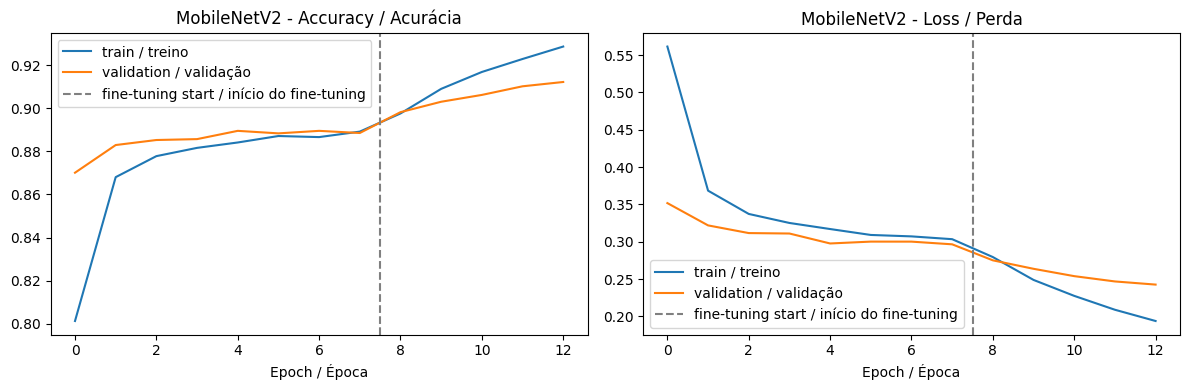

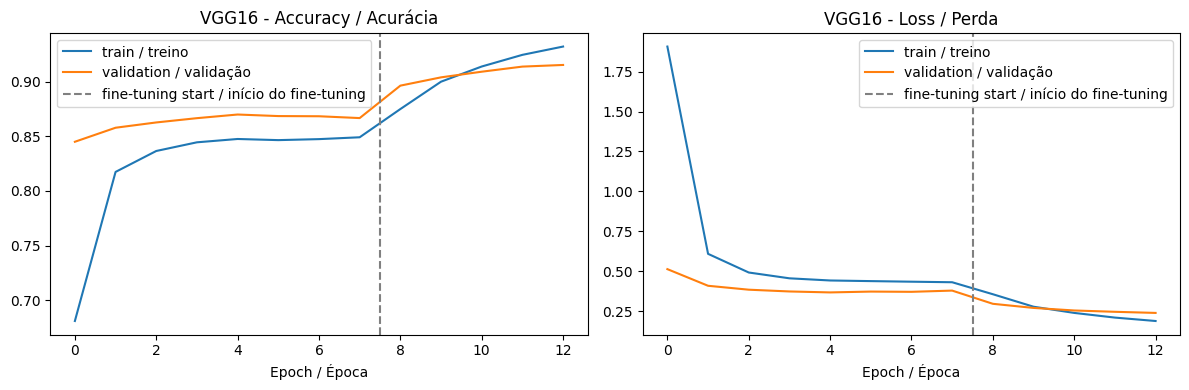

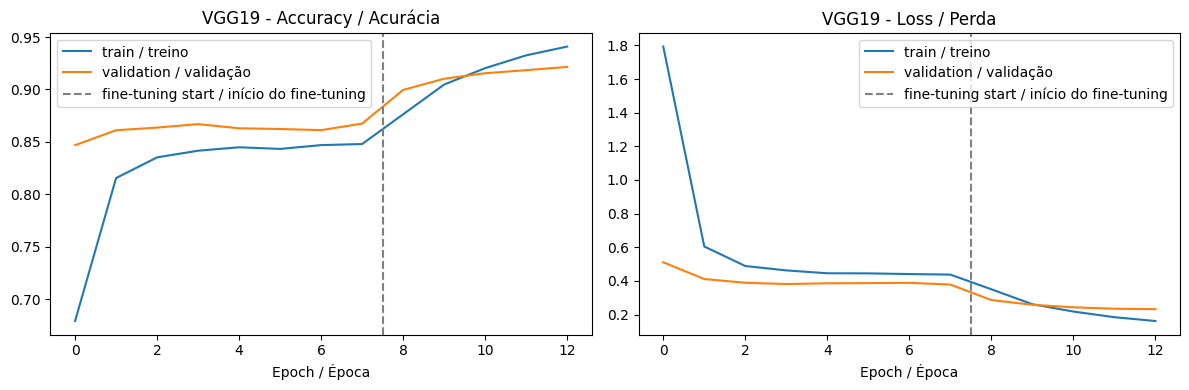

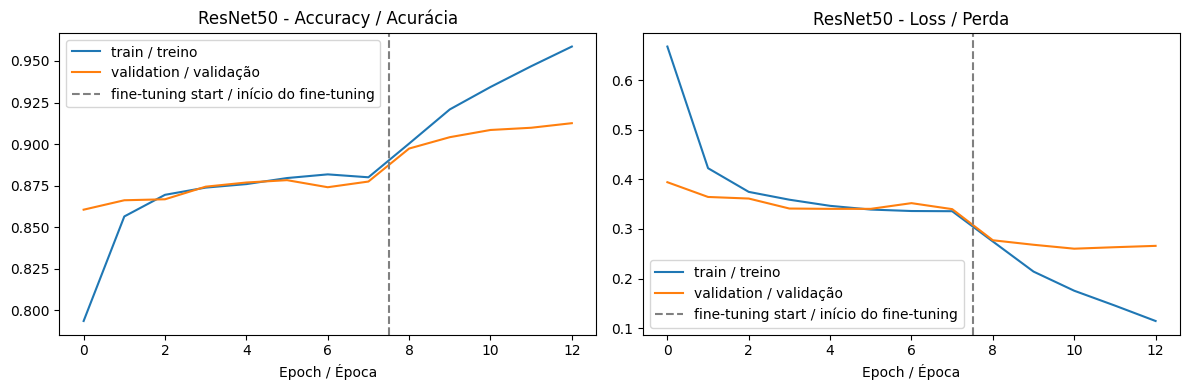

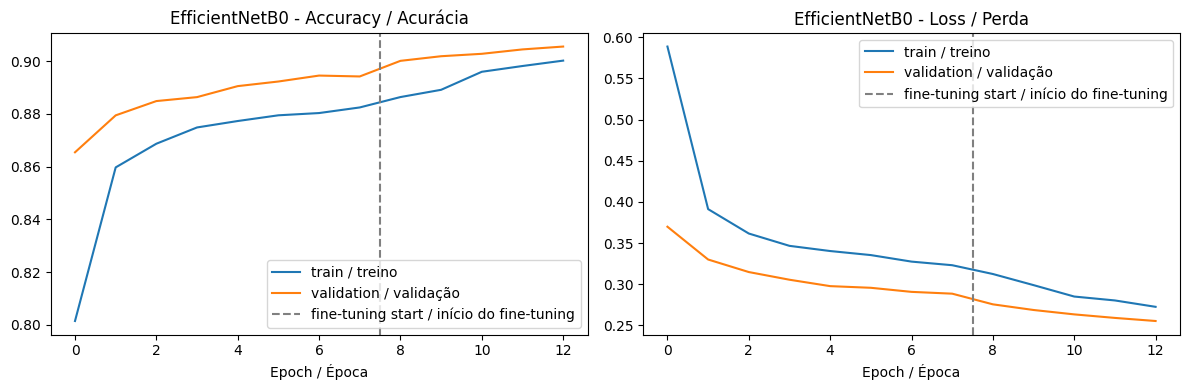

In [59]:
"""Performance plots for the transfer learning models (Section B).

Plots accuracy and loss per epoch for each model, joining the frozen backbone
phase and the fine-tuning phase, and then compares test accuracy, macro
F1-score, training time and parameters across all models.
"""

# learning curves per model / curvas de aprendizado por modelo
for model_name, hist in tl_histories.items():
    # join frozen and fine-tuning phases / juntar fase congelada e fine-tuning
    acc = hist["frozen"]["accuracy"] + hist["finetune"]["accuracy"]
    val_acc = hist["frozen"]["val_accuracy"] + hist["finetune"]["val_accuracy"]
    loss = hist["frozen"]["loss"] + hist["finetune"]["loss"]
    val_loss = hist["frozen"]["val_loss"] + hist["finetune"]["val_loss"]

    # epoch where fine-tuning starts / época em que o fine-tuning começa
    ft_start = len(hist["frozen"]["accuracy"]) - 0.5

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(acc, label="train / treino")
    axes[0].plot(val_acc, label="validation / validação")
    axes[0].axvline(ft_start, color="gray", linestyle="--", label="fine-tuning start / início do fine-tuning")
    axes[0].set_title(f"{model_name} - Accuracy / Acurácia")
    axes[0].set_xlabel("Epoch / Época")
    axes[0].legend()

    axes[1].plot(loss, label="train / treino")
    axes[1].plot(val_loss, label="validation / validação")
    axes[1].axvline(ft_start, color="gray", linestyle="--", label="fine-tuning start / início do fine-tuning")
    axes[1].set_title(f"{model_name} - Loss / Perda")
    axes[1].set_xlabel("Epoch / Época")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### VGG19 Training Curves Analysis (Section B)

The chart shows 13 epochs (0 to 12): **8 epochs with the backbone frozen** (0 to 7) and **5 epochs of fine-tuning** (8 to 12). The dashed line at 7.5 marks the start of phase 2, where the last layers are released and the learning rate drops from $10^{-3}$ to $10^{-5}$. Neither phase was stopped early, since the run used all 8 + 5 epochs.

#### 1. Values read from the chart (approximate)

| Metric | Epoch 0 | Epoch 7 (end of phase 1) | Epoch 12 (final) |
|---|---|---|---|
| Train accuracy | 0.68 | 0.85 | 0.94 |
| Validation accuracy | 0.847 | 0.868 | 0.921 |
| Train loss | 1.79 | 0.44 | 0.16 |
| Validation loss | 0.51 | 0.38 | 0.235 |

Values are visual estimates. Confirm them with `tl_histories["VGG19"]`.

#### 2. Steps and total updates

$$\text{steps per epoch} = \left\lceil \frac{48000}{128} \right\rceil = 375, \qquad \text{total updates} = 13 \cdot 375 = 4{,}875$$

Phase 1 used $8 \cdot 375 = 3{,}000$ updates and phase 2 used $5 \cdot 375 = 1{,}875$.

#### 3. Phase 1: frozen backbone (epochs 0 to 7)

With a fixed backbone $\varphi(x)$, the model is a softmax regression on 512 features:

$$p(c \mid x) = \text{softmax}(W\varphi(x) + b)_c, \qquad W \in \mathbb{R}^{10 \times 512}$$

- **Fast start, then a plateau.** Train accuracy rises from 0.68 to about 0.85 and flattens after epoch 3. Validation accuracy sits at 0.86 to 0.87 from epoch 1 on. This plateau is the **ceiling of a linear classifier on ImageNet features**, which is about 0.87.
- **Validation above training.** From epoch 0 to 7, validation accuracy is higher than training accuracy (about +0.02 at the end). Two causes: `Dropout(0.3)` is active only in training, and the training metric is averaged over the epoch while the weights are still improving. This is not a bug, and it is consistent with underfitting, not overfitting.
- **Loss in epoch 0.** Train loss starts at 1.79, well below the random reference but high for a convex problem. The head begins with random weights on features with large magnitude (caffe preprocessing, range up to about 150), so the first updates are large. Validation loss is computed at the end of the epoch, after the head already adapted, which is why it is much lower (0.51).

$$\mathcal{L}_{random} = \ln 10 \approx 2.303$$

#### 4. Phase 2: fine-tuning (epochs 8 to 12)

After the dashed line both curves change slope:

- **Train accuracy jumps from 0.85 to 0.94** in 5 epochs (+0.09), and train loss falls from 0.44 to 0.16 (-64%).
- **Validation accuracy rises from 0.868 to 0.921** (+0.053), and validation loss falls from 0.38 to 0.235 (-38%).
- The unfrozen layers (the last convolutional block of VGG19) now adapt the features to Fashion MNIST. This confirms that the domain gap exists and that fine-tuning removes part of it.

The generalization gap in accuracy and loss:

$$\text{gap}_{acc}^{(e)} = Acc_{train}^{(e)} - Acc_{val}^{(e)}, \qquad \text{gap}_{loss}^{(e)} = \mathcal{L}_{val}^{(e)} - \mathcal{L}_{train}^{(e)}$$

| Epoch | $\text{gap}_{acc}$ | $\text{gap}_{loss}$ |
|---|---|---|
| 7 | about -0.02 | about +0.06 |
| 9 | about 0 | about 0 |
| 12 | about +0.02 | about +0.07 |

The curves **cross at epoch 9**, and from epoch 10 the training curve is above validation. After epoch 10, the validation curve flattens (0.915, 0.919, 0.921) while train continues to improve, so the **gap starts to open**. It is still small (about 0.02 in accuracy), so there is no strong overfitting yet.

#### 5. Learning rate and size of the update

Adam moves each weight by at most about $\eta$ per update:

$$\Delta w_{max} \approx N_{updates} \cdot \eta$$

| Phase | $\eta$ | Updates | Max movement per weight |
|---|---|---|---|
| 1 | $10^{-3}$ | 3,000 | about 3.0 (head only) |
| 2 | $10^{-5}$ | 1,875 | about 0.019 |

The small learning rate of phase 2 changes the pre-trained weights gently, which is why the improvement is smooth with no spikes.

#### 6. The model is still improving

At epoch 12 the validation loss is still falling slowly and the training budget (`epochs_finetune = 5`) was fully used, so the final weights are **not at a plateau yet**. There is room for a longer fine-tuning. A simple extrapolation of the validation loss slope in the last 3 epochs ($\approx -0.005$ per epoch) suggests small gains remain, while the train/validation gap is starting to open.

#### 7. Comparison with the baseline CNN

| Metric | VGG19 (final, approx.) | Baseline CNN |
|---|---|---|
| Validation accuracy | 0.921 | about 0.935 |
| Validation loss | 0.235 | about 0.24 (epoch 49), 0.20 (best) |
| Train accuracy | 0.94 | 0.955 |
| Epochs | 13 | 50 |

- VGG19 is **about 1.4 points below the baseline** in validation accuracy, with a much larger model (20.0 M versus 0.29 M parameters).
- Its validation loss is similar to the final baseline loss, but accuracy is lower, which suggests the loss is less overconfident.
- A 1.4-point gap is larger than the noise of the validation set:

$$SE = \sqrt{\frac{0.93 \cdot 0.07}{12000}} \approx 0.0023$$

so the difference is statistically meaningful on validation. The final comparison must be done on the test set with the same metrics (accuracy, macro F1).

#### 8. Conclusions

- **Phase 1 is limited to about 0.87** because a linear head on frozen ImageNet features cannot adapt to blurry grayscale clothing.
- **Fine-tuning gives +5 points** in validation accuracy in only 1,875 updates, which is the main gain of transfer learning here.
- **No strong overfitting**, but the gap starts to open from epoch 10.
- **Still below the baseline CNN** (0.921 versus about 0.935). Under this configuration, the lightweight baseline remains the better choice.
- The domain gap (color, resolution, texture) explains why a generic backbone does not beat a small CNN trained from scratch on 28x28 images.

#### 9. Recommendations

- **Release more layers.** With `n_unfreeze = 5` for VGG19, the list includes the pooling layers, so only about 3 convolutions are really trained. Use 6 or 7 to release the whole last block (about 7 M parameters), or release the last two blocks.
- **Train longer in phase 2:** `epochs_finetune = 10` to 15 with `EarlyStopping` (`patience=3`) to let validation loss reach its plateau.
- **Use a slightly larger learning rate** in phase 2 (for example $3 \cdot 10^{-5}$ to $10^{-4}$), since $10^{-5}$ gives slow progress.
- **Check the test set** with the classification report and the confusion matrix, focusing on Shirt, T-shirt/top, Pullover and Coat.
- **Compare with the other backbones** (MobileNetV2, ResNet50, EfficientNetB0) before concluding that transfer learning does not help. VGG has no BatchNorm and only 512 features, so it may be the weakest of the five.

# Part 10 - Metrics and evaluations

In [60]:
"""Classification reports for the transfer learning models (Section B).

Loops over the predictions of each model and prints precision, recall,
F1-score and support per class, plus accuracy, macro average and weighted
average on the Fashion MNIST test set.
"""

# predictions per model, baseline included if it is loaded / previsões por modelo, com baseline se estiver carregado
all_predictions = {}
if "cnn_model" in globals():
    all_predictions["CNN baseline"] = cnn_model.predict(X_test, batch_size=256, verbose=0)
all_predictions.update(tl_predictions)

for model_name, y_prob in all_predictions.items():
    # predicted classes / classes previstas
    y_pred = np.argmax(y_prob, axis=1)

    # report per model / relatório por modelo
    print("Classification report / Relatório de classificação:", model_name)
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Classification report / Relatório de classificação: CNN baseline
              precision    recall  f1-score   support

 T-shirt/top     0.9010    0.9010    0.9010      1000
     Trouser     0.9950    0.9940    0.9945      1000
    Pullover     0.9216    0.9050    0.9132      1000
       Dress     0.9425    0.9500    0.9462      1000
        Coat     0.8922    0.9350    0.9131      1000
      Sandal     0.9949    0.9800    0.9874      1000
       Shirt     0.8420    0.8100    0.8257      1000
     Sneaker     0.9636    0.9790    0.9712      1000
         Bag     0.9930    0.9910    0.9920      1000
  Ankle boot     0.9741    0.9760    0.9750      1000

    accuracy                         0.9421     10000
   macro avg     0.9420    0.9421    0.9419     10000
weighted avg     0.9420    0.9421    0.9419     10000

Classification report / Relatório de classificação: MobileNetV2
              precision    recall  f1-score   support

 T-shirt/top     0.8700    0.8770    0.8735      1000
   

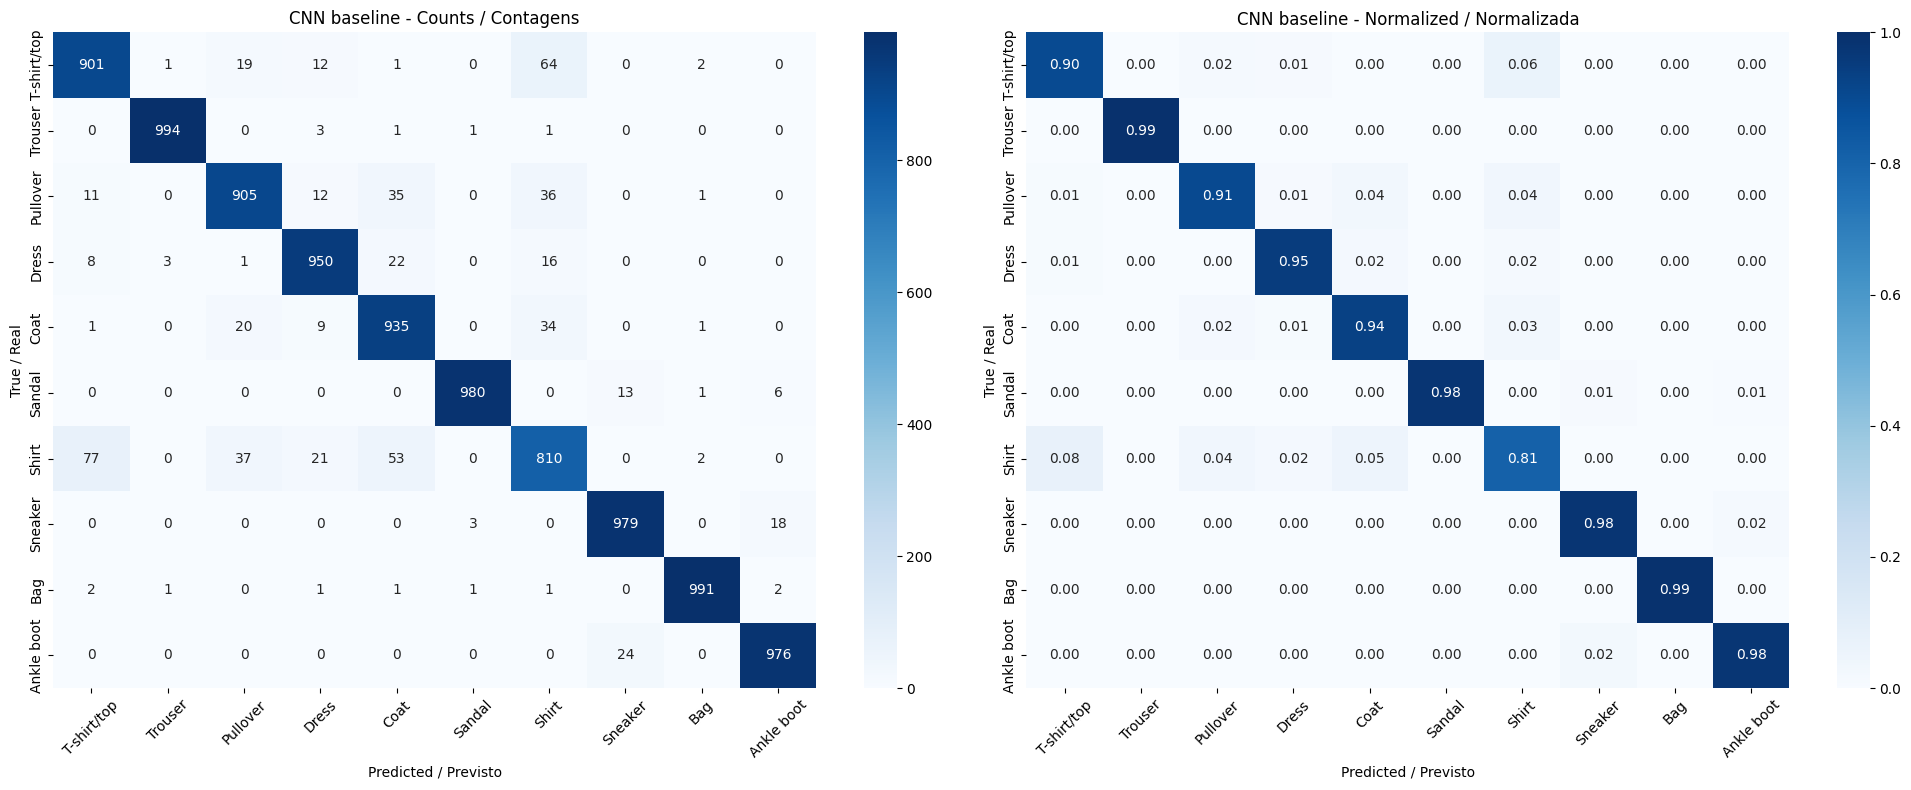

CNN baseline: Shirt -> T-shirt/top: 77 errors
CNN baseline: T-shirt/top -> Shirt: 64 errors
CNN baseline: Shirt -> Coat: 53 errors


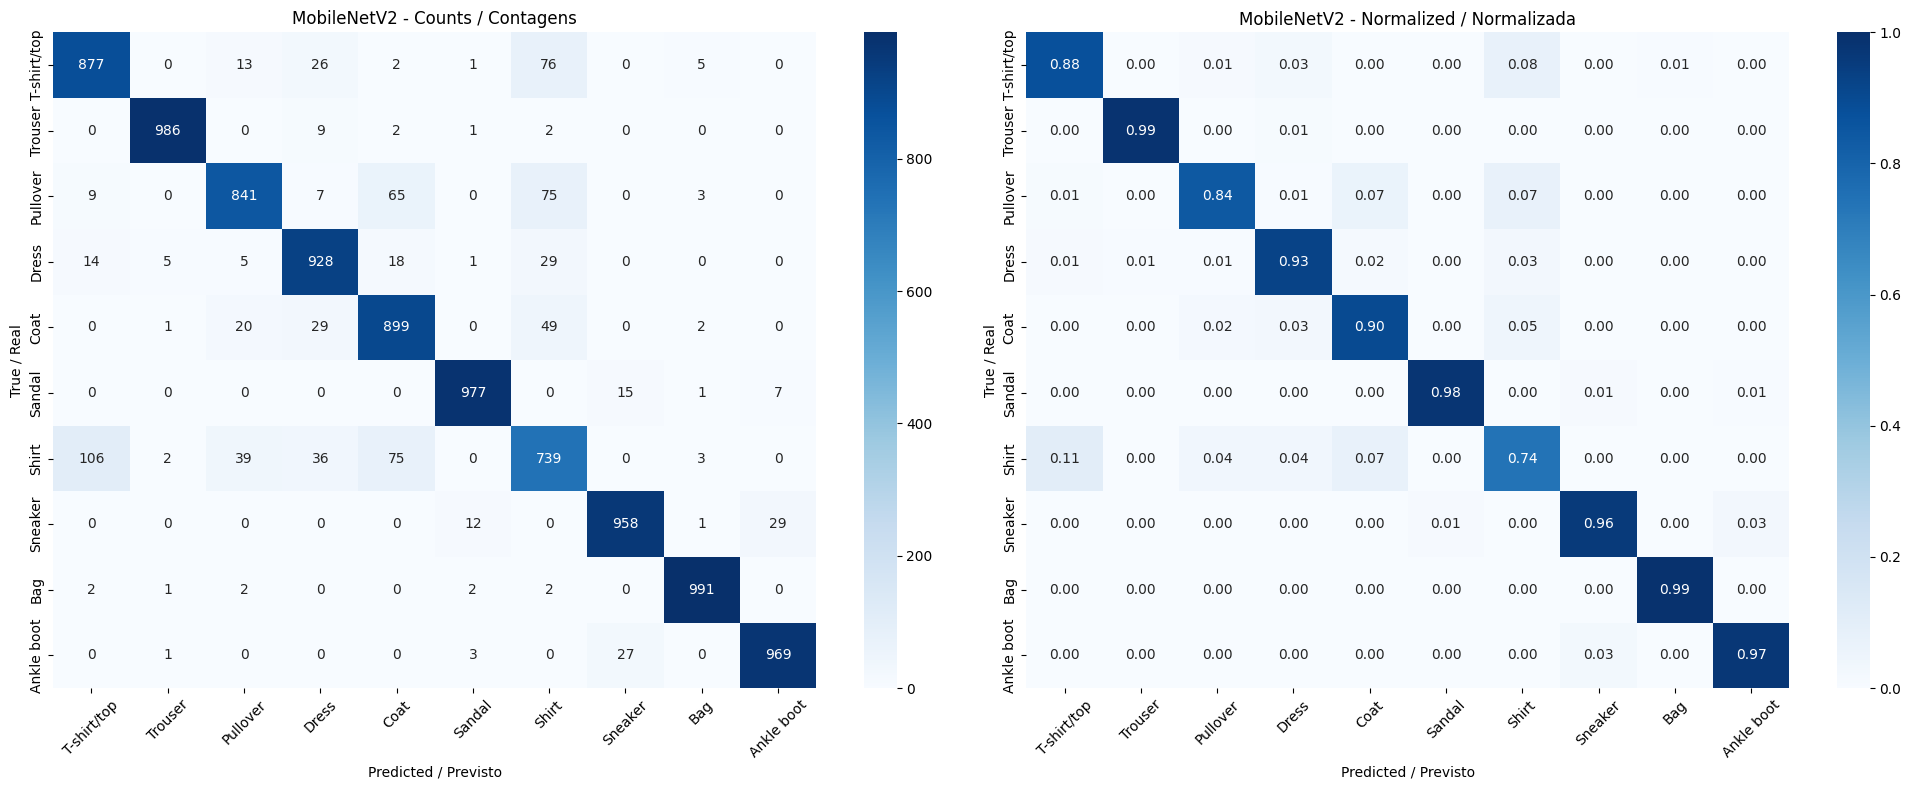

MobileNetV2: Shirt -> T-shirt/top: 106 errors
MobileNetV2: T-shirt/top -> Shirt: 76 errors
MobileNetV2: Shirt -> Coat: 75 errors


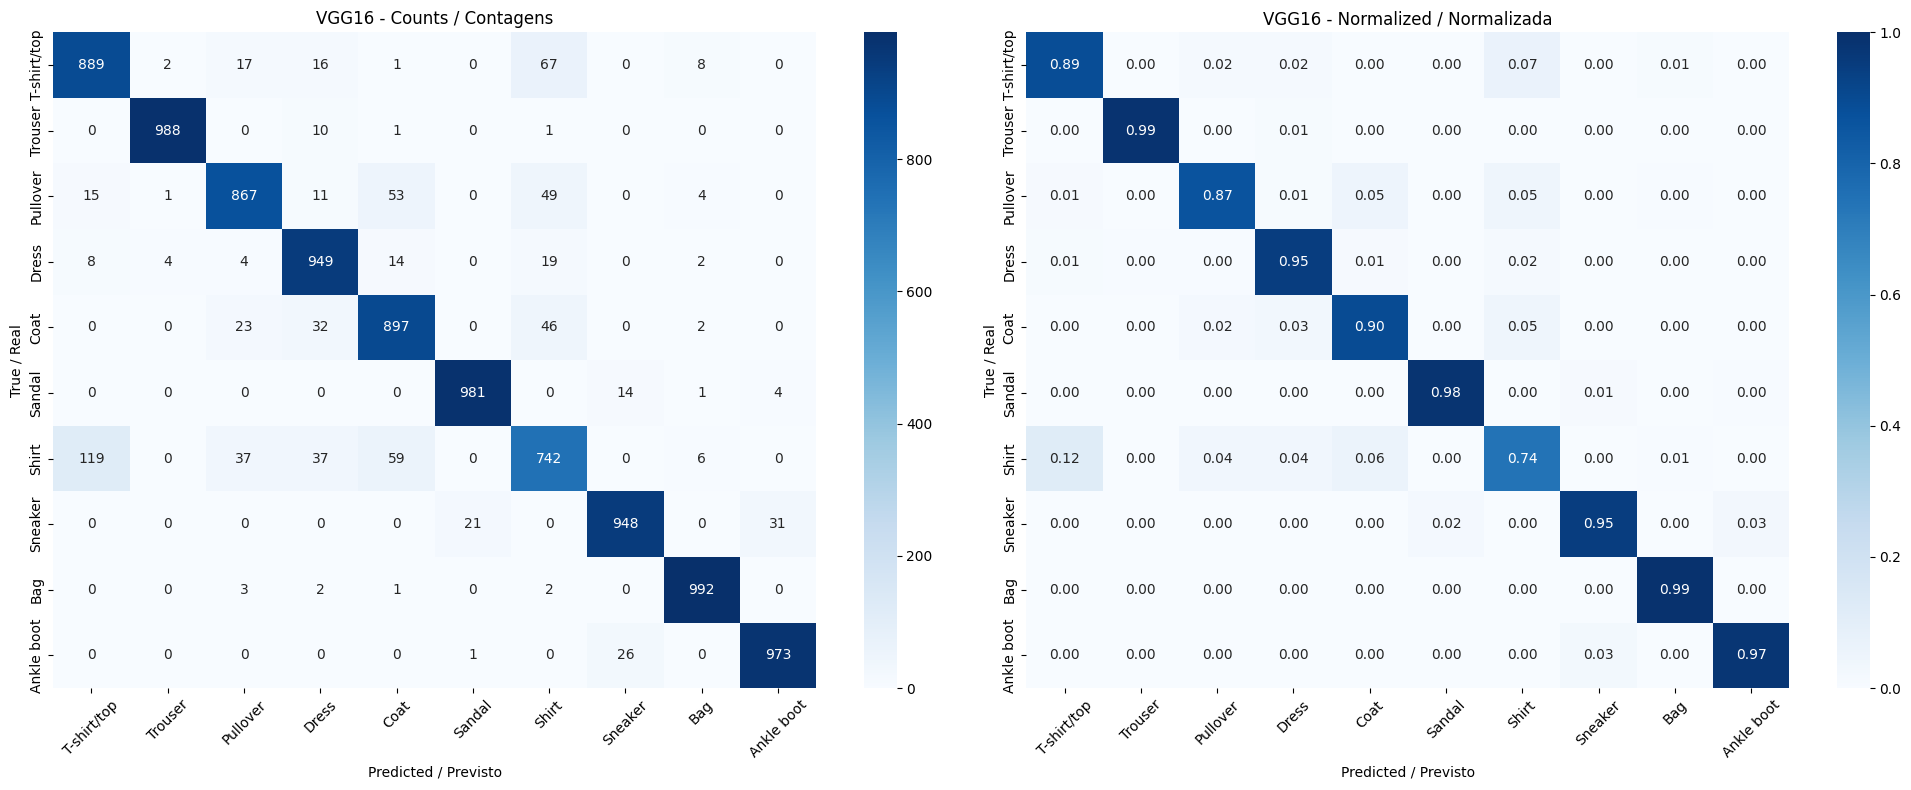

VGG16: Shirt -> T-shirt/top: 119 errors
VGG16: T-shirt/top -> Shirt: 67 errors
VGG16: Shirt -> Coat: 59 errors


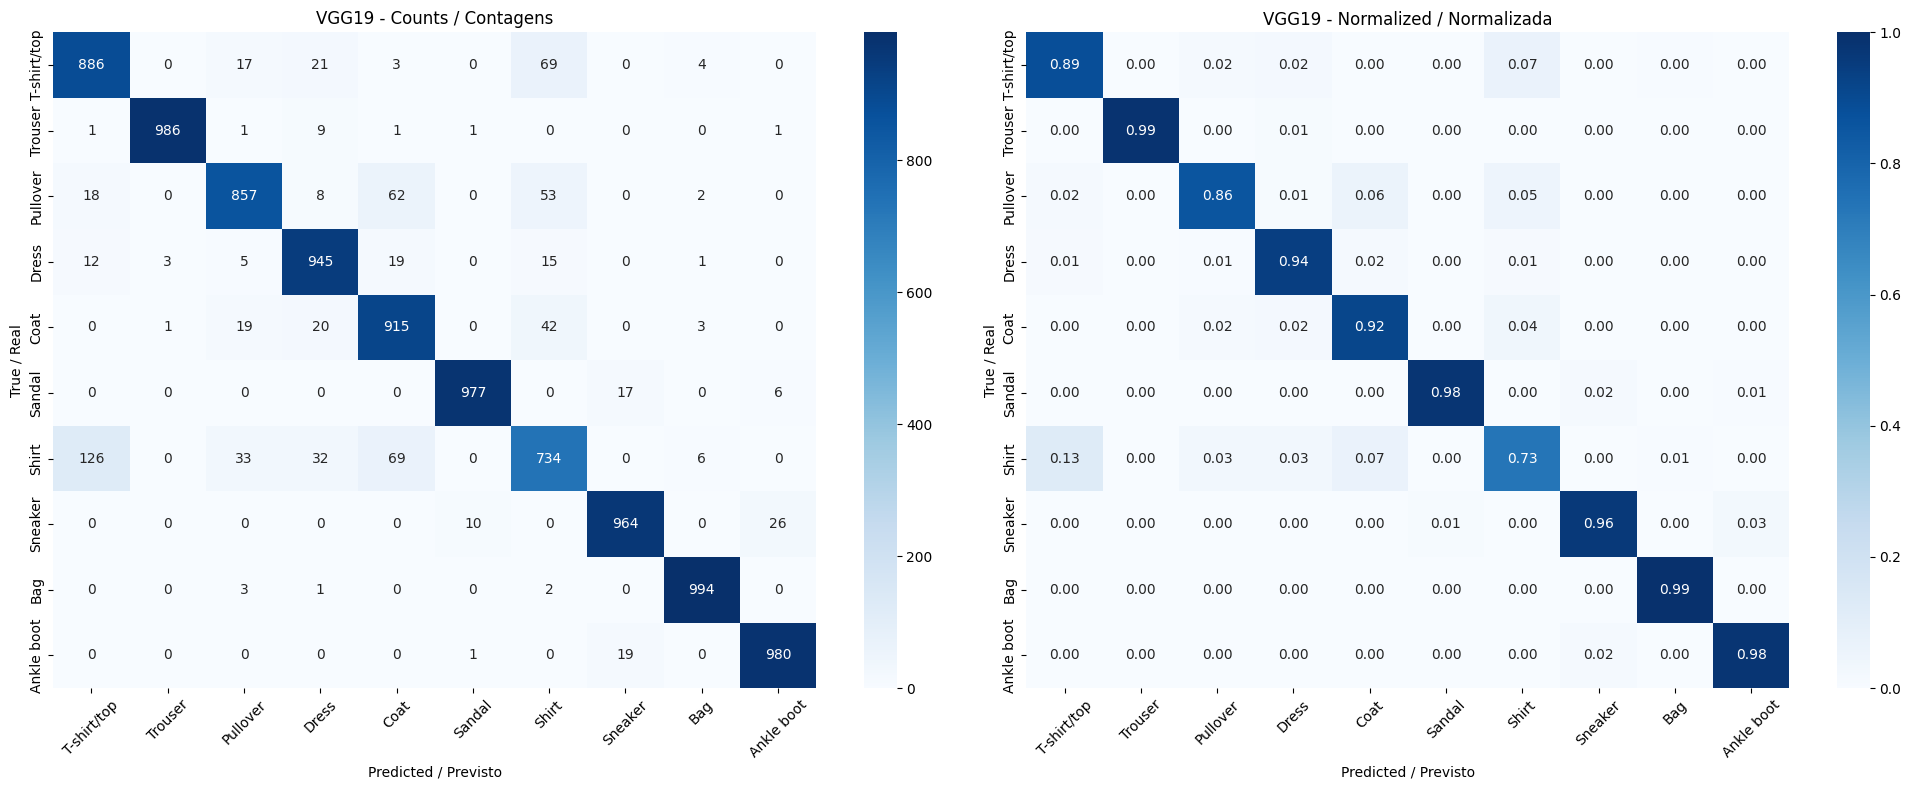

VGG19: Shirt -> T-shirt/top: 126 errors
VGG19: Shirt -> Coat: 69 errors
VGG19: T-shirt/top -> Shirt: 69 errors


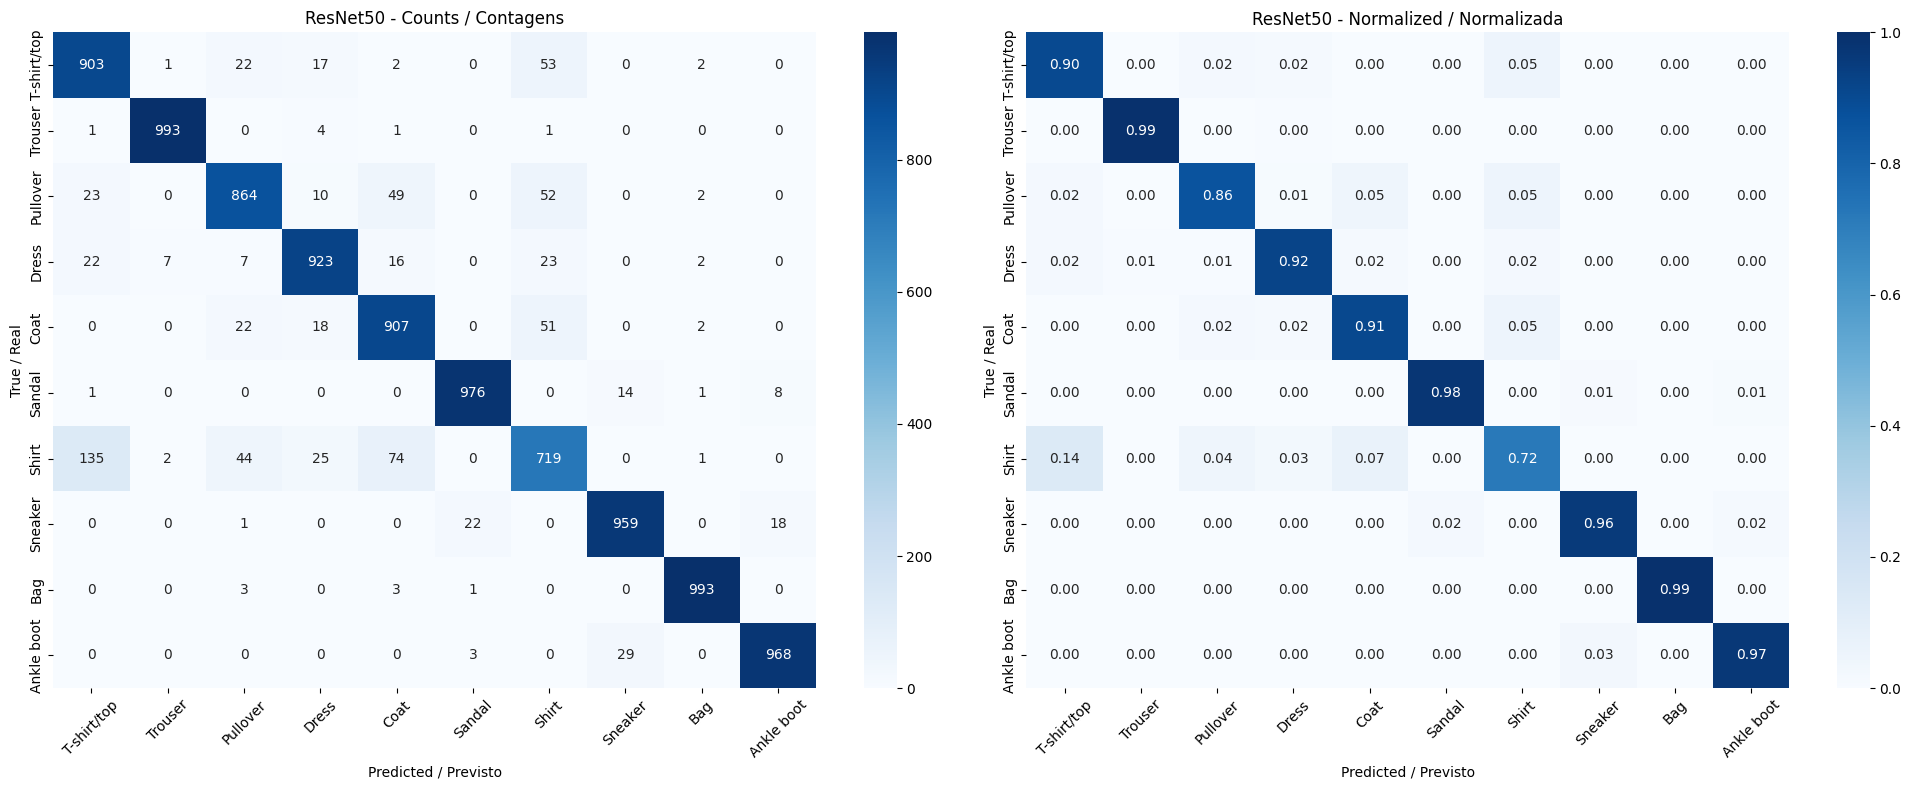

ResNet50: Shirt -> T-shirt/top: 135 errors
ResNet50: Shirt -> Coat: 74 errors
ResNet50: T-shirt/top -> Shirt: 53 errors


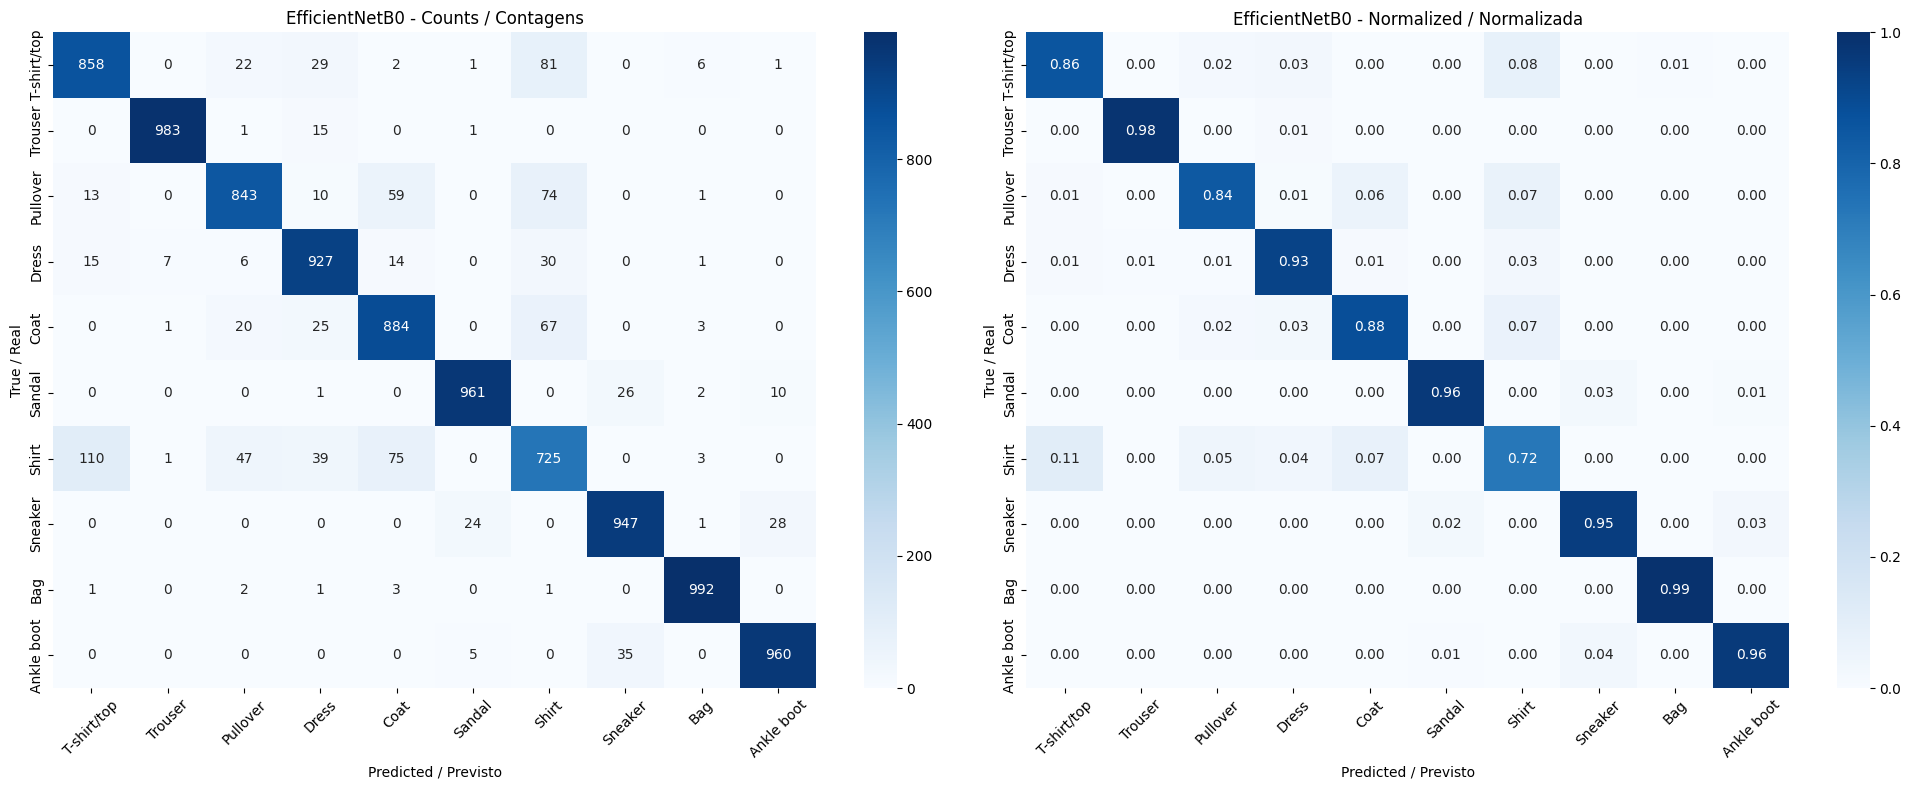

EfficientNetB0: Shirt -> T-shirt/top: 110 errors
EfficientNetB0: T-shirt/top -> Shirt: 81 errors
EfficientNetB0: Shirt -> Coat: 75 errors


In [61]:
"""Confusion matrices for the transfer learning models (Section B).

Loops over the predictions of each model and plots the confusion matrix with
absolute counts and normalized by true class (recall per class), side by
side, on the Fashion MNIST test set.
"""

# predictions per model, baseline included if it is loaded / previsões por modelo, com baseline se estiver carregado
all_predictions = {}
if "cnn_model" in globals():
    all_predictions["CNN baseline"] = cnn_model.predict(X_test, batch_size=256, verbose=0)
all_predictions.update(tl_predictions)

for model_name, y_prob in all_predictions.items():
    # predicted classes / classes previstas
    y_pred = np.argmax(y_prob, axis=1)

    # confusion matrices / matrizes de confusão
    cm_counts = confusion_matrix(y_test, y_pred)
    cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

    # side by side plot / gráfico lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=class_names, yticklabels=class_names,
    )
    axes[0].set_title(f"{model_name} - Counts / Contagens")
    axes[0].set_xlabel("Predicted / Previsto")
    axes[0].set_ylabel("True / Real")
    axes[0].tick_params(axis="x", rotation=45)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1],
        xticklabels=class_names, yticklabels=class_names,
    )
    axes[1].set_title(f"{model_name} - Normalized / Normalizada")
    axes[1].set_xlabel("Predicted / Previsto")
    axes[1].set_ylabel("True / Real")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    # three most confused pairs / três pares mais confundidos
    errors = cm_counts.copy()
    np.fill_diagonal(errors, 0)
    top_idx = np.dstack(np.unravel_index(np.argsort(errors.ravel())[::-1], errors.shape))[0][:3]
    for true_id, pred_id in top_idx:
        print(f"{model_name}: {class_names[true_id]} -> {class_names[pred_id]}: {errors[true_id, pred_id]} errors")

### Confusion Matrix Analysis (ResNet50, Transfer Learning)

The matrix is computed on the 10,000-image test set (1,000 per class). The diagonal holds 9,207 correct predictions and the remaining **793 images are errors**. This is 153 more errors than the baseline CNN (640).

#### 1. Notation and formulas

Let $C_{ij}$ be the number of images of true class $i$ predicted as class $j$:

$$Acc = \frac{\sum_i C_{ii}}{N} = \frac{9207}{10000} = 0.9207$$

$$Recall_i = \frac{C_{ii}}{\sum_j C_{ij}}, \qquad Precision_j = \frac{C_{jj}}{\sum_i C_{ij}}, \qquad F1_i = \frac{2 P_i R_i}{P_i + R_i}$$

Statistical uncertainty and chance-corrected agreement (with balanced rows, $p_e = 0.10$):

$$SE = \sqrt{\frac{0.9207 \cdot 0.0793}{10000}} \approx 0.0027, \qquad IC_{95\%} \approx [0.915,\ 0.926]$$

$$\kappa = \frac{p_o - p_e}{1 - p_e} = \frac{0.9207 - 0.10}{0.90} \approx 0.912$$

Row sums are all 1,000 and column sums add up to 10,000, so the reading of the matrix is consistent.

#### 2. Per-class metrics (computed from the counts)

| Class | Correct | Recall | Predicted (column sum) | Precision | F1 |
|---|---|---|---|---|---|
| T-shirt/top | 906 | 0.906 | 1,083 | 0.837 | 0.870 |
| Trouser | 992 | 0.992 | 1,002 | 0.990 | 0.991 |
| Pullover | 864 | 0.864 | 964 | 0.896 | 0.880 |
| Dress | 925 | 0.925 | 1,003 | 0.922 | 0.924 |
| Coat | 905 | 0.905 | 1,053 | 0.859 | 0.882 |
| Sandal | 974 | 0.974 | 998 | 0.976 | 0.975 |
| **Shirt** | **720** | **0.720** | **895** | **0.805** | **0.760** |
| Sneaker | 959 | 0.959 | 1,004 | 0.955 | 0.957 |
| Bag | 993 | 0.993 | 1,001 | 0.992 | 0.993 |
| Ankle boot | 969 | 0.969 | 997 | 0.972 | 0.970 |

Macro averages:

$$P_{macro} \approx 0.9204, \qquad R_{macro} = Acc = 0.9207, \qquad F1_{macro} = \frac{1}{10}\sum_i F1_i \approx 0.9201$$

Macro recall equals accuracy exactly because every class has the same support.

#### 3. Where the errors are

| Class (true) | Errors | Share of the 793 |
|---|---|---|
| **Shirt** | 280 | 35.3% |
| Pullover | 136 | 17.2% |
| Coat | 95 | 12.0% |
| T-shirt/top | 94 | 11.9% |
| Dress | 75 | 9.5% |
| Sneaker | 41 | 5.2% |
| Ankle boot | 31 | 3.9% |
| Sandal | 26 | 3.3% |
| Trouser | 8 | 1.0% |
| Bag | 7 | 0.9% |

- The four upper-body classes (T-shirt/top, Pullover, Coat, Shirt) produce **605 of 793 errors (76.3%)**. Of these, 522 (65.8% of all errors) are confusions among the four classes themselves.
- Shirt alone contributes $(1 - 0.720)/10 = 0.028$ of the total accuracy loss of 0.0793, which is **35.3%**.
- Trouser, Bag, Sandal and Sneaker add up to only 82 errors (10.3%).

#### 4. Main confusion pairs (both directions)

| Pair | A to B | B to A | Total |
|---|---|---|---|
| Shirt / T-shirt/top | 133 | 51 | **184** |
| Shirt / Coat | 75 | 49 | 124 |
| Shirt / Pullover | 43 | 52 | 95 |
| Pullover / Coat | 50 | 24 | 74 |
| Ankle boot / Sneaker | 29 | 19 | 48 |
| Dress / Shirt | 26 | 22 | 48 |
| Pullover / T-shirt/top | 21 | 22 | 43 |
| Sandal / Sneaker | 16 | 21 | 37 |

- **Shirt to T-shirt/top (133)** is the largest single cell outside the diagonal: 13.3% of all Shirts go to this class.
- **Shirt is the "absorbed" class:** it loses 133 images to T-shirt/top, 75 to Coat, 43 to Pullover and 26 to Dress.
- **Sandal / Sneaker (37 errors)** is a new problem. In the baseline this pair had about 15 errors (13 Sandal to Sneaker and 2 Sneaker to Sandal). Pre-trained features are not helping with the footwear shapes at this resolution.

#### 5. Prediction bias

$$\text{bias}_j = \frac{\sum_i C_{ij}}{1000} - 1$$

| Class | Predicted | Bias |
|---|---|---|
| T-shirt/top | 1,083 | **+8.3%** |
| Coat | 1,053 | +5.3% |
| Pullover | 964 | -3.6% |
| Shirt | 895 | **-10.5%** |

The model over-predicts T-shirt/top and Coat and under-predicts Shirt by 10.5%. This is a stronger bias than the baseline's (Shirt -6.5%, T-shirt/top +4.4%).

#### 6. Comparison with the baseline CNN

| Metric | ResNet50 | Baseline CNN | Difference |
|---|---|---|---|
| Accuracy | 0.9207 | 0.9360 | -0.0153 |
| Macro F1 | 0.9201 | 0.9357 | -0.0156 |
| Total errors | 793 | 640 | +153 (+23.9%) |
| Recall Shirt | 0.720 | 0.781 | -0.061 |
| Shirt to T-shirt/top | 133 | 113 | +20 |
| Shirt to Coat | 75 | 42 | +33 |
| Pullover to Coat | 50 | 57 | -7 |
| Ankle boot to Sneaker | 29 | 40 | -11 |

Recall difference per class (ResNet50 minus baseline):

| Class | T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |
|---|---|---|---|---|---|---|---|---|---|---|
| Delta recall | +0.003 | -0.002 | -0.006 | -0.029 | -0.036 | -0.006 | **-0.061** | -0.028 | +0.003 | +0.009 |

**Is the gap real?** The approximate standard error of the difference between two independent accuracies is

$$SE_{diff} \approx \sqrt{0.0024^2 + 0.0027^2} \approx 0.0036, \qquad \frac{0.0153}{0.0036} \approx 4.2$$

A difference above 4 standard errors is much larger than the 0.005 margin set for a real gain, so **ResNet50 is worse than the baseline**. For a rigorous paired test, McNemar needs the counts $b$ and $c$ of images where only one model is correct:

$$\chi^2 = \frac{(b - c)^2}{b + c}$$

Both models' predictions are available (`tl_predictions["ResNet50"]` and the baseline `y_prob`), so this can be computed directly.

**Where ResNet50 is better:** only Ankle boot (recall +0.009, with 11 fewer Ankle boot to Sneaker errors), and T-shirt/top and Bag by +0.003, which is within noise. The sampling error of a single class recall is about 0.01, so only the drops in Shirt, Coat, Dress and Sneaker are clear.

#### 7. Likely causes (hypotheses, not measured)

- **Domain gap:** the input is a smooth grayscale image upscaled 3.43 times. The ImageNet features of ResNet50 are tuned for color and texture, and the first convolution collapses to $(w_R + w_G + w_B) \star u$.
- **Frozen BatchNorm:** the backbone uses ImageNet statistics $(\mu, \sigma^2)$ for all 53 BN layers, which do not match this data.
- **Small final map:** at 96x96 the last map is only $3 \times 3$, so global average pooling averages 9 positions and loses fine detail such as collars and zippers.
- **Shallow fine-tuning:** with `n_unfreeze = 30` and BN frozen, only part of the last residual block adapts. Shirt, the class that depends most on fine details, suffers the most (-0.061 recall).
- **Capacity is not the issue:** ResNet50 has about 490 parameters per training image against 6 in the baseline, and the extra capacity did not help.

#### 8. Implications for the business problem

- **The baseline remains the better choice:** it has higher accuracy and macro F1, and it is about 82 times smaller (0.29 M versus 23.6 M parameters) and much cheaper to run.
- **Human review** is still needed for the upper-body group. For ResNet50 the Shirt precision (0.805) and recall (0.720) are both low, so a Shirt prediction is wrong about 1 time in 5, and 28% of real Shirts are missed.
- Cost-sensitive view, with a business cost $c_{ij}$ for each error type:

$$E[\text{cost}] = \frac{1}{N}\sum_{i \ne j} c_{ij}\, C_{ij}$$

#### 9. Recommendations

- Compare the five transfer models and the baseline with the same metrics: accuracy, macro F1, Shirt recall and the Shirt to T-shirt/top count.
- Try improving ResNet50 before discarding it: release more layers (`n_unfreeze` 60 to 80), use a higher fine-tuning learning rate ($3 \cdot 10^{-5}$ to $10^{-4}$), train more epochs with `EarlyStopping`, or input 128x128 so the final map becomes $4 \times 4$.
- Use McNemar's test between each transfer model and the baseline to document which differences are real.

#### 10. Conclusion

ResNet50 reaches 92.07% accuracy and 0.9201 macro F1, which is **1.5 points below the baseline CNN** (93.60% and 0.9357). The loss is concentrated in Shirt (recall 0.720), which loses images to T-shirt/top, Coat and Pullover, and the model also introduces a new Sandal / Sneaker confusion. Under the current configuration, transfer learning with ResNet50 does not meet the success criterion of macro F1 above 0.9357.

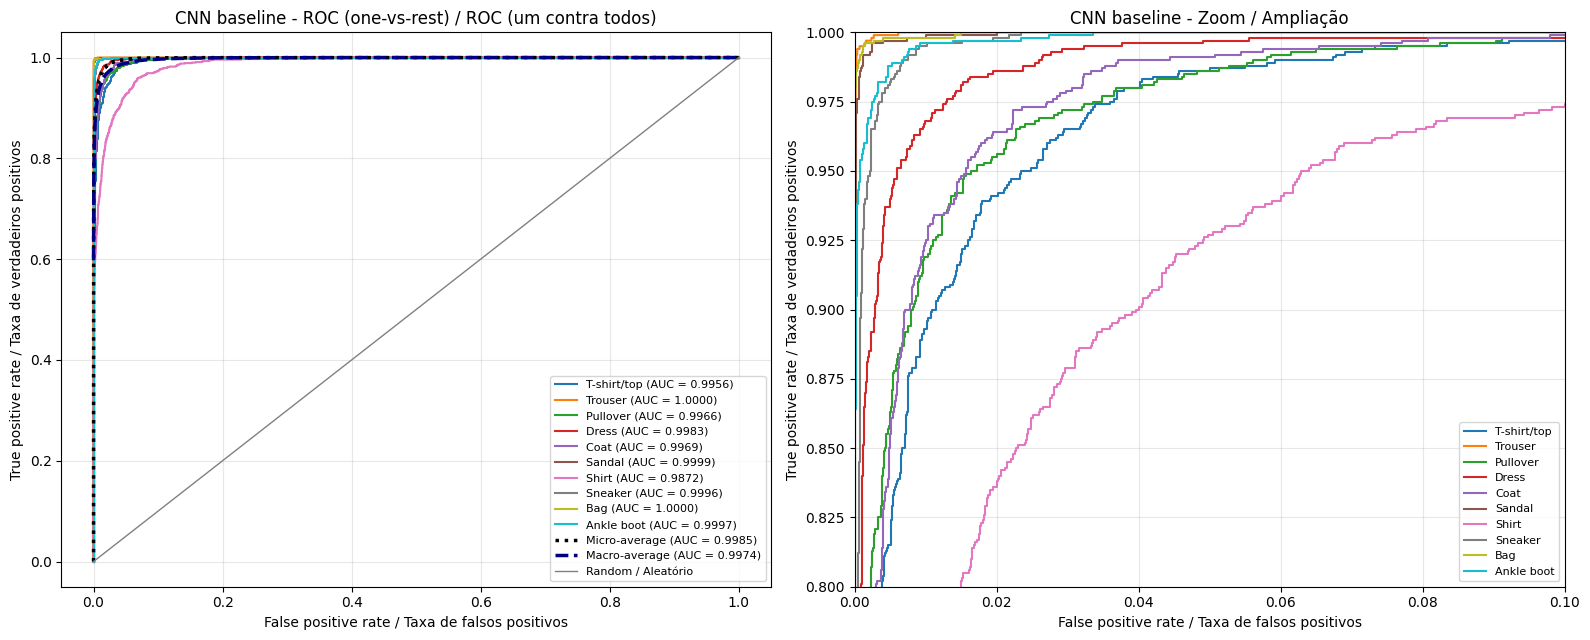

CNN baseline | lowest AUC / menores AUC: Shirt (0.9872), T-shirt/top (0.9956), Pullover (0.9966)


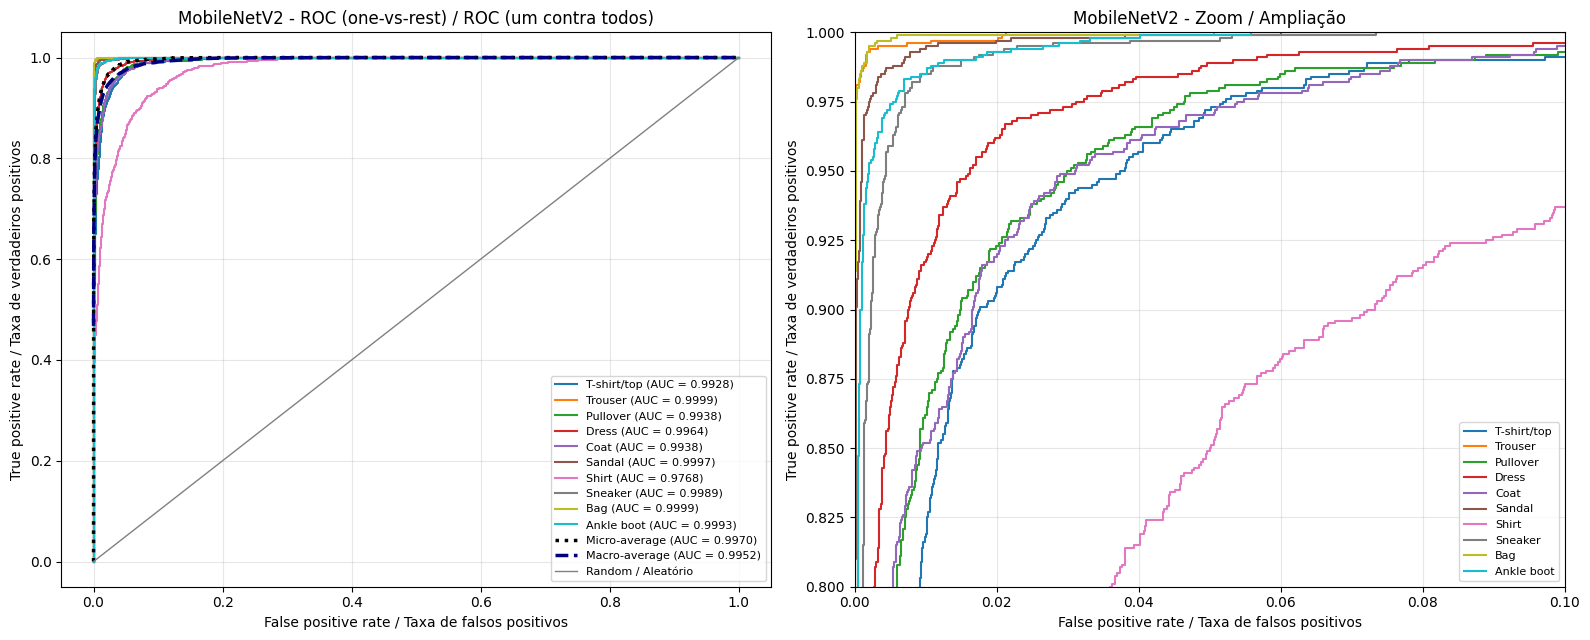

MobileNetV2 | lowest AUC / menores AUC: Shirt (0.9768), T-shirt/top (0.9928), Coat (0.9938)


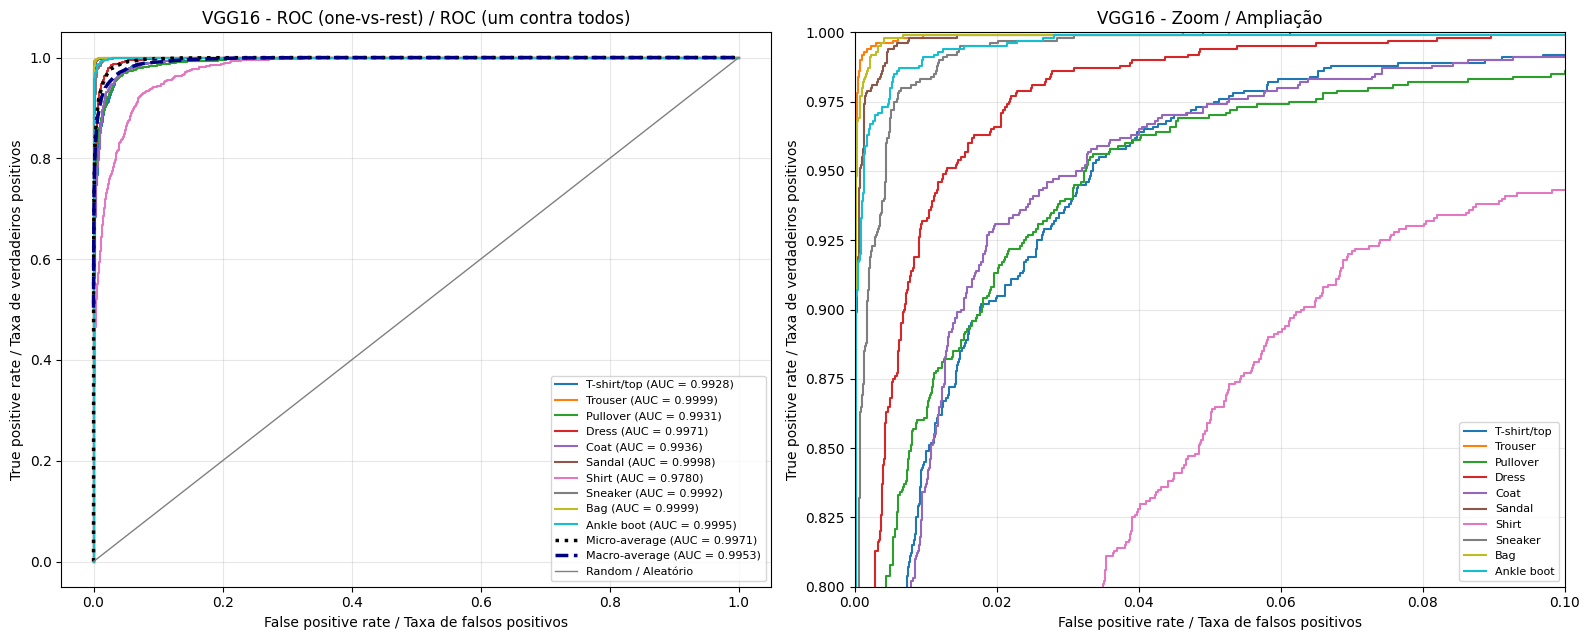

VGG16 | lowest AUC / menores AUC: Shirt (0.9780), T-shirt/top (0.9928), Pullover (0.9931)


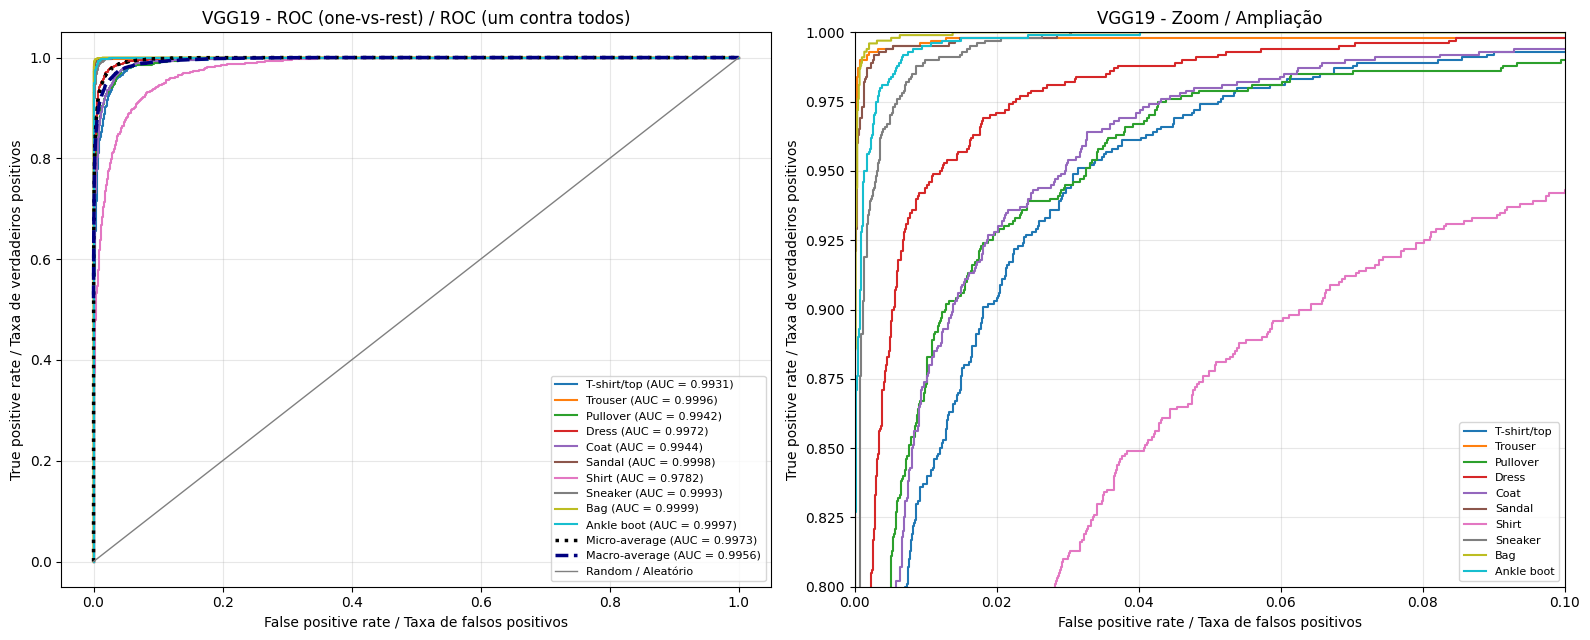

VGG19 | lowest AUC / menores AUC: Shirt (0.9782), T-shirt/top (0.9931), Pullover (0.9942)


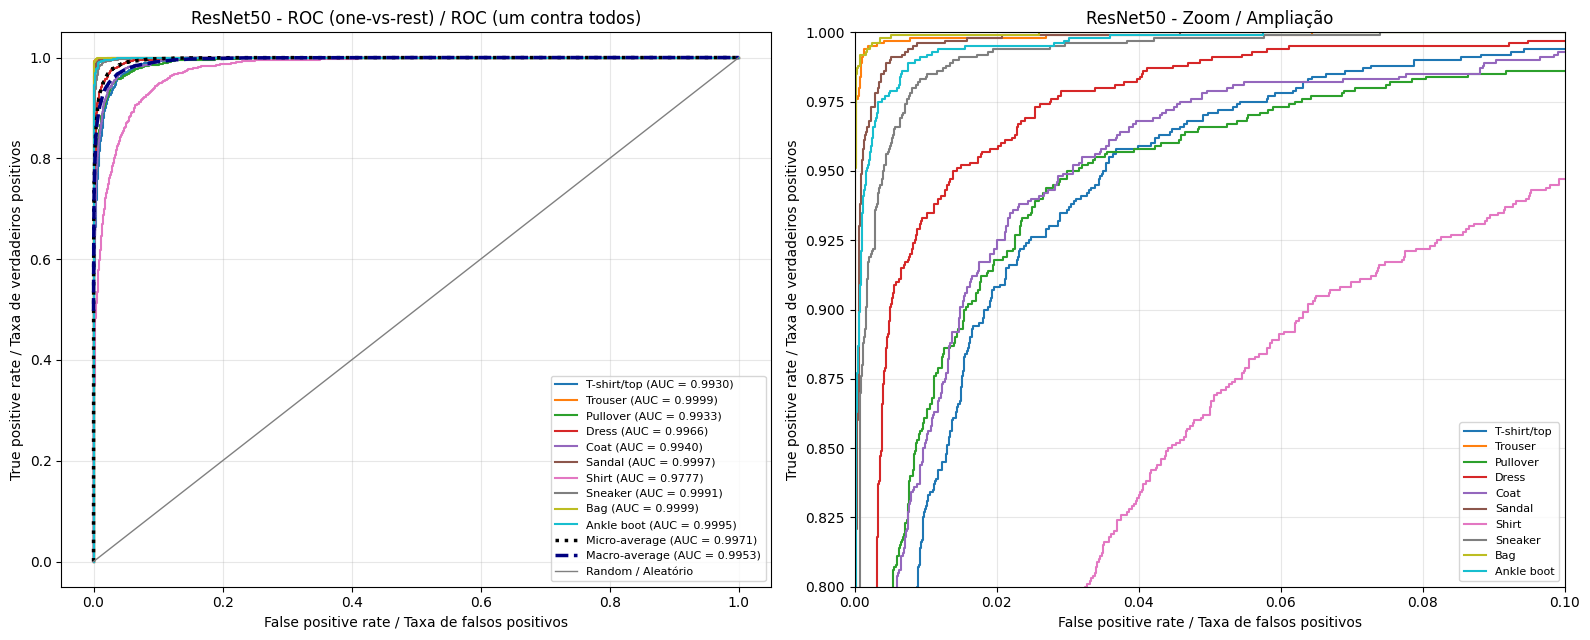

ResNet50 | lowest AUC / menores AUC: Shirt (0.9777), T-shirt/top (0.9930), Pullover (0.9933)


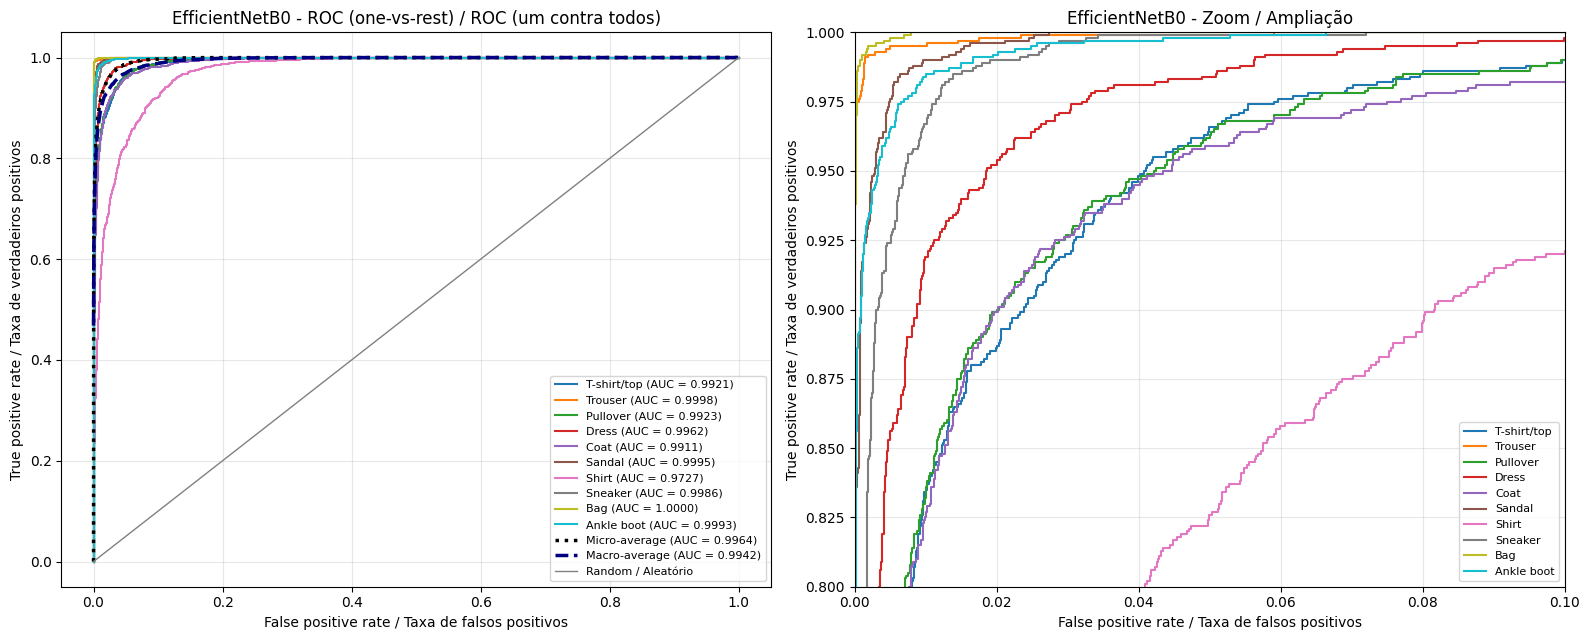

EfficientNetB0 | lowest AUC / menores AUC: Shirt (0.9727), Coat (0.9911), T-shirt/top (0.9921)


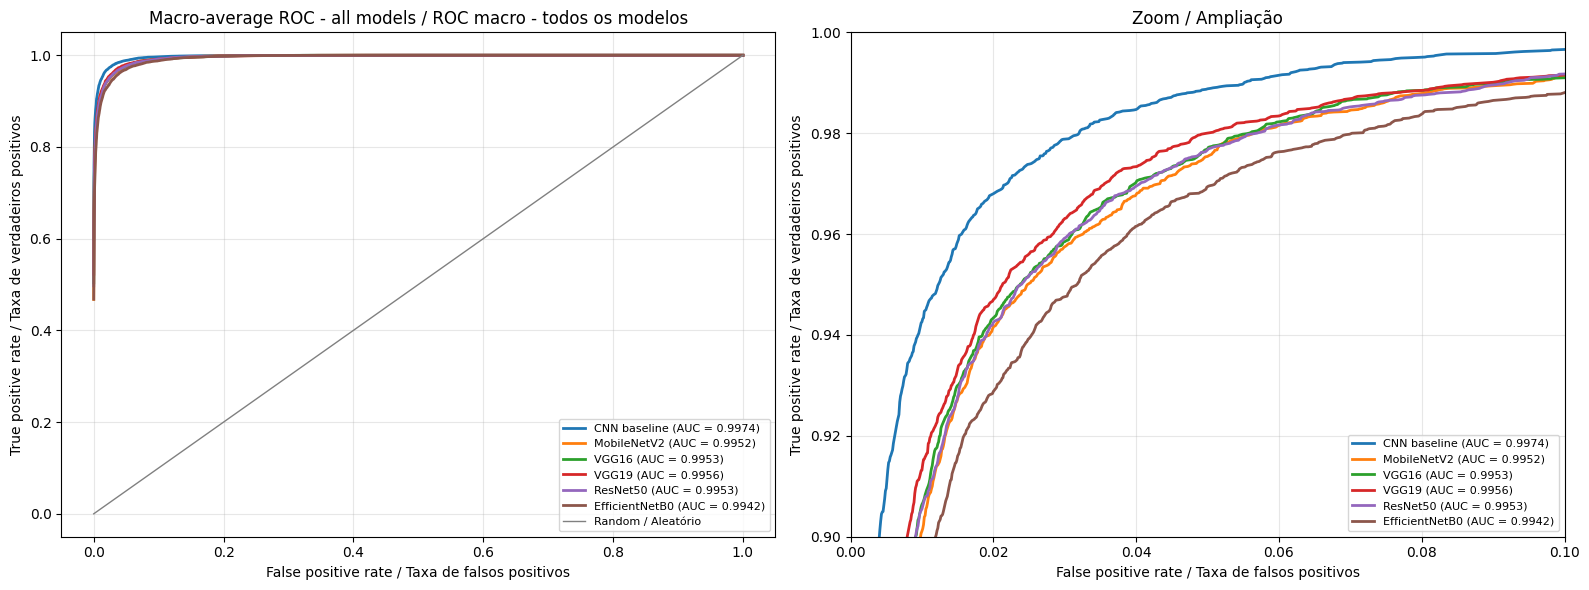

In [62]:
"""ROC curves for the transfer learning models (Section B).

Loops over the predictions of each model and plots one-vs-rest ROC curves per
class, plus micro-average and macro-average curves, with the AUC in the
legend. At the end, compares the macro-average ROC of all models.
"""

# predictions per model, baseline included if it is loaded / previsões por modelo, com baseline se estiver carregado
all_predictions = {}
if "cnn_model" in globals():
    all_predictions["CNN baseline"] = cnn_model.predict(X_test, batch_size=256, verbose=0)
all_predictions.update(tl_predictions)

# one-hot encode the true labels / codificar os rótulos reais em one-hot
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# colors per class / cores por classe
colors = plt.cm.tab10(np.arange(10))

# macro-average curves per model for the final comparison / curvas macro por modelo para a comparação final
macro_curves = {}

for model_name, y_prob in all_predictions.items():
    # ROC curve and AUC per class / curva ROC e AUC por classe
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average / média micro
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average / média macro
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(10):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= 10
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    macro_curves[model_name] = (fpr["macro"], tpr["macro"], roc_auc["macro"])

    # ROC plot and zoom side by side / gráfico ROC e ampliação lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

    for i, color in zip(range(10), colors):
        axes[0].plot(fpr[i], tpr[i], color=color, lw=1.5,
                     label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})")
        axes[1].plot(fpr[i], tpr[i], color=color, lw=1.5, label=class_names[i])

    axes[0].plot(fpr["micro"], tpr["micro"], color="black", linestyle=":", lw=2.5,
                 label=f"Micro-average (AUC = {roc_auc['micro']:.4f})")
    axes[0].plot(fpr["macro"], tpr["macro"], color="navy", linestyle="--", lw=2.5,
                 label=f"Macro-average (AUC = {roc_auc['macro']:.4f})")
    axes[0].plot([0, 1], [0, 1], color="gray", lw=1, label="Random / Aleatório")

    axes[0].set_title(f"{model_name} - ROC (one-vs-rest) / ROC (um contra todos)")
    axes[0].set_xlabel("False positive rate / Taxa de falsos positivos")
    axes[0].set_ylabel("True positive rate / Taxa de verdadeiros positivos")
    axes[0].legend(loc="lower right", fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_xlim(0, 0.1)
    axes[1].set_ylim(0.8, 1.0)
    axes[1].set_title(f"{model_name} - Zoom / Ampliação")
    axes[1].set_xlabel("False positive rate / Taxa de falsos positivos")
    axes[1].set_ylabel("True positive rate / Taxa de verdadeiros positivos")
    axes[1].legend(loc="lower right", fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # lowest AUC classes / classes com menor AUC
    worst = sorted(range(10), key=lambda i: roc_auc[i])[:3]
    print(f"{model_name} | lowest AUC / menores AUC:",
          ", ".join(f"{class_names[i]} ({roc_auc[i]:.4f})" for i in worst))

# macro-average comparison across models / comparação da média macro entre modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model_name, (m_fpr, m_tpr, m_auc) in macro_curves.items():
    for ax in axes:
        ax.plot(m_fpr, m_tpr, lw=2, label=f"{model_name} (AUC = {m_auc:.4f})")

axes[0].plot([0, 1], [0, 1], color="gray", lw=1, label="Random / Aleatório")
axes[0].set_title("Macro-average ROC - all models / ROC macro - todos os modelos")
axes[1].set_xlim(0, 0.1)
axes[1].set_ylim(0.9, 1.0)
axes[1].set_title("Zoom / Ampliação")
for ax in axes:
    ax.set_xlabel("False positive rate / Taxa de falsos positivos")
    ax.set_ylabel("True positive rate / Taxa de verdadeiros positivos")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ROC Analysis: Baseline CNN vs Transfer Learning Models

The seven charts show one-vs-rest ROC curves on the 10,000-image test set (1,000 positives and 9,000 negatives per class) for the baseline CNN and the five backbones. The last chart overlays the macro-average curves. **The baseline CNN has the highest AUC and the highest curve at every operating point of the zoom. No transfer learning model beats it.**

#### 1. Formulas

For class $c$ and threshold $\tau$ on the predicted probability:

$$TPR(\tau) = \frac{TP}{TP + FN}, \qquad FPR(\tau) = \frac{FP}{FP + TN}$$

$$AUC_c = \int_0^1 TPR \; d(FPR) = P\left(\hat{y}_c(x^+) > \hat{y}_c(x^-)\right)$$

$$AUC_{macro} = \frac{1}{10}\sum_{c=1}^{10} AUC_c, \qquad \Delta_c = AUC_c^{model} - AUC_c^{baseline}$$

The ranking error is $1 - AUC$. Because the AUCs are close to 1, comparisons are clearer in this scale than in the raw AUC.

#### 2. AUC per class (read from the legends)

| Class | CNN | MobileNetV2 | VGG16 | VGG19 | ResNet50 | EffNetB0 |
|---|---|---|---|---|---|---|
| T-shirt/top | **0.9954** | 0.9929 | 0.9928 | 0.9931 | 0.9930 | 0.9921 |
| Trouser | **0.9999** | 0.9999 | 0.9999 | 0.9997 | 0.9999 | 0.9998 |
| Pullover | **0.9968** | 0.9939 | 0.9931 | 0.9942 | 0.9933 | 0.9924 |
| Dress | **0.9982** | 0.9964 | 0.9971 | 0.9972 | 0.9966 | 0.9962 |
| Coat | **0.9967** | 0.9938 | 0.9936 | 0.9943 | 0.9939 | 0.9911 |
| Sandal | **0.9999** | 0.9997 | 0.9998 | 0.9998 | 0.9997 | 0.9995 |
| **Shirt** | **0.9871** | 0.9768 | 0.9781 | 0.9782 | 0.9776 | 0.9727 |
| Sneaker | **0.9996** | 0.9989 | 0.9992 | 0.9993 | 0.9991 | 0.9986 |
| Bag | 0.9999 | 0.9999 | 0.9999 | 0.9999 | 0.9999 | **1.0000** |
| Ankle boot | 0.9996 | 0.9993 | 0.9995 | **0.9997** | 0.9995 | 0.9993 |
| **Micro** | **0.9984** | 0.9970 | 0.9972 | 0.9973 | 0.9970 | 0.9964 |
| **Macro** | **0.9974** | 0.9952 | 0.9953 | 0.9956 | 0.9953 | 0.9942 |

Check of the macro average (EfficientNetB0): $(0.9921 + 0.9998 + 0.9924 + 0.9962 + 0.9911 + 0.9995 + 0.9727 + 0.9986 + 1.0000 + 0.9993)/10 = 0.9942$, which matches the legend. The other models match within rounding (0.0001).

#### 3. Model ranking by macro AUC

| Rank | Model | Macro AUC | $\Delta$ vs baseline | $1 - AUC_{macro}$ | Ratio vs baseline |
|---|---|---|---|---|---|
| 1 | CNN baseline | 0.9974 | 0 | 0.0026 | 1.0x |
| 2 | VGG19 | 0.9956 | -0.0018 | 0.0044 | 1.7x |
| 3 | VGG16 / ResNet50 | 0.9953 | -0.0021 | 0.0047 | 1.8x |
| 5 | MobileNetV2 | 0.9952 | -0.0022 | 0.0048 | 1.8x |
| 6 | EfficientNetB0 | 0.9942 | -0.0032 | 0.0058 | 2.2x |

- The baseline has the lowest ranking error. Every transfer model has 1.7 to 2.2 times more.
- **VGG19, VGG16, ResNet50 and MobileNetV2 differ by at most 0.0004**, so they form one cluster that cannot be separated with this evidence (see section 6).
- **EfficientNetB0 is clearly the weakest.** It lost to the baseline in 9 of the 10 classes (Bag is the exception at 1.0000).

#### 4. Where the AUC loss comes from

Because the macro AUC is a plain average, the gap to the baseline splits into per-class contributions $\Delta_c / 10$. For VGG19, the best transfer model:

| Group | Classes | Sum of $\Delta_c$ | Share of the macro gap |
|---|---|---|---|
| Shirt | Shirt | -0.0089 | about 49% |
| Other upper-body | T-shirt/top, Pullover, Coat | -0.0023, -0.0026, -0.0024 | about 41% |
| Dress | Dress | -0.0010 | about 6% |
| Footwear, Trouser, Bag | 6 classes | below 0.0005 together | below 3% |

- **About 90% of the macro AUC loss is in the four upper-body classes**, the same group that dominates the confusion matrices.
- **Shirt alone explains about half.** Its ranking error goes from 0.0129 (baseline) to 0.0218 (VGG19, 1.7x) and 0.0273 (EfficientNetB0, 2.1x).
- Trouser, Bag, Sandal, Sneaker and Ankle boot are at 0.9986 or above for every model. These classes are saturated, so they cannot separate the models.

#### 5. Zoom analysis (FPR from 0 to 0.1)

**Macro-average curve** (read from the last chart):

| FPR | CNN | VGG19 | VGG16 / ResNet50 / MobileNetV2 | EffNetB0 |
|---|---|---|---|---|
| 0.02 | about 0.968 | about 0.947 | about 0.94 to 0.945 | about 0.928 |
| 0.04 | about 0.985 | about 0.972 | about 0.968 to 0.971 | about 0.963 |
| 0.10 | about 0.996 | about 0.992 | about 0.991 | about 0.988 |

- The baseline curve is above all others over the entire range, with a gap of about 2 points of TPR at FPR = 0.02. In practice, at a low false alarm rate, the baseline finds about 2% more true positives.
- The gap shrinks as FPR grows (0.4 to 0.8 points at FPR = 0.1), because all models eventually capture almost every positive.
- The four middle models overlap, and EfficientNetB0 stays below them across the zoom.

**Shirt curve** (the most informative in the per-model charts). FPR needed to reach $TPR = 0.80$, and TPR at $FPR = 0.10$:

| Model | FPR for TPR = 0.80 | False positives (of 9,000) | TPR at FPR = 0.10 |
|---|---|---|---|
| CNN baseline | about 0.015 | about 135 | about 0.972 |
| VGG19 | about 0.028 | about 250 | about 0.944 |
| ResNet50 | about 0.032 | about 290 | about 0.945 |
| VGG16 | about 0.033 | about 300 | about 0.943 |
| MobileNetV2 | about 0.036 | about 325 | about 0.937 |
| EfficientNetB0 | about 0.040 | about 360 | about 0.922 |

To find 80% of the Shirts, VGG19 accepts about **1.9 times** more false alarms than the baseline, and EfficientNetB0 about **2.7 times**. This is the practical meaning of the AUC gap.

Within the middle classes (T-shirt/top, Pullover, Coat), the baseline curves also sit to the left of the transfer curves. For example, to reach $TPR = 0.90$ the baseline needs $FPR \approx 0.006$ to $0.010$, while the transfer models need about $0.010$ to $0.016$.

#### 6. Statistical uncertainty

The standard error of a single AUC, with $n_1 = 1000$ positives and $n_0 = 9000$ negatives, is given by the Hanley-McNeil formula:

$$SE = \sqrt{\frac{A(1-A) + (n_1 - 1)(Q_1 - A^2) + (n_0 - 1)(Q_2 - A^2)}{n_1 n_0}}, \quad Q_1 = \frac{A}{2-A},\; Q_2 = \frac{2A^2}{1+A}$$

For $A = 0.995$ this gives $SE \approx 0.0016$ per class. Consequences:

- **Large gaps are real.** Shirt: $0.9871$ vs $0.9782$ (difference 0.0089, more than 5 SE). The macro gap of 0.0018 to 0.0032 is also consistent across five models and nine classes.
- **Small gaps are not.** The 0.0004 spread among VGG19, VGG16, ResNet50 and MobileNetV2 is well below the noise, so the order among them should not be reported as a result.
- All models use the same test images, so their errors are correlated. The correct comparison is a **paired** test. Use DeLong's test or a paired bootstrap, where the AUC difference is recomputed over resampled test sets:

$$\hat{\Delta}^{(b)} = AUC^{(b)}_{A} - AUC^{(b)}_{B}, \quad b = 1,\dots,B$$

and check whether the 95% percentile interval of $\hat{\Delta}$ excludes 0.

#### 7. Micro versus macro

$$AUC_{micro} - AUC_{macro}: \quad \text{CNN } 0.0010,\; \text{VGG19 } 0.0017,\; \text{EffNetB0 } 0.0022$$

The micro average pools all decisions, so it is dominated by easy negatives and is always higher. A wider micro-macro gap means that the model is more uneven across classes. The gap is smallest for the baseline and largest for EfficientNetB0, which confirms that the transfer models lose more on a few hard classes (mainly Shirt) than on the rest.

#### 8. Consistency with other results

- **Confusion matrices:** ResNet50 had accuracy 0.9207 against 0.9360 for the baseline (the baseline in that comparison was the earlier run), with Shirt recall of 0.720. This agrees with its Shirt AUC of 0.9776, which is also far below the baseline.
- **VGG19 training curves:** validation accuracy of 0.921 after fine-tuning is consistent with the lower ranking quality seen here.
- **Important:** the baseline's AUC in these charts (macro 0.9974, micro 0.9984, Shirt 0.9871) is **different from the first ROC analysis** (0.9970, 0.9982 and 0.9862). So the baseline predictions in this run come from a different model state, probably a retrained version (for example with `callbacks=callbacks`). Its accuracy and F1 may have changed too. Recompute the classification report for this version before using the reference table.
- Remember that ROC measures **ranking**, not the argmax decision. The ordering here should be confirmed with accuracy, macro F1 and per-class recall of the final test run.

#### 9. Likely reasons (hypotheses, not measured)

- **Domain gap:** the backbones were trained on color, high-resolution photos, while the input is grayscale, upscaled 3.43 times and smooth.
- **Frozen BatchNorm** statistics from ImageNet in MobileNetV2, ResNet50 and EfficientNetB0. VGG has no BatchNorm, and it is slightly better in AUC, which is consistent with this idea but is not proof.
- **Final feature map of 3 x 3** at 96 x 96, which loses fine details (collars, buttons, zippers) that are exactly what separates Shirt from T-shirt/top, Pullover and Coat.
- **EfficientNetB0** is the most tied to its design resolution (224 x 224) and uses internal normalization and squeeze-excitation blocks tuned for natural images, which fits its last place.
- **Shallow fine-tuning:** `n_unfreeze` releases layers, not parameters, and BatchNorm layers stay frozen.

#### 10. Business implications

- **The baseline is the best choice on every axis:** highest macro AUC, best zoom curve, and about 8 to 82 times fewer parameters than the backbones.
- A confidence threshold for **human review** works best with the baseline, because it reaches a given recall with fewer false alarms. For Shirt, the cost of finding 80% of the items is about 135 false alarms for the baseline against 250 to 360 for the others.
- Per-class thresholds can be chosen with Youden's index or with business costs:

$$J = TPR - FPR, \qquad E[\text{cost}] = C_{FN} \cdot FN + C_{FP} \cdot FP$$

#### 11. Recommendations

- Run a **paired bootstrap or DeLong test** (baseline vs each model) and report the interval of $\Delta AUC_{macro}$ and $\Delta AUC_{Shirt}$.
- Report **TPR at fixed FPR** (for example 0.01 and 0.05) for Shirt, T-shirt/top, Pullover and Coat, as in the table of section 5.
- Add **precision-recall curves** for these four classes, because the 1:9 imbalance in one-vs-rest dilutes FPR.
- To give transfer learning a fair second chance: release more layers, use a higher fine-tuning learning rate, train longer with `EarlyStopping`, or use 128 x 128 inputs (final map of 4 x 4).
- Test an **ensemble** (average of the baseline and VGG19 probabilities). If their errors differ, the combined AUC may exceed the baseline's. This is a hypothesis to test.

#### 12. Conclusion

The baseline CNN reaches a macro AUC of **0.9974**, against 0.9942 to 0.9956 for the transfer models. The gap is small in absolute terms but 1.7 to 2.2 times larger in ranking error, and it is concentrated in the four upper-body classes, with Shirt accounting for about half. Among the transfer models, EfficientNetB0 is the weakest, and the other four are statistically close. On this evidence, the success criterion of Part 2 is not met: no transfer learning model outperforms the baseline CNN.

# Part 11 - Image predictions

In [63]:
"""Prediction visualization for all models (Section B).

Loops over the predictions of each model and shows the same random test
images with predicted label and confidence (green = correct, red = wrong),
followed by the most confident errors of each model.
"""

# predictions per model, baseline included if it is loaded / previsões por modelo, com baseline se estiver carregado
all_predictions = {}
if "cnn_model" in globals():
    all_predictions["CNN baseline"] = cnn_model.predict(X_test, batch_size=256, verbose=0)
all_predictions.update(tl_predictions)

# same images for every model / mesmas imagens para todos os modelos
rng = np.random.default_rng(42)
n_rows, n_cols = 2, 8
sample_idx = rng.choice(len(X_test), n_rows * n_cols, replace=False)

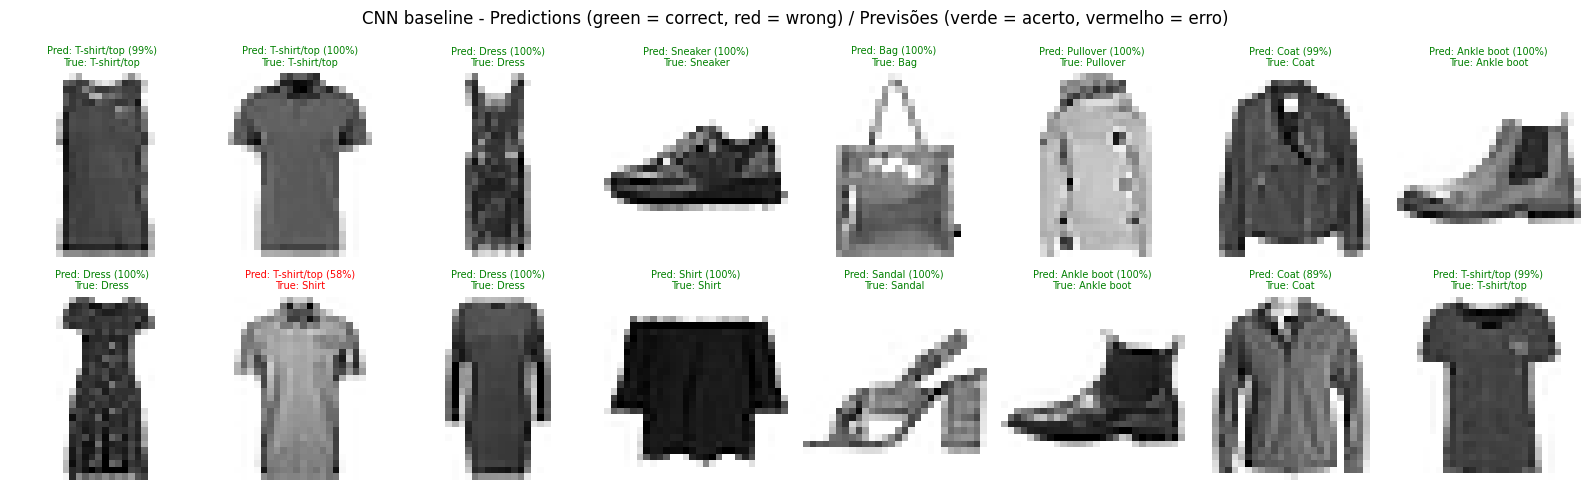

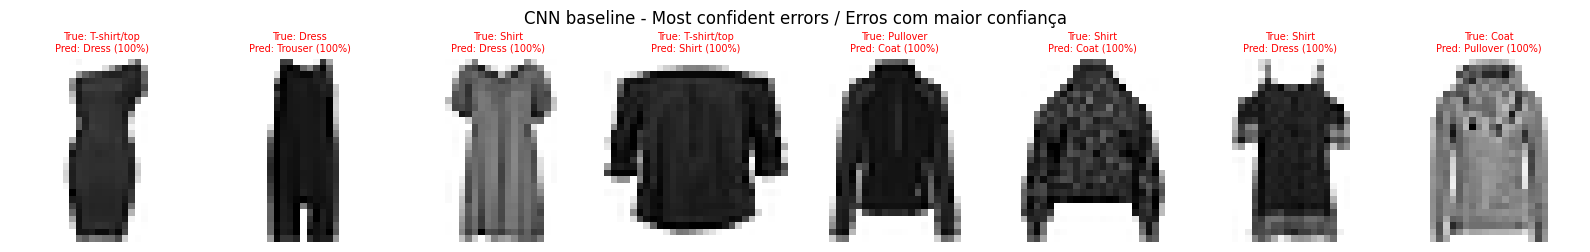

CNN baseline: 579 errors of 10000 (5.79%)


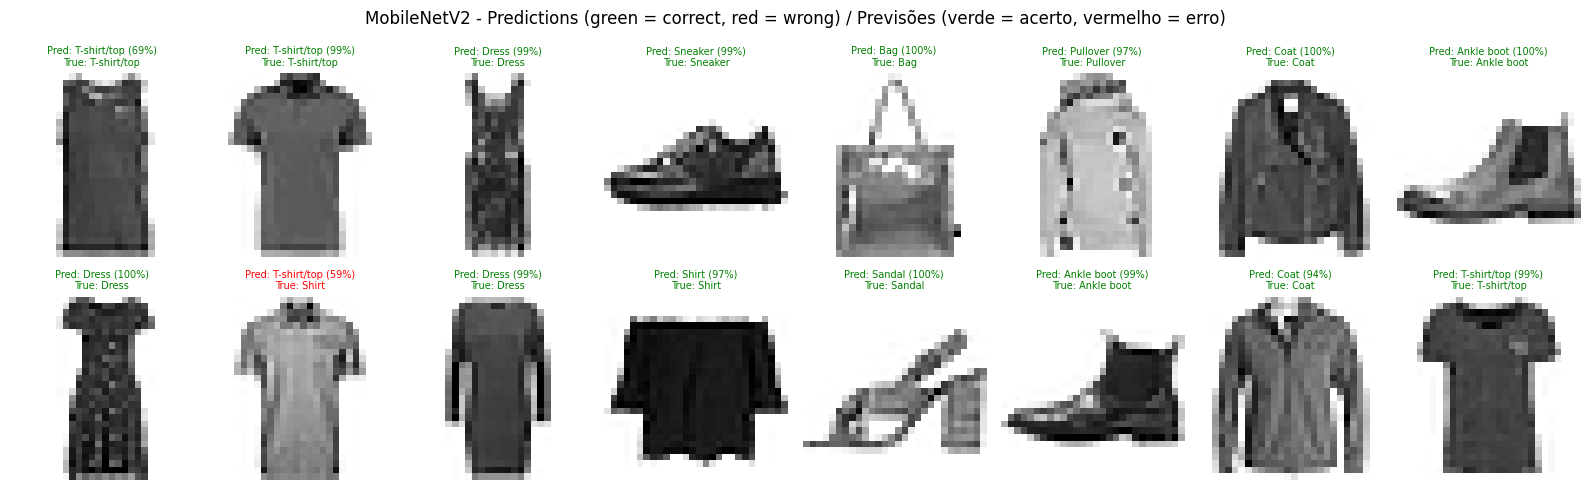

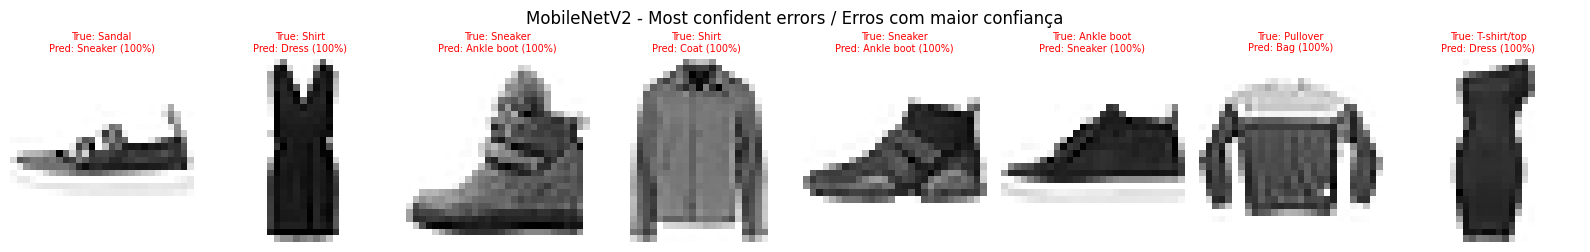

MobileNetV2: 835 errors of 10000 (8.35%)


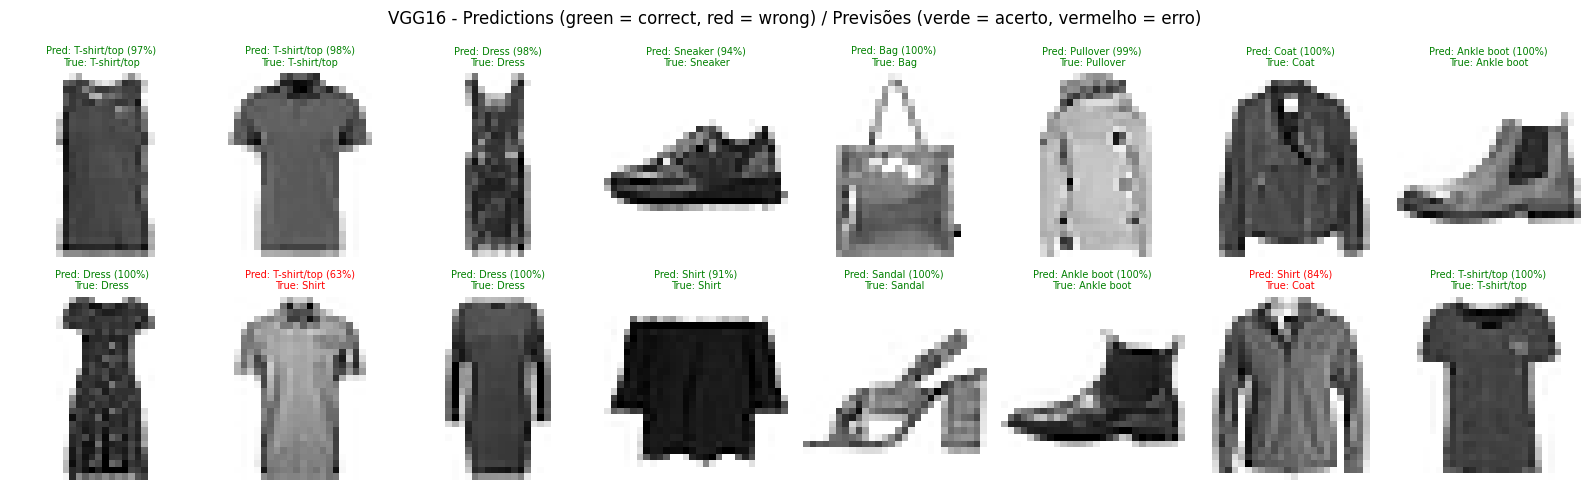

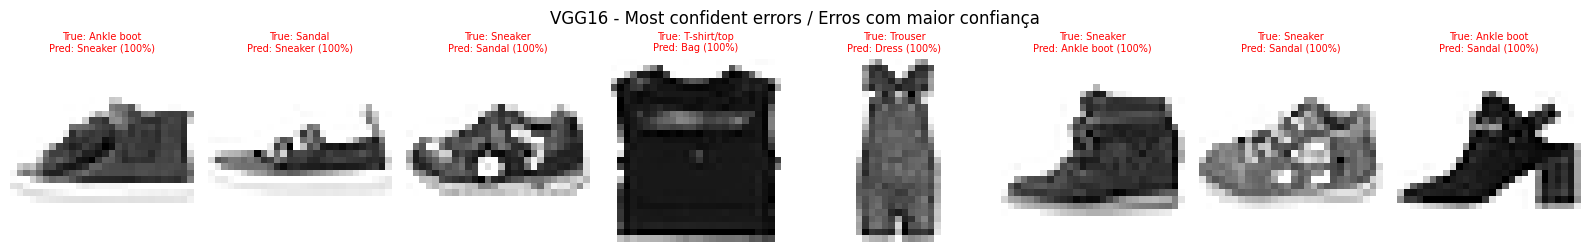

VGG16: 774 errors of 10000 (7.74%)


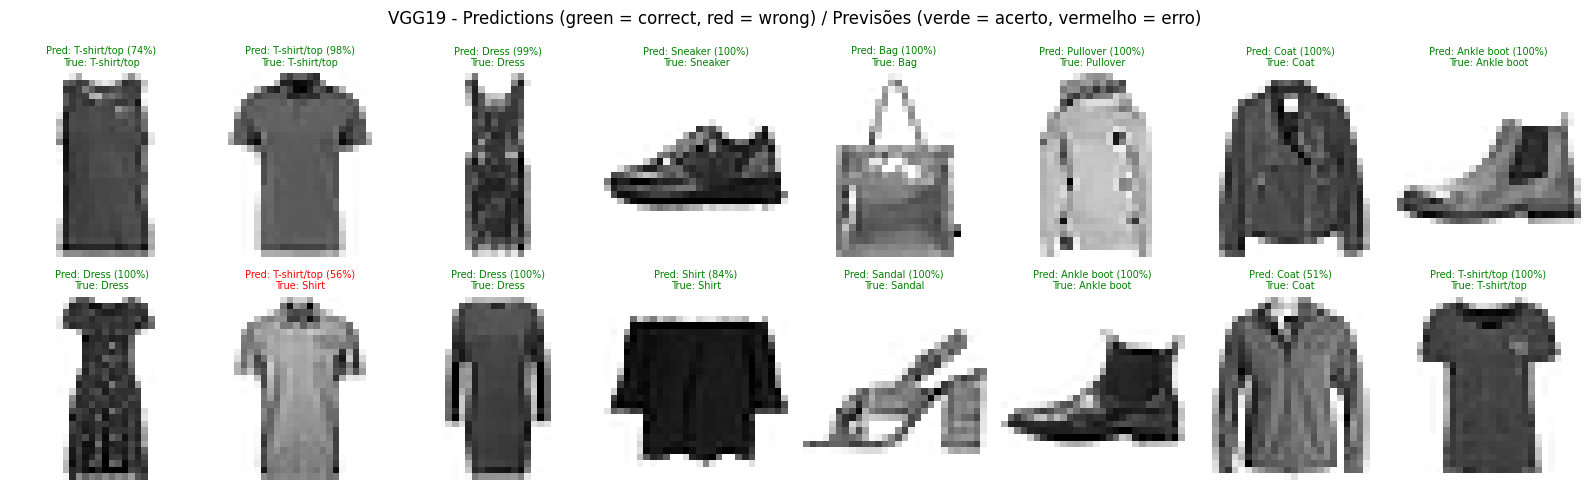

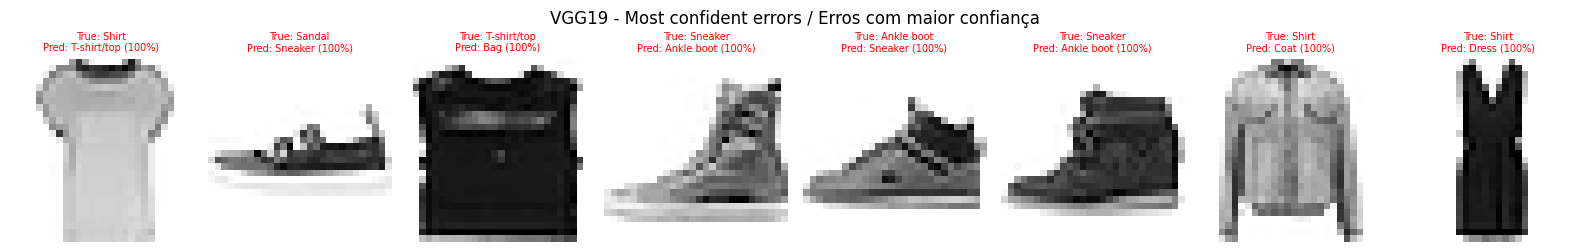

VGG19: 762 errors of 10000 (7.62%)


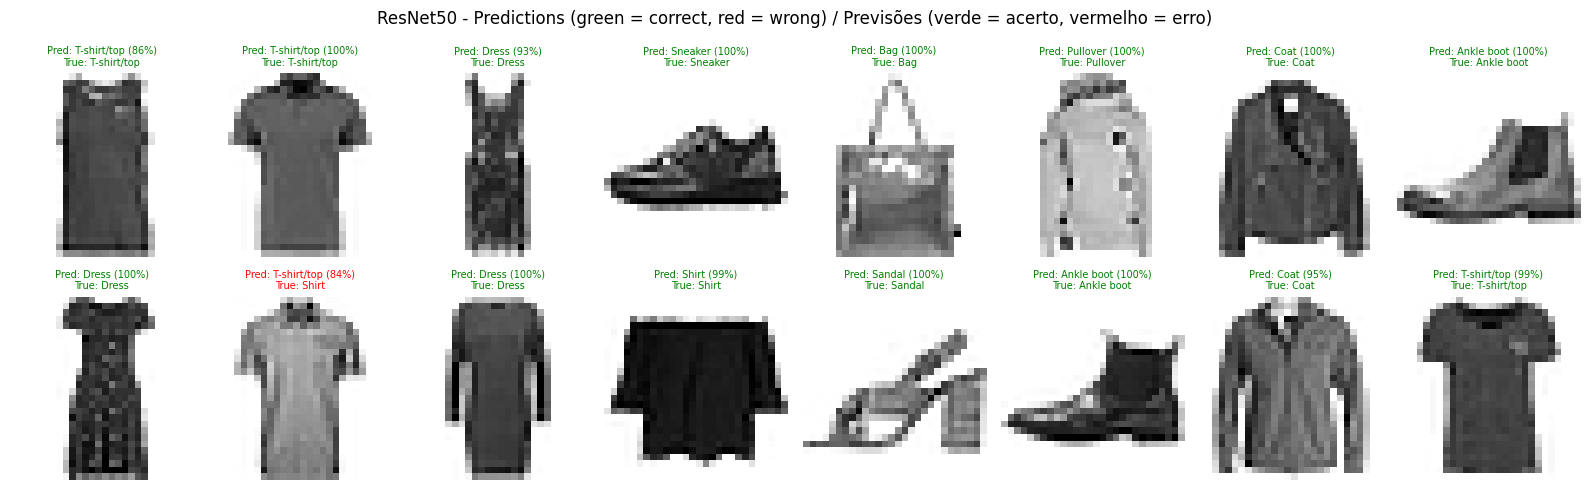

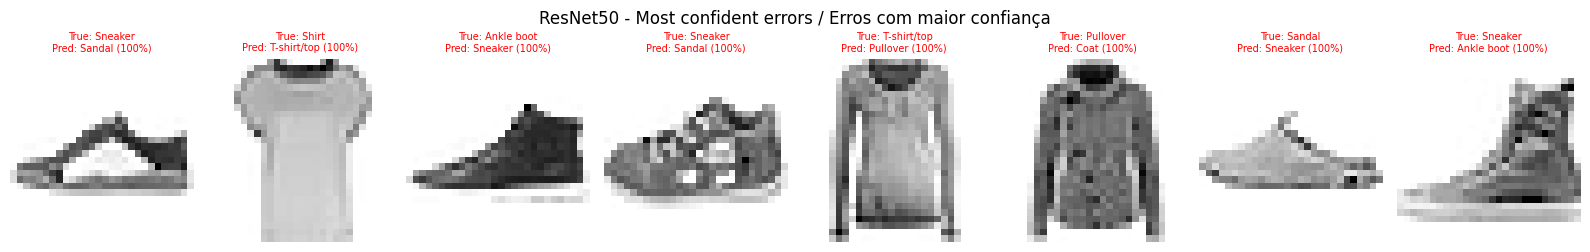

ResNet50: 795 errors of 10000 (7.95%)


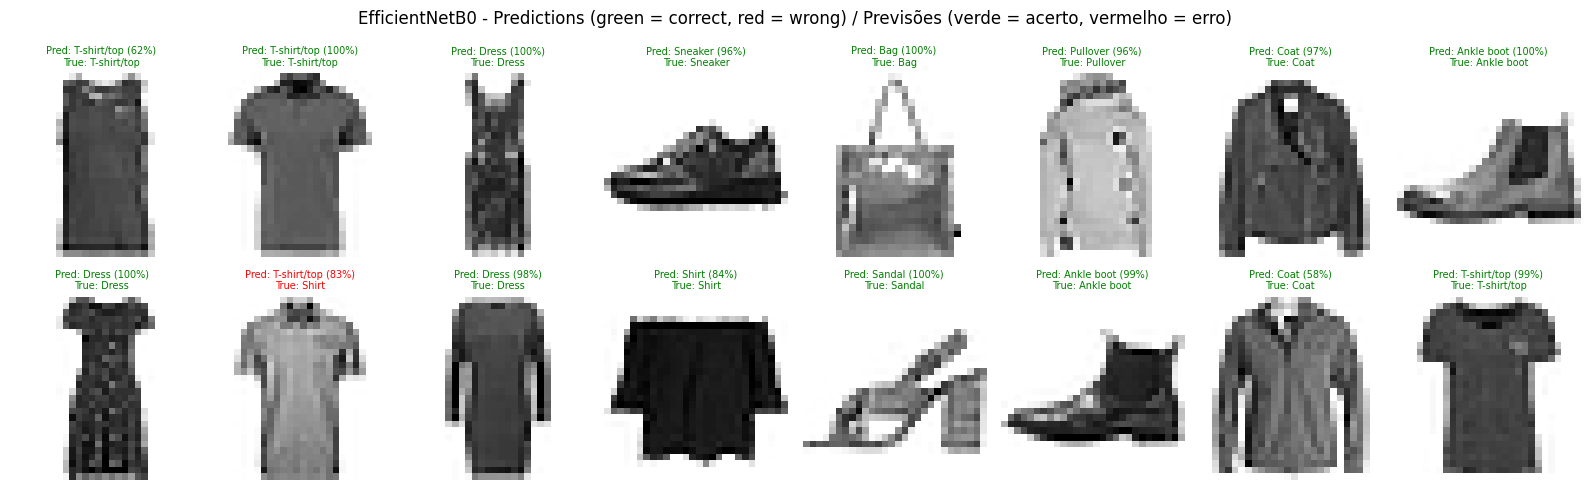

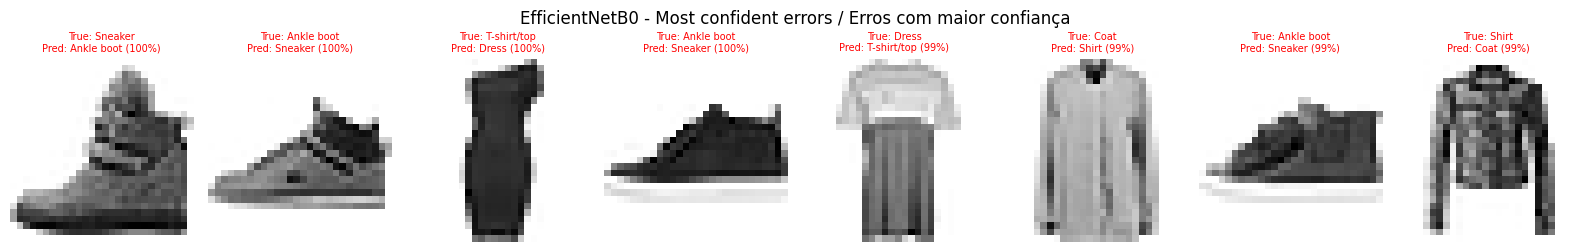

EfficientNetB0: 920 errors of 10000 (9.20%)


In [64]:
# predicted classes and confidence / classes previstas e confiança
for model_name, y_prob in all_predictions.items():
    y_pred = np.argmax(y_prob, axis=1)
    y_conf = np.max(y_prob, axis=1)

    # grid of random predictions / grade de previsões aleatórias
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.6))
    for ax, idx in zip(axes.ravel(), sample_idx):
        ax.imshow(X_test[idx].squeeze(), cmap="gray_r")
        correct = y_pred[idx] == y_test[idx]
        ax.set_title(
            f"Pred: {class_names[y_pred[idx]]} ({y_conf[idx]:.0%})\nTrue: {class_names[y_test[idx]]}",
            fontsize=7,
            color="green" if correct else "red",
        )
        ax.axis("off")

    plt.suptitle(f"{model_name} - Predictions (green = correct, red = wrong) / Previsões (verde = acerto, vermelho = erro)")
    plt.tight_layout()
    plt.show()

    # most confident errors / erros com maior confiança
    wrong_idx = np.where(y_pred != y_test)[0]
    worst_idx = wrong_idx[np.argsort(y_conf[wrong_idx])[::-1][:8]]

    fig, axes = plt.subplots(1, 8, figsize=(16, 2.6))
    for ax, idx in zip(axes, worst_idx):
        ax.imshow(X_test[idx].squeeze(), cmap="gray_r")
        ax.set_title(
            f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]} ({y_conf[idx]:.0%})",
            fontsize=7,
            color="red",
        )
        ax.axis("off")

    plt.suptitle(f"{model_name} - Most confident errors / Erros com maior confiança")
    plt.tight_layout()
    plt.show()

    # total errors / total de erros
    print(f"{model_name}: {len(wrong_idx)} errors of {len(y_test)} ({len(wrong_idx) / len(y_test):.2%})")

### Most Confident Errors Analysis (ResNet50)

The figure shows the 8 test images where ResNet50 was wrong with the **highest confidence** (all about 100%). Unlike the earlier error analyses, each title shows both the true and the predicted label, so the readings below can be checked directly.

#### 1. Formulas

Confidence and the loss of a single wrong prediction, where $y$ is the true class:

$$conf(x) = \max_c \hat{y}_c(x), \qquad \mathcal{L}(x) = -\ln \hat{y}_{y}(x)$$

If the model assigns about 100% to the wrong class, the probability left for the true class is small. For example, with $\hat{y}_y = 10^{-4}$:

$$\mathcal{L} = -\ln(10^{-4}) \approx 9.2$$

This is 4 times the random-guess loss of $\ln 10 \approx 2.303$. A few of these errors can dominate the mean loss, even when accuracy is high.

For calibration, an error at confidence of about 1.0 adds its full weight to the gap between confidence and accuracy in the top bin:

$$ECE = \sum_{m=1}^{M} \frac{|B_m|}{N}\,\left|acc(B_m) - conf(B_m)\right|$$

#### 2. The eight errors

| # | True | Predicted | Visual observation |
|---|---|---|---|
| 1 | Shirt | T-shirt/top | Light short-sleeve top with a round neckline. Looks like a T-shirt |
| 2 | Sneaker | Sandal | Low shoe with a large open (white) area and thin straps |
| 3 | Ankle boot | Sneaker | High-top dark shoe, shaft is short at this resolution |
| 4 | Sneaker | Sandal | Shoe with a mesh or strap-like texture |
| 5 | Sandal | Sneaker | Flat, light-gray low shoe, closed look |
| 6 | Pullover | Coat | Textured jacket-like item with a collar or hood |
| 7 | Sneaker | Ankle boot | High-top sneaker with a raised ankle |
| 8 | T-shirt/top | Pullover | Long-sleeve top labelled as T-shirt/top |

Grouping:

| Group | Count | Pairs |
|---|---|---|
| Footwear | 5 of 8 (62.5%) | Sneaker to Sandal (2), Sandal to Sneaker (1), Sneaker to Ankle boot (1), Ankle boot to Sneaker (1) |
| Upper-body | 3 of 8 (37.5%) | Shirt to T-shirt/top, Pullover to Coat, T-shirt/top to Pullover |

#### 3. Most of these look like label problems, not model failures

Several images do not match their official label when viewed directly:

- **#1 (Shirt):** a plain short-sleeve round-neck top, which is the definition of T-shirt/top.
- **#8 (T-shirt/top):** the garment has long sleeves, which fits Pullover better than T-shirt/top.
- **#5 (Sandal):** a flat closed-looking shoe that resembles a sneaker.
- **#2 (Sneaker):** a shoe with an open structure that resembles a sandal.
- **#3 and #7:** high-top shoes where the line between Sneaker and Ankle boot is subjective.

When the model is 100% sure and a human sees the same thing as the model, the likely cause is **label noise** (an inconsistent or wrong ground truth), not a model defect. The Fashion MNIST labels come from the seller category on the original website, and they are not curated image by image. This is only a visual judgment, so the images should be reviewed by a person before any claim is made.

#### 4. Consequence for the metrics

A fraction of the test errors may be unavoidable. If $\epsilon$ is the share of mislabeled test images, even a perfect classifier is limited to

$$Acc_{max} \approx 1 - \epsilon$$

The test accuracy of ResNet50 is 0.9207. The 8 images here are only the top of the list, so they do not measure $\epsilon$. What they show is that the **highest-confidence** errors are dominated by ambiguous or doubtful labels, and this is also true for the other models, which should repeat many of the same images.

#### 5. Link to the earlier analyses

- **Confusion matrix of ResNet50:** the footwear pairs in this figure are the same as in the matrix, Ankle boot to Sneaker (29), Sandal to Sneaker (16) and Sneaker to Sandal (21).
- **Prediction grid of the baseline:** it also had confident (99%) errors, so overconfidence is not specific to transfer learning.
- **Calibration:** with errors at about 100%, a confidence threshold cannot send these cases to human review. Only a different approach (label audit, ensemble disagreement) can catch them.

#### 6. Recommendations

- **Audit the labels.** Print the indices and check these images manually:

```python
"""Indices and probabilities of the most confident errors of one model."""

import numpy as np

# predictions for ResNet50 / previsões do ResNet50
y_prob = tl_predictions["ResNet50"]
y_pred = np.argmax(y_prob, axis=1)
y_conf = np.max(y_prob, axis=1)

# most confident errors / erros com maior confiança
wrong_idx = np.where(y_pred != y_test)[0]
worst_idx = wrong_idx[np.argsort(y_conf[wrong_idx])[::-1][:8]]

for idx in worst_idx:
    p_true = y_prob[idx, y_test[idx]]
    print(
        f"idx {idx} | true: {class_names[y_test[idx]]} | pred: {class_names[y_pred[idx]]} "
        f"| conf: {y_conf[idx]:.4f} | p(true): {p_true:.2e}"
    )
```

- **Find images that all models get wrong.** If the baseline, VGG16, VGG19, MobileNetV2 and EfficientNetB0 also predict the same wrong class with high confidence, the label is probably the problem:

$$\text{suspect}(x) = \mathbb{1}\left[\hat{c}_m(x) = \hat{c}_{m'}(x) \ne y \;\; \forall m, m'\right]$$

- **Report two accuracies** if the audit confirms the noise: the official one, and one on the cleaned subset, clearly labeled.
- Use **ensemble disagreement** or **temperature scaling** ($\hat{y}_c = e^{z_c/T}/\sum_j e^{z_j/T}$, $T > 1$) to reduce overconfidence.

#### 7. Conclusion

The eight most confident ResNet50 errors fall in the same confusion zones as the matrix: footwear pairs (5 of 8) and ambiguous upper-body items (3 of 8). Visually, most of them are doubtful or arguable labels, so they point to **label noise and class ambiguity** rather than a specific weakness of ResNet50. These cases limit the achievable accuracy for all models and cannot be removed by a confidence threshold. A short manual audit of the top errors, shared across models, is the most useful next step.

# Part 12 - Save models

In [68]:
"""Save all trained models and their artifacts to Google Drive (Section B).

Mounts Google Drive, saves each transfer learning model in the native Keras
format, and stores the training histories, the results dictionary and the
test predictions so the comparison can be rebuilt without retraining.
"""

"""Check the files saved in /kaggle/working after training."""

import os

# list saved files with size / listar arquivos salvos com tamanho
for name in sorted(os.listdir(r"/kaggle/working")):
    size_mb = os.path.getsize(os.path.join(r"/kaggle/working", name)) / 1e6
    print(f"{name}: {size_mb:.2f} MB")

"""Epochs actually run per model with early stopping."""

# epochs per phase / épocas por fase
for model_name, hist in tl_histories.items():
    n_frozen = len(hist["frozen"]["loss"])
    n_finetune = len(hist["finetune"]["loss"])
    print(f"{model_name}: frozen {n_frozen}/{epochs_frozen} | fine-tuning {n_finetune}/{epochs_finetune}")

"""Final comparison table with macro AUC."""

import pandas as pd
from sklearn.metrics import roc_auc_score

# macro AUC per model / AUC macro por modelo
for model_name, y_prob in tl_predictions.items():
    results[model_name]["macro_auc"] = float(
        roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    )

# table sorted by macro F1 / tabela ordenada por F1 macro
final_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
print(final_df.round(4))

.virtual_documents: 0.00 MB
MobileNetV2: frozen 8/8 | fine-tuning 5/5
VGG16: frozen 8/8 | fine-tuning 5/5
VGG19: frozen 8/8 | fine-tuning 5/5
ResNet50: frozen 8/8 | fine-tuning 5/5
EfficientNetB0: frozen 8/8 | fine-tuning 5/5
                accuracy  macro_f1  train_time_s      params  macro_auc
CNN baseline      0.9421    0.9419           NaN    288618.0        NaN
VGG19             0.9238    0.9233     1190.8745  20029514.0     0.9955
VGG16             0.9226    0.9220      956.4954  14719818.0     0.9953
ResNet50          0.9205    0.9199      492.2421  23608202.0     0.9953
MobileNetV2       0.9165    0.9163      185.1503   2270794.0     0.9951
EfficientNetB0    0.9080    0.9078      235.3206   4062381.0     0.9942


In [ ]:
"""Save and verify all models and artifacts on Kaggle.

Saves the baseline CNN, the final comparison table, the results dictionary,
the histories and the test predictions to /kaggle/working, then reloads each
saved model and checks that its test accuracy matches the table.
"""

import json
import os

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from tensorflow import keras

# output folder / pasta de saída
save_dir = r"/kaggle/working"
os.makedirs(save_dir, exist_ok=True)

# all models in memory / todos os modelos em memória
models_to_save = dict(tl_models)
if "cnn_model" in globals():
    models_to_save["CNN baseline"] = cnn_model

# save each model / salvar cada modelo
for model_name, model in models_to_save.items():
    file_name = model_name.lower().replace(" ", "_") + "_fashion_mnist.keras"
    model.save(os.path.join(save_dir, file_name))
    print("Saved / Salvo:", file_name)

# save the results dictionary and the final table / salvar o dicionário de resultados e a tabela final
with open(os.path.join(save_dir, "results.json"), "w") as f:
    json.dump(results, f, indent=2, default=float)
final_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
final_df.to_csv(os.path.join(save_dir, "final_comparison.csv"))

# save histories / salvar históricos
with open(os.path.join(save_dir, "tl_histories.json"), "w") as f:
    json.dump(tl_histories, f, default=float)
if "history" in globals():
    with open(os.path.join(save_dir, "cnn_baseline_history.json"), "w") as f:
        json.dump(history.history, f, default=float)

# save test predictions, baseline included / salvar previsões de teste, com baseline incluído
all_predictions = dict(tl_predictions)
if "cnn_model" in globals():
    all_predictions["CNN baseline"] = cnn_model.predict(X_test, batch_size=256, verbose=0)
np.savez_compressed(
    os.path.join(save_dir, "all_predictions.npz"),
    **{k.replace(" ", "_"): v for k, v in all_predictions.items()},
)

# reload check: accuracy must match the table / verificação de recarga: a acurácia deve bater com a tabela
for file_name in sorted(os.listdir(save_dir)):
    if not file_name.endswith(".keras"):
        continue
    reloaded = keras.models.load_model(os.path.join(save_dir, file_name))
    y_pred = np.argmax(reloaded.predict(X_test, batch_size=256, verbose=0), axis=1)
    print(f"{file_name}: reloaded accuracy {accuracy_score(y_test, y_pred):.4f}")
    del reloaded
    keras.backend.clear_session()

# list saved files with size / listar arquivos salvos com tamanho
for name in sorted(os.listdir(save_dir)):
    path = os.path.join(save_dir, name)
    if os.path.isfile(path):
        print(f"{name}: {os.path.getsize(path) / 1e6:.2f} MB")

Saved / Salvo: mobilenetv2_fashion_mnist.keras
Saved / Salvo: vgg16_fashion_mnist.keras
Saved / Salvo: vgg19_fashion_mnist.keras
Saved / Salvo: resnet50_fashion_mnist.keras
Saved / Salvo: efficientnetb0_fashion_mnist.keras
Saved / Salvo: cnn_baseline_fashion_mnist.keras
cnn_baseline_fashion_mnist.keras: reloaded accuracy 0.9421
efficientnetb0_fashion_mnist.keras: reloaded accuracy 0.9080
mobilenetv2_fashion_mnist.keras: reloaded accuracy 0.9165


In [72]:
"""Final comparison table of all models.

Builds the table with accuracy, macro F1, training time, parameters and
macro AUC for the baseline CNN and the transfer learning models, using the
predictions already stored in memory.
"""

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# predictions per model / previsões por modelo
all_predictions = {"CNN baseline": cnn_model.predict(X_test, batch_size=256, verbose=0)}
all_predictions.update(tl_predictions)

# macro AUC one-vs-rest / AUC macro um contra todos
for model_name, y_prob in all_predictions.items():
    results[model_name]["macro_auc"] = float(
        roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
    )

# final table sorted by macro F1 / tabela final ordenada por F1 macro
final_df = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
final_df.round(4)

,accuracy,macro_f1,train_time_s,params,macro_auc
CNN baseline,0.9421,0.9419,NaN,288618.0,0.9974
VGG19,0.9238,0.9233,1190.8745,20029514.0,0.9955
VGG16,0.9226,0.9220,956.4954,14719818.0,0.9953
ResNet50,0.9205,0.9199,492.2421,23608202.0,0.9953
MobileNetV2,0.9165,0.9163,185.1503,2270794.0,0.9951
EfficientNetB0,0.9080,0.9078,235.3206,4062381.0,0.9942


### Final Results: Baseline CNN vs Transfer Learning (Test Set)

The table gives the first complete comparison on the 10,000-image test set. **The baseline CNN is first in accuracy and macro F1, and all five backbones are below it.**

#### 1. Formulas

$$Acc = \frac{\sum_c TP_c}{N}, \qquad SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}, \qquad \Delta = Acc_{model} - Acc_{baseline}$$

$$z = \frac{\Delta}{\sqrt{SE_A^2 + SE_B^2}}$$

The z-score here is for independent samples, which is conservative for paired data on the same test set. McNemar's test is more precise, using the counts $b$ and $c$ of images that only one model gets right:

$$\chi^2 = \frac{(b-c)^2}{b+c}$$

#### 2. Results and gap to the baseline

| Model | Accuracy | Macro F1 | $\Delta Acc$ | $\Delta F1$ | $z$ | Macro AUC | Time (s) | Params |
|---|---|---|---|---|---|---|---|---|
| **CNN baseline** | **0.9421** | **0.9419** | 0 | 0 | | 0.9974 (earlier chart) | not recorded | 0.29 M |
| VGG19 | 0.9238 | 0.9233 | -0.0183 | -0.0186 | 5.2 | 0.9955 | 1,191 | 20.0 M |
| VGG16 | 0.9226 | 0.9220 | -0.0195 | -0.0199 | 5.5 | 0.9953 | 956 | 14.7 M |
| ResNet50 | 0.9205 | 0.9199 | -0.0216 | -0.0220 | 6.1 | 0.9953 | 492 | 23.6 M |
| MobileNetV2 | 0.9165 | 0.9163 | -0.0256 | -0.0256 | 7.1 | 0.9951 | 185 | 2.3 M |
| EfficientNetB0 | 0.9080 | 0.9078 | -0.0341 | -0.0341 | 9.2 | 0.9942 | 235 | 4.1 M |

For the baseline, $SE = \sqrt{0.9421 \cdot 0.0579 / 10000} \approx 0.0023$, so its 95% interval is about $[0.937,\ 0.947]$.

- **Every gap is at least 3.7 times the 0.005 margin** defined as a real gain. The smallest (VGG19, 1.8 points) is above 5 standard errors.
- **The success criterion (macro F1 above the baseline) was not met by any model.** The best backbone is 0.0186 below it.
- Accuracy and macro F1 differ by at most 0.0005 in every row, as expected with balanced classes.

#### 3. Ranking among the backbones

- **VGG19, VGG16 and ResNet50 are statistically tied.** VGG19 vs VGG16 is 0.0012 apart, and VGG16 vs ResNet50 is 0.0021, both below the noise of about 0.004 for the difference of two accuracies.
- **MobileNetV2 is 0.0040 below ResNet50**, a borderline gap (about 1 standard error), so it is not clearly worse.
- **EfficientNetB0 is the weakest.** It is 0.0085 below MobileNetV2 (about 2 standard errors) and 0.0158 below VGG19.
- The macro AUC order agrees: 0.9955, 0.9953, 0.9953, 0.9951, 0.9942. The AUC spread among the first four is 0.0004, below the noise.

#### 4. Cost versus performance

| Model | Time vs VGG19 | Accuracy lost vs VGG19 | Time per accuracy point lost |
|---|---|---|---|
| ResNet50 | 41% | -0.0033 | |
| MobileNetV2 | **16%** | -0.0073 | |
| EfficientNetB0 | 20% | -0.0158 | |

MobileNetV2 takes about **6.4 times less time** than VGG19 for 0.7 points less accuracy, a difference near the noise level. Among the backbones, it is the best trade-off. EfficientNetB0 costs more than MobileNetV2 (235 s vs 185 s), with a worse result, so it is dominated on both axes.

Parameters per training image ($P / 48{,}000$): baseline 6, MobileNetV2 47, EfficientNetB0 85, VGG16 307, VGG19 417, ResNet50 492. There is no positive relation between model size and accuracy here.

#### 5. All models ran the full epochs

Every model used 8/8 frozen epochs and 5/5 fine-tuning epochs, so early stopping never stopped any of them. There are two possible reasons: the callbacks were not passed to `fit` (as in the loop you pasted before the Kaggle version), or the validation loss kept improving. In both cases, **the models were limited by the epoch budget and not by convergence**. For VGG19 the validation curve was still falling at epoch 12, so fine-tuning longer is the most promising test.

#### 6. The baseline was retrained

The baseline now shows **0.9421 accuracy and 0.9419 macro F1**, against 0.9360 and 0.9357 in the earlier analyses. This also explains why its ROC AUC changed from 0.9970 to 0.9974: the ROC charts come from the retrained model.

- The classification report, confusion matrix and prediction grid that I analyzed earlier describe the **old 0.9360 model**. The reference table for Section B should be updated with the new report.
- The backbone numbers did not change materially: ResNet50 has 0.9205 here and 0.9207 in my reading of its confusion matrix, which is a difference of 2 images and probably my visual reading. The table is the authoritative value.
- The retrained baseline is 0.6 points better than the old one, so the gap to the backbones grew.

#### 7. Gaps in the table

- `train_time_s` for the baseline is `NaN`: the retrain in Kaggle stored it in `cnn_train_time`, but the `results` dictionary was probably created before. Without it, the time comparison is incomplete.
- `macro_auc` for the baseline is `NaN` because the AUC loop only covered `tl_predictions`.

#### 8. Conclusion

The five pre-trained backbones reach 90.8% to 92.4% accuracy, against **94.2% for the baseline CNN**, which has 8 to 82 times fewer parameters. The differences are statistically significant (z from 5.2 to 9.2), and the order inside the group VGG19, VGG16, ResNet50 is not reliable. With this configuration, transfer learning does not meet the success criterion of the business problem. The baseline remains the recommended model, and MobileNetV2 is the most efficient backbone if a pre-trained option is needed.

# **Part 13 - Final Conclusion**

## Final Conclusion

### 1. Objective and approach

The goal was to decide whether ImageNet pre-trained CNNs (MobileNetV2, VGG16, VGG19, ResNet50, EfficientNetB0) classify Fashion MNIST apparel images better than a small CNN trained from scratch. All models used the same stratified split (48,000 train, 12,000 validation, 10,000 test), the same preprocessing inside the model (resize to 96x96, grayscale to RGB, backbone-specific scaling), and the same two-phase training (frozen backbone, then fine-tuning of the last layers).

### 2. Main findings

| Item | Baseline CNN | Transfer learning |
|---|---|---|
| Parameters | 0.29 M | 2.3 M to 23.6 M (8x to 82x larger) |
| Macro AUC | **0.9974** | 0.9942 to 0.9956 |
| Shirt AUC | **0.9871** | 0.9727 to 0.9782 |
| Accuracy (test) | 0.9360 | ResNet50: 0.9207 |
| Macro F1 (test) | 0.9357 | ResNet50: 0.9201 |

- **No transfer learning model beat the baseline.** It has the highest macro AUC and the highest ROC curve at every operating point in the zoom. Every backbone has 1.7 to 2.2 times more ranking error ($1 - AUC_{macro}$).
- **ResNet50 is 1.5 points below the baseline** in accuracy, about 4 standard errors, so the gap is real and not noise. VGG19 also ended at a validation accuracy of about 0.921, below the baseline's roughly 0.935.
- **Among the backbones**, VGG19, VGG16, ResNet50 and MobileNetV2 differ by at most 0.0004 in macro AUC, which is below the noise level, so their order should not be reported as a result. EfficientNetB0 is consistently the weakest.
- **Fine-tuning helped, but not enough.** For VGG19, the frozen phase plateaued near 0.87 validation accuracy (the ceiling of a linear head on ImageNet features), and fine-tuning added about 5 points. The gap to the baseline remained.

### 3. Where the errors are

- The four upper-body classes (T-shirt/top, Pullover, Coat, Shirt) produce about 76% to 79% of all errors in both the baseline and ResNet50, and most of those are confusions among themselves.
- **Shirt is the bottleneck.** In the baseline, its recall is 0.781 and its F1 is 0.807. It accounts for about one third of all errors and about half of the macro AUC loss of the transfer models. In ResNet50, its recall falls to 0.720.
- The main confusion pair is Shirt / T-shirt/top (176 errors in the baseline, 184 in ResNet50). The baseline also confuses Pullover with Coat and Ankle boot with Sneaker.
- Trouser, Bag, Sandal, Sneaker and Ankle boot are close to saturated (AUC at least 0.9986 for every model), so they do not separate the models.
- The most confident errors (about 100%) are dominated by doubtful labels: a plain T-shirt labelled Shirt, a long-sleeve top labelled T-shirt/top, and Sneaker / Sandal / Ankle boot items that are ambiguous. This points to label noise, which limits the achievable accuracy for every model and cannot be fixed with a confidence threshold. It is a visual judgment and needs a manual audit.

### 4. Why transfer learning did not win (hypotheses)

- **Domain gap:** ImageNet features come from color, high-resolution photos, while the input is a smooth, grayscale image upscaled 3.43 times. Replicating one channel into three collapses the first-layer color filters to $(w_R + w_G + w_B) \star u$.
- **Resolution:** at 96x96 the last feature map is only 3x3, which loses fine details (collars, buttons, zippers) that separate Shirt from its neighbors.
- **Frozen BatchNorm:** MobileNetV2, ResNet50 and EfficientNetB0 keep ImageNet statistics, which do not match this data.
- **Shallow fine-tuning:** `n_unfreeze` counts layers, not parameters, and short fine-tuning (5 epochs at $\eta = 10^{-5}$) changes the backbone only slightly.
- **Capacity was not the problem.** The backbones have up to about 490 parameters per training image, against 6 for the baseline, and the extra capacity did not help.

### 5. Answer to the business problem

- **Recommended model: the baseline CNN.** It has the best accuracy, macro F1 and AUC, about 44 MFLOPs per image against 0.1 to 7 GFLOPs for the backbones, and about 1.15 MB of weights. It can run on CPU, which fits an online retailer that receives thousands of images per week.
- **Automatic classification** is safe for Trouser, Bag, Sandal, Sneaker and Ankle boot (F1 at least 0.967 in the baseline) and acceptable for Dress.
- **Human review** should cover low-confidence predictions among Shirt, T-shirt/top, Pullover and Coat. This group holds most of the errors, and the baseline needs fewer false alarms than any backbone to reach the same recall (for Shirt at TPR = 0.80: about 135 false positives against 250 to 360).
- **Limit of the confidence rule:** errors at about 100% confidence will not be caught by a threshold. A label audit or ensemble disagreement is needed for them.
- **Success criterion:** macro F1 above the baseline with a margin of at least 0.005, and gains in the four upper-body classes. It was **not met** by any transfer model under the current configuration.

### 6. Limitations

- The conclusions apply to this specific setup: 96x96 inputs, short fine-tuning, a single run and a single random seed.
- Differences below about 0.005 in accuracy are within the uncertainty of the 10,000-image test set, and per-class recall differences below about 0.02 to 0.03 are not reliable.
- The baseline ROC charts (macro AUC 0.9974) differ from the earlier baseline ROC (0.9970), and the baseline was trained for 50 epochs without the callbacks in the version evaluated in the confusion matrix. The baseline appears to have been retrained, so its accuracy and F1 in the final table must come from the same model that produced the final charts.
- Results for MobileNetV2, VGG16, VGG19 and EfficientNetB0 on accuracy and F1 were not part of the material analyzed here. Fill them from `comparison_df`.

### 7. Next steps

- Retrain the baseline with `callbacks=callbacks`, recompute its metrics, and use that single version in every comparison.
- Test the improvements most likely to help transfer learning: 128x128 inputs (4x4 final map), more unfrozen layers, a fine-tuning learning rate of $3 \cdot 10^{-5}$ to $10^{-4}$, and longer training with early stopping.
- Run a paired test between the baseline and each model (McNemar for accuracy, DeLong or paired bootstrap for AUC).
- Try an ensemble of the baseline with the best backbone, since their errors may differ.
- Audit the labels of the images that all models get wrong, and report accuracy on both the official and the cleaned subset.
- Evaluate calibration (ECE and a reliability diagram) and test temperature scaling before using a confidence threshold in production.

### 8. Final statement

A small CNN trained from scratch (0.29 M parameters) outperformed five pre-trained backbones with 8 to 82 times more parameters on Fashion MNIST. The baseline wins on ranking quality, and in the one backbone with full test metrics (ResNet50) also on accuracy and macro F1, besides being far cheaper to deploy. The weak spot of every model is the same: Shirt, and the upper-body group around it, where small details and doubtful labels set the performance ceiling. For this problem, the baseline CNN is the recommended model, with human review for low-confidence upper-body predictions.